In [ ]:
pip install qiskit qiskit-optimization networkx matplotlib scipy

In [ ]:
pip install qiskit

In [ ]:
pip install qiskit qiskit-aer networkx matplotlib scipy

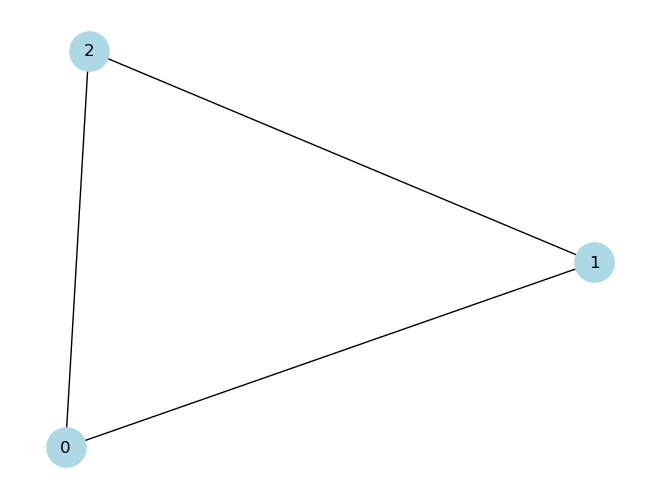

Cost Hamiltonian:
SparsePauliOp(['IZZ', 'ZIZ', 'ZZI'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j])
4


C:\Users\Lenovo\anaconda3\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
C:\Users\Lenovo\anaconda3\Lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
C:\Users\Lenovo\anaconda3\Lib\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])



Optimal Parameters:
[4.06462781 2.11189913 2.88540821 1.22733602]

Optimal Energy:
-0.9999998617375525

QAOA Circuit:
     ┌────────────────────────────────────┐
q_0: ┤0                                   ├
     │                                    │
q_1: ┤1 QAOA(2.8854,4.0646,1.2273,2.1119) ├
     │                                    │
q_2: ┤2                                   ├
     └────────────────────────────────────┘

Bitstring Probabilities:
001 : 0.166667
101 : 0.166667
011 : 0.166667
110 : 0.166667
100 : 0.166667
010 : 0.166667
000 : 0.0
111 : 0.0

Best Bitstring: 001
Cut Value = 2


In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

from qiskit.primitives import StatevectorEstimator
from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp

from scipy.optimize import minimize


# ============================================================
# STEP 1 : Create Graph
# ============================================================

G = nx.Graph()

G.add_weighted_edges_from([
    (0, 1, 1),
    (1, 2, 1),
    (0, 2, 1)
])

nx.draw(
    G,
    with_labels=True,
    node_color='lightblue',
    node_size=800
)
plt.show()

n = G.number_of_nodes()


# ============================================================
# STEP 2 : Cost Hamiltonian
#
# Hc = Σ wij ZiZj
# ============================================================

paulis = []
coeffs = []

for i, j, w in G.edges(data='weight'):

    z = ['I'] * n

    z[i] = 'Z'
    z[j] = 'Z'

    paulis.append("".join(reversed(z)))
    coeffs.append(float(w))

cost_hamiltonian = SparsePauliOp(paulis, coeffs)

print("Cost Hamiltonian:")
print(cost_hamiltonian)


# ============================================================
# STEP 3 : QAOA Ansatz
# ============================================================

p = 2

qaoa = QAOAAnsatz(
    cost_operator=cost_hamiltonian,
    reps=p
)

print(qaoa.num_parameters)


# ============================================================
# STEP 4 : Expectation Value Function
# ============================================================

estimator = StatevectorEstimator()

def objective(params):

    job = estimator.run(
        [(qaoa, cost_hamiltonian, params)]
    )

    result = job.result()

    value = result[0].data.evs

    return value


# ============================================================
# STEP 5 : Optimize γ and β
# ============================================================

initial_params = np.random.uniform(
    0,
    np.pi,
    qaoa.num_parameters
)

result = minimize(
    objective,
    initial_params,
    method="COBYLA"
)

best_params = result.x

print("\nOptimal Parameters:")
print(best_params)

print("\nOptimal Energy:")
print(result.fun)


# ============================================================
# STEP 6 : Final State
# ============================================================

final_circuit = qaoa.assign_parameters(best_params)

print("\nQAOA Circuit:")
print(final_circuit.draw())


# ============================================================
# STEP 7 : Get Bitstring Probabilities
# ============================================================

from qiskit.quantum_info import Statevector

state = Statevector.from_instruction(final_circuit)

probs = state.probabilities_dict()

print("\nBitstring Probabilities:")

for bitstring, prob in sorted(
        probs.items(),
        key=lambda x: x[1],
        reverse=True):

    print(bitstring, ":", round(prob, 6))


# ============================================================
# STEP 8 : Best Solution
# ============================================================

best_bitstring = max(
    probs.items(),
    key=lambda x: x[1]
)[0]

print("\nBest Bitstring:", best_bitstring)


# ============================================================
# STEP 9 : Max-Cut Value
# ============================================================

def cut_value(bitstring, graph):

    value = 0

    bits = [int(b) for b in bitstring[::-1]]

    for u, v, data in graph.edges(data=True):

        if bits[u] != bits[v]:
            value += data['weight']

    return value


cut = cut_value(best_bitstring, G)

print("Cut Value =", cut)

In [2]:
pip install qiskit qiskit-aer scipy networkx matplotlib

Note: you may need to restart the kernel to use updated packages.



Graph Edges:
[(0, 1, {'weight': 1}), (0, 2, {'weight': 1}), (1, 2, {'weight': 1})]


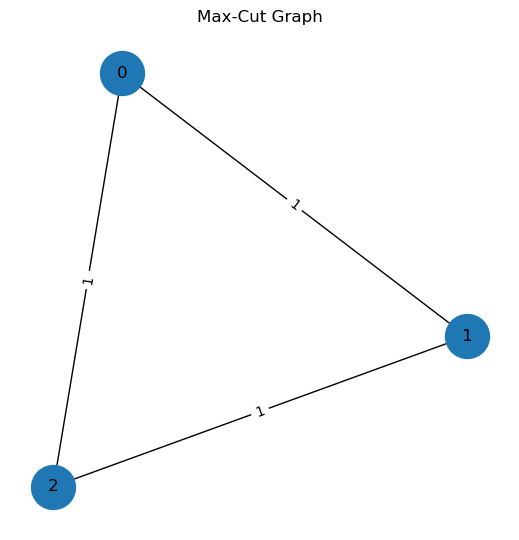


Cost Hamiltonian:
SparsePauliOp(['IZZ', 'ZIZ', 'ZZI'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j])

Number of Parameters = 4

Optimization Complete
Optimal Energy = -0.9999998250796998

Optimal Parameters:
[2.19516728 2.87425058 2.93066125 1.67452789]

QAOA Circuit:
     ┌────────────────────────────────────┐
q_0: ┤0                                   ├
     │                                    │
q_1: ┤1 QAOA(2.9307,2.1952,1.6745,2.8743) ├
     │                                    │
q_2: ┤2                                   ├
     └────────────────────────────────────┘

Top Bitstrings:

001 : 0.166667
010 : 0.166667
100 : 0.166667
101 : 0.166667
110 : 0.166667
011 : 0.166667
111 : 0.000000
000 : 0.000000

Best Bitstring = 001
QAOA Cut Value = 2
Classical Maximum Cut = 2

Approximation Ratio = 1.0
Approximation Ratio (%) = 100.0 %

FINAL RESULTS
Best Bitstring       : 001
QAOA Cut Value       : 2
Classical Max-Cut    : 2
Approximation Ratio  : 1.0


In [3]:
# ==========================================================
# STANDARD QAOA FOR MAX-CUT
# Qiskit + SciPy Warning-Free Version
# ==========================================================

import warnings
from scipy.sparse import SparseEfficiencyWarning

# Suppress Sparse Matrix Warnings
warnings.filterwarnings("ignore", category=SparseEfficiencyWarning)

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from qiskit.primitives import StatevectorEstimator
from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp, Statevector


# ==========================================================
# CREATE GRAPH
# ==========================================================

G = nx.Graph()

G.add_weighted_edges_from([
    (0, 1, 1),
    (1, 2, 1),
    (0, 2, 1)
])

print("\nGraph Edges:")
print(list(G.edges(data=True)))

plt.figure(figsize=(5, 5))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1000
)

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

plt.title("Max-Cut Graph")
plt.show()

n = G.number_of_nodes()


# ==========================================================
# COST HAMILTONIAN
#
# Hc = Σ wij ZiZj
# ==========================================================

paulis = []
coeffs = []

for i, j, w in G.edges(data="weight"):

    label = ["I"] * n

    label[i] = "Z"
    label[j] = "Z"

    paulis.append("".join(reversed(label)))
    coeffs.append(float(w))

cost_hamiltonian = SparsePauliOp(paulis, coeffs)

cost_hamiltonian = cost_hamiltonian.simplify()

print("\nCost Hamiltonian:")
print(cost_hamiltonian)


# ==========================================================
# QAOA DEPTH
# ==========================================================

p = 2

qaoa = QAOAAnsatz(
    cost_operator=cost_hamiltonian,
    reps=p
)

print("\nNumber of Parameters =", qaoa.num_parameters)


# ==========================================================
# ESTIMATOR
# ==========================================================

estimator = StatevectorEstimator()


# ==========================================================
# OBJECTIVE FUNCTION
# ==========================================================

def objective(params):

    job = estimator.run(
        [(qaoa, cost_hamiltonian, params)]
    )

    result = job.result()

    energy = result[0].data.evs

    return energy


# ==========================================================
# OPTIMIZATION
# ==========================================================

initial_params = np.random.uniform(
    0,
    np.pi,
    qaoa.num_parameters
)

result = minimize(
    objective,
    initial_params,
    method="COBYLA",
    options={
        "maxiter": 300
    }
)

best_params = result.x

print("\nOptimization Complete")
print("Optimal Energy =", result.fun)

print("\nOptimal Parameters:")
print(best_params)


# ==========================================================
# FINAL CIRCUIT
# ==========================================================

final_circuit = qaoa.assign_parameters(best_params)

print("\nQAOA Circuit:")
print(final_circuit.draw())


# ==========================================================
# STATEVECTOR
# ==========================================================

state = Statevector.from_instruction(final_circuit)

probs = state.probabilities_dict()


# ==========================================================
# SORT PROBABILITIES
# ==========================================================

sorted_probs = sorted(
    probs.items(),
    key=lambda x: x[1],
    reverse=True
)

print("\nTop Bitstrings:\n")

for bitstring, prob in sorted_probs[:10]:
    print(
        f"{bitstring} : {prob:.6f}"
    )


# ==========================================================
# BEST BITSTRING
# ==========================================================

best_bitstring = sorted_probs[0][0]

print("\nBest Bitstring =", best_bitstring)


# ==========================================================
# MAX-CUT VALUE
# ==========================================================

def compute_cut(bitstring, graph):

    bits = [int(x) for x in bitstring[::-1]]

    cut = 0

    for u, v, data in graph.edges(data=True):

        if bits[u] != bits[v]:
            cut += data["weight"]

    return cut


qaoa_cut = compute_cut(
    best_bitstring,
    G
)

print("QAOA Cut Value =", qaoa_cut)


# ==========================================================
# CLASSICAL OPTIMUM
# ==========================================================

best_classical = 0

for i in range(2 ** n):

    bitstring = format(i, f"0{n}b")

    cut = compute_cut(
        bitstring,
        G
    )

    best_classical = max(
        best_classical,
        cut
    )

print("Classical Maximum Cut =", best_classical)


# ==========================================================
# APPROXIMATION RATIO
# ==========================================================

approx_ratio = qaoa_cut / best_classical

print(
    "\nApproximation Ratio =",
    round(approx_ratio, 4)
)

print(
    "Approximation Ratio (%) =",
    round(100 * approx_ratio, 2),
    "%"
)

# ==========================================================
# FINAL RESULTS
# ==========================================================

print("\n==============================")
print("FINAL RESULTS")
print("==============================")
print("Best Bitstring       :", best_bitstring)
print("QAOA Cut Value       :", qaoa_cut)
print("Classical Max-Cut    :", best_classical)
print("Approximation Ratio  :", round(approx_ratio, 4))
print("==============================")


Weighted Edges:
0 -- 1  weight=5
0 -- 2  weight=2
1 -- 2  weight=3


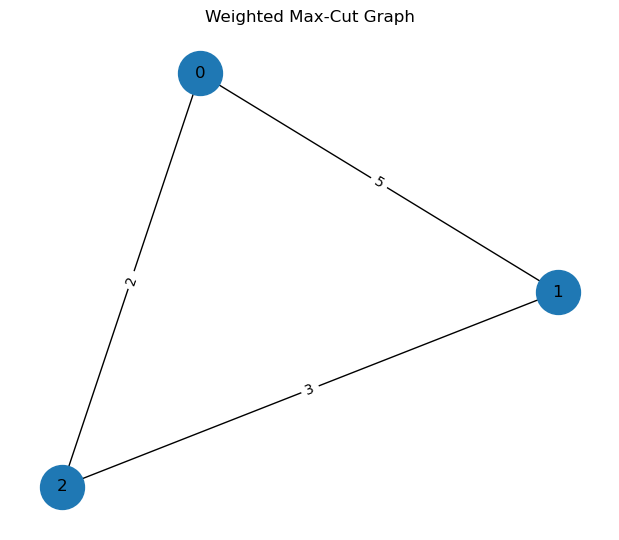


Weighted Cost Hamiltonian
SparsePauliOp(['IZZ', 'ZIZ', 'ZZI'],
              coeffs=[5.+0.j, 2.+0.j, 3.+0.j])

Optimal Energy:
-5.37859748705023

Top Solutions
101 0.364492
010 0.364492
110 0.125826
001 0.125826
100 0.009586
011 0.009586
111 9.6e-05
000 9.6e-05

Best Bitstring = 101
Weighted Cut = 8
Classical Optimum = 8

Approximation Ratio = 1.0
Approximation Ratio (%) = 100.0

WEIGHTED QAOA RESULTS
Best Bitstring      : 101
Weighted Cut        : 8
Classical Optimum   : 8
Approx Ratio        : 1.0


In [4]:
import warnings
from scipy.sparse import SparseEfficiencyWarning

warnings.filterwarnings("ignore", category=SparseEfficiencyWarning)

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from qiskit.primitives import StatevectorEstimator
from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp, Statevector

# =====================================================
# WEIGHTED GRAPH
# =====================================================

G = nx.Graph()

G.add_weighted_edges_from([
    (0, 1, 5),
    (0, 2, 2),
    (1, 2, 3)
])

print("\nWeighted Edges:")
for u, v, w in G.edges(data="weight"):
    print(f"{u} -- {v}  weight={w}")

# Draw Graph
plt.figure(figsize=(6, 5))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1000
)

edge_labels = nx.get_edge_attributes(G, "weight")

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

plt.title("Weighted Max-Cut Graph")
plt.show()

# =====================================================
# COST HAMILTONIAN
# HC = Σ wij ZiZj
# =====================================================

n = G.number_of_nodes()

paulis = []
coeffs = []

for i, j, w in G.edges(data="weight"):

    label = ["I"] * n

    label[i] = "Z"
    label[j] = "Z"

    paulis.append("".join(reversed(label)))
    coeffs.append(float(w))

cost_hamiltonian = SparsePauliOp(paulis, coeffs)

print("\nWeighted Cost Hamiltonian")
print(cost_hamiltonian)

# =====================================================
# QAOA ANSATZ
# =====================================================

p = 2

qaoa = QAOAAnsatz(
    cost_operator=cost_hamiltonian,
    reps=p
)

# =====================================================
# ESTIMATOR
# =====================================================

estimator = StatevectorEstimator()

def objective(params):

    job = estimator.run(
        [(qaoa, cost_hamiltonian, params)]
    )

    result = job.result()

    return result[0].data.evs

# =====================================================
# OPTIMIZATION
# =====================================================

initial_params = np.random.uniform(
    0,
    np.pi,
    qaoa.num_parameters
)

result = minimize(
    objective,
    initial_params,
    method="COBYLA",
    options={"maxiter": 300}
)

best_params = result.x

print("\nOptimal Energy:")
print(result.fun)

# =====================================================
# FINAL STATE
# =====================================================

final_circuit = qaoa.assign_parameters(best_params)

state = Statevector.from_instruction(final_circuit)

probs = state.probabilities_dict()

sorted_probs = sorted(
    probs.items(),
    key=lambda x: x[1],
    reverse=True
)

print("\nTop Solutions")

for bitstring, prob in sorted_probs[:10]:
    print(bitstring, round(prob, 6))

best_bitstring = sorted_probs[0][0]

print("\nBest Bitstring =", best_bitstring)

# =====================================================
# WEIGHTED CUT VALUE
# =====================================================

def weighted_cut(bitstring, graph):

    bits = [int(x) for x in bitstring[::-1]]

    cut_value = 0

    for u, v, data in graph.edges(data=True):

        if bits[u] != bits[v]:

            cut_value += data["weight"]

    return cut_value

qaoa_cut = weighted_cut(
    best_bitstring,
    G
)

print("Weighted Cut =", qaoa_cut)

# =====================================================
# CLASSICAL OPTIMUM
# =====================================================

best_classical = 0

for i in range(2**n):

    bitstring = format(i, f"0{n}b")

    value = weighted_cut(
        bitstring,
        G
    )

    if value > best_classical:
        best_classical = value

print("Classical Optimum =", best_classical)

# =====================================================
# APPROXIMATION RATIO
# =====================================================

ratio = qaoa_cut / best_classical

print("\nApproximation Ratio =", ratio)

print("Approximation Ratio (%) =", ratio * 100)

# =====================================================
# RESULTS
# =====================================================

print("\n==============================")
print("WEIGHTED QAOA RESULTS")
print("==============================")
print("Best Bitstring      :", best_bitstring)
print("Weighted Cut        :", qaoa_cut)
print("Classical Optimum   :", best_classical)
print("Approx Ratio        :", round(ratio, 4))
print("==============================")

In [5]:
import warnings
from scipy.sparse import SparseEfficiencyWarning

warnings.filterwarnings(
    "ignore",
    category=SparseEfficiencyWarning
)

import numpy as np

from scipy.optimize import minimize

from qiskit.primitives import StatevectorEstimator
from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp, Statevector

# =====================================================
# PROBLEM DATA
# =====================================================

profits = [10, 15, 7, 20, 12]

n = len(profits)

K = 2

A = 20.0

# =====================================================
# BUILD HAMILTONIAN
# =====================================================

paulis = []
coeffs = []

# -----------------------------------------------------
# Objective Hamiltonian
#
# Maximize profit
# Convert to minimization:
# Hobj = -Σ profit_i x_i
#
# x_i = (I - Z_i)/2
# -----------------------------------------------------

for i, p in enumerate(profits):

    label = ["I"] * n
    label[n - 1 - i] = "Z"

    paulis.append("".join(label))
    coeffs.append(p / 2)

# Constant term omitted

# -----------------------------------------------------
# Penalty Hamiltonian
#
# (Σ xi - K)^2
#
# xi=(I-Zi)/2
# -----------------------------------------------------

for i in range(n):

    label = ["I"] * n
    label[n - 1 - i] = "Z"

    paulis.append("".join(label))

    coeffs.append(
        -A * (n/2 - K)
    )

for i in range(n):

    for j in range(i + 1, n):

        label = ["I"] * n

        label[n - 1 - i] = "Z"
        label[n - 1 - j] = "Z"

        paulis.append("".join(label))

        coeffs.append(A / 2)

# =====================================================
# COST HAMILTONIAN
# =====================================================

cost_hamiltonian = SparsePauliOp(
    paulis,
    coeffs
).simplify()

print("\nCost Hamiltonian:")
print(cost_hamiltonian)

# =====================================================
# QAOA
# =====================================================

p = 2

qaoa = QAOAAnsatz(
    cost_operator=cost_hamiltonian,
    reps=p
)

estimator = StatevectorEstimator()

# =====================================================
# OBJECTIVE FUNCTION
# =====================================================

def objective(params):

    job = estimator.run(
        [(qaoa, cost_hamiltonian, params)]
    )

    result = job.result()

    return result[0].data.evs

# =====================================================
# OPTIMIZE
# =====================================================

initial = np.random.uniform(
    0,
    np.pi,
    qaoa.num_parameters
)

result = minimize(
    objective,
    initial,
    method="COBYLA",
    options={"maxiter": 300}
)

best_params = result.x

print("\nOptimal Energy:")
print(result.fun)

# =====================================================
# FINAL STATE
# =====================================================

final_circuit = qaoa.assign_parameters(
    best_params
)

state = Statevector.from_instruction(
    final_circuit
)

probs = state.probabilities_dict()

sorted_probs = sorted(
    probs.items(),
    key=lambda x: x[1],
    reverse=True
)

print("\nTop Solutions")

for bitstring, prob in sorted_probs[:10]:

    print(
        bitstring,
        round(prob, 6)
    )

best_bitstring = sorted_probs[0][0]

print("\nBest Bitstring =", best_bitstring)

# =====================================================
# EVALUATE SOLUTION
# =====================================================

selected = []

profit = 0

for i, bit in enumerate(best_bitstring[::-1]):

    if bit == "1":

        selected.append(i)

        profit += profits[i]

print("\nSelected Items =", selected)

print("Total Profit =", profit)

print("Number Selected =", len(selected))

# =====================================================
# EXACT CLASSICAL SEARCH
# =====================================================

best_profit = -1
best_solution = None

for i in range(2**n):

    b = format(i, f"0{n}b")

    chosen = []

    total = 0

    for j, bit in enumerate(b[::-1]):

        if bit == "1":

            chosen.append(j)

            total += profits[j]

    if len(chosen) == K:

        if total > best_profit:

            best_profit = total

            best_solution = b

print("\nClassical Optimal")

print("Bitstring =", best_solution)

print("Profit =", best_profit)

# =====================================================
# APPROXIMATION RATIO
# =====================================================

ratio = profit / best_profit

print("\nApproximation Ratio =", ratio)

print("Approximation Ratio (%) =", ratio * 100)

# =====================================================
# FINAL REPORT
# =====================================================

print("\n============================")
print("CONSTRAINED QAOA RESULTS")
print("============================")
print("Best Bitstring :", best_bitstring)
print("Selected Items :", selected)
print("Profit         :", profit)
print("Constraint K   :", K)
print("Approx Ratio   :", round(ratio,4))
print("============================")


Cost Hamiltonian:
SparsePauliOp(['IIIIZ', 'IIIZI', 'IIZII', 'ZIIII', 'IIIZZ', 'IIZIZ', 'IZIIZ', 'ZIIIZ', 'IIZZI', 'IZIZI', 'ZIIZI', 'IZZII', 'ZIZII', 'ZZIII'],
              coeffs=[-5. +0.j, -2.5+0.j, -6.5+0.j, -4. +0.j, 10. +0.j, 10. +0.j, 10. +0.j,
 10. +0.j, 10. +0.j, 10. +0.j, 10. +0.j, 10. +0.j, 10. +0.j, 10. +0.j])

Optimal Energy:
-12.756019188648814

Top Solutions
11100 0.357086
10100 0.355393
01100 0.059456
00100 0.050941
10110 0.047649
11110 0.036954
10101 0.021064
01110 0.01438
11101 0.010112
11000 0.008378

Best Bitstring = 11100

Selected Items = [2, 3, 4]
Total Profit = 39
Number Selected = 3

Classical Optimal
Bitstring = 01010
Profit = 35

Approximation Ratio = 1.1142857142857143
Approximation Ratio (%) = 111.42857142857143

CONSTRAINED QAOA RESULTS
Best Bitstring : 11100
Selected Items : [2, 3, 4]
Profit         : 39
Constraint K   : 2
Approx Ratio   : 1.1143


In [6]:
import numpy as np
from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit import ParameterVector

# =====================================================
# PROBLEM
# =====================================================

profits = [10, 15, 7, 20]

n = len(profits)
K = 2

# =====================================================
# COST HAMILTONIAN
# H = -Σ profit_i Zi
# =====================================================

paulis = []
coeffs = []

for i, p in enumerate(profits):

    label = ["I"] * n
    label[n - 1 - i] = "Z"

    paulis.append("".join(label))
    coeffs.append(p / 2)

cost_hamiltonian = SparsePauliOp(
    paulis,
    coeffs
).simplify()

# =====================================================
# XY-QAOA PARAMETERS
# =====================================================

p = 2

gamma = ParameterVector("γ", p)
beta = ParameterVector("β", p)

qc = QuantumCircuit(n)

# =====================================================
# INITIAL STATE WITH HAMMING WEIGHT K
# |1100>
# =====================================================

for i in range(K):
    qc.x(i)

# =====================================================
# QAOA LAYERS
# =====================================================

for layer in range(p):

    # ---------------------------
    # COST UNITARY
    # ---------------------------

    for pauli, coeff in zip(
            cost_hamiltonian.paulis,
            cost_hamiltonian.coeffs):

        z_positions = []

        label = pauli.to_label()

        for q, op in enumerate(label[::-1]):
            if op == "Z":
                z_positions.append(q)

        if len(z_positions) == 1:

            q = z_positions[0]

            qc.rz(
                2 * float(np.real(coeff)) * gamma[layer],
                q
            )

    # ---------------------------
    # XY MIXER
    # exp[-iβ(XX+YY)]
    # implemented via RXX,RYY
    # ---------------------------

    for i in range(n - 1):

        qc.rxx(
            2 * beta[layer],
            i,
            i + 1
        )

        qc.ryy(
            2 * beta[layer],
            i,
            i + 1
        )

# =====================================================
# OBJECTIVE FUNCTION
# =====================================================

def expectation(params):

    bind = {}

    for i in range(p):
        bind[gamma[i]] = params[i]

    for i in range(p):
        bind[beta[i]] = params[p + i]

    circ = qc.assign_parameters(bind)

    state = Statevector.from_instruction(circ)

    value = np.real(
        state.expectation_value(
            cost_hamiltonian
        )
    )

    return value

# =====================================================
# OPTIMIZATION
# =====================================================

initial = np.random.uniform(
    0,
    np.pi,
    2 * p
)

result = minimize(
    expectation,
    initial,
    method="COBYLA",
    options={"maxiter": 300}
)

best_params = result.x

print("\nOptimal Energy")
print(result.fun)

# =====================================================
# FINAL STATE
# =====================================================

bind = {}

for i in range(p):
    bind[gamma[i]] = best_params[i]

for i in range(p):
    bind[beta[i]] = best_params[p + i]

final_circuit = qc.assign_parameters(bind)

state = Statevector.from_instruction(
    final_circuit
)

probs = state.probabilities_dict()

# =====================================================
# RESULTS
# =====================================================

sorted_probs = sorted(
    probs.items(),
    key=lambda x: x[1],
    reverse=True
)

print("\nTop Solutions")

for bitstring, prob in sorted_probs[:10]:

    print(
        bitstring,
        round(prob, 6)
    )

best_bitstring = sorted_probs[0][0]

print("\nBest Bitstring =", best_bitstring)

# =====================================================
# VERIFY HAMMING WEIGHT
# =====================================================

weight = best_bitstring.count("1")

print("Hamming Weight =", weight)

selected = []

profit = 0

for i, bit in enumerate(best_bitstring[::-1]):

    if bit == "1":

        selected.append(i)

        profit += profits[i]

print("Selected Items =", selected)

print("Profit =", profit)

print("\n======================")
print("XY-QAOA RESULTS")
print("======================")
print("Best Solution :", best_bitstring)
print("Hamming Weight:", weight)
print("Profit        :", profit)
print("======================")


Optimal Energy
-4.7812499656426635

Top Solutions
1001 0.687563
1010 0.21482
1100 0.097617
0101 0.0
0011 0.0
0110 0.0
1111 0.0
0000 0.0

Best Bitstring = 1001
Hamming Weight = 2
Selected Items = [0, 3]
Profit = 30

XY-QAOA RESULTS
Best Solution : 1001
Hamming Weight: 2
Profit        : 30


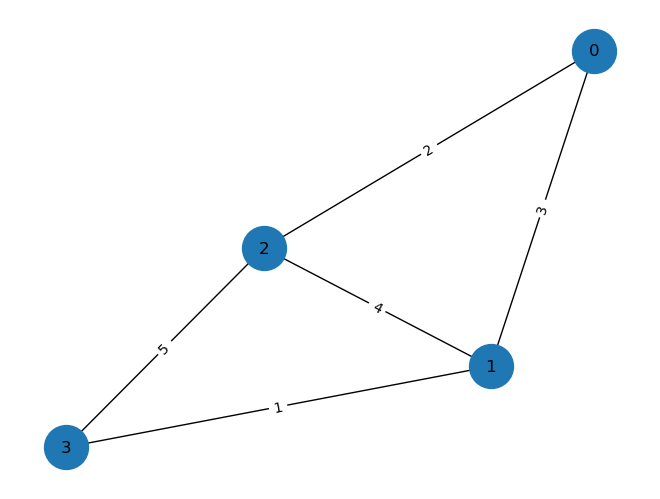


Cost Hamiltonian
SparsePauliOp(['IIZZ', 'IZIZ', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[3.+0.j, 2.+0.j, 4.+0.j, 1.+0.j, 5.+0.j])

Adjacency Matrix
[[0. 3. 2. 0.]
 [3. 0. 4. 1.]
 [2. 4. 0. 5.]
 [0. 1. 5. 0.]]

Optimal Energy
-4.3385893884479225

Top Bitstrings
0100 0.231648
1011 0.231648
0101 0.115106
1010 0.115106
0110 0.072099
1001 0.072099
0000 0.0625
1111 0.0625
0111 0.007446
1000 0.007446

Best Bitstring = 0100
QAOA Cut = 11
Classical Maximum = 12

Approximation Ratio = 0.9167
Approximation Ratio (%) = 91.67

QUANTUM-WALK QAOA
Best Bitstring : 0100
QAOA Cut       : 11
Classical Cut  : 12
Approx Ratio   : 0.9167


In [7]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit import ParameterVector

# ======================================================
# GRAPH
# ======================================================

G = nx.Graph()

G.add_weighted_edges_from([
    (0,1,3),
    (0,2,2),
    (1,2,4),
    (1,3,1),
    (2,3,5)
])

n = G.number_of_nodes()

# Draw graph
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1000
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=nx.get_edge_attributes(
        G,
        "weight"
    )
)

plt.show()

# ======================================================
# COST HAMILTONIAN
#
# Hc = Σ wij ZiZj
# ======================================================

paulis = []
coeffs = []

for i, j, w in G.edges(data="weight"):

    label = ["I"] * n

    label[n-1-i] = "Z"
    label[n-1-j] = "Z"

    paulis.append("".join(label))
    coeffs.append(float(w))

cost_hamiltonian = SparsePauliOp(
    paulis,
    coeffs
).simplify()

print("\nCost Hamiltonian")
print(cost_hamiltonian)

# ======================================================
# ADJACENCY MATRIX
# ======================================================

A = nx.to_numpy_array(G)

print("\nAdjacency Matrix")
print(A)

# ======================================================
# QAOA PARAMETERS
# ======================================================

p = 2

gamma = ParameterVector("γ", p)
beta = ParameterVector("β", p)

qc = QuantumCircuit(n)

# ======================================================
# INITIAL STATE
#
# Uniform superposition
# ======================================================

for q in range(n):
    qc.h(q)

# ======================================================
# QW-QAOA LAYERS
# ======================================================

for layer in range(p):

    # -----------------------------------------
    # COST UNITARY
    # exp(-iγ Zij)
    # -----------------------------------------

    for i, j, w in G.edges(data="weight"):

        qc.rzz(
            2 * w * gamma[layer],
            i,
            j
        )

    # -----------------------------------------
    # QUANTUM WALK MIXER
    #
    # exp[-iβ Aij(XX+YY)]
    # -----------------------------------------

    for i in range(n):

        for j in range(i+1, n):

            if A[i, j] != 0:

                qc.rxx(
                    2 * A[i, j] * beta[layer],
                    i,
                    j
                )

                qc.ryy(
                    2 * A[i, j] * beta[layer],
                    i,
                    j
                )

# ======================================================
# EXPECTATION FUNCTION
# ======================================================

def objective(params):

    bind = {}

    for i in range(p):
        bind[gamma[i]] = params[i]

    for i in range(p):
        bind[beta[i]] = params[p+i]

    circuit = qc.assign_parameters(bind)

    state = Statevector.from_instruction(
        circuit
    )

    value = np.real(
        state.expectation_value(
            cost_hamiltonian
        )
    )

    return value

# ======================================================
# OPTIMIZATION
# ======================================================

initial = np.random.uniform(
    0,
    np.pi,
    2*p
)

result = minimize(
    objective,
    initial,
    method="COBYLA",
    options={"maxiter":300}
)

best_params = result.x

print("\nOptimal Energy")
print(result.fun)

# ======================================================
# FINAL STATE
# ======================================================

bind = {}

for i in range(p):
    bind[gamma[i]] = best_params[i]

for i in range(p):
    bind[beta[i]] = best_params[p+i]

final_circuit = qc.assign_parameters(bind)

state = Statevector.from_instruction(
    final_circuit
)

probs = state.probabilities_dict()

# ======================================================
# TOP SOLUTIONS
# ======================================================

sorted_probs = sorted(
    probs.items(),
    key=lambda x: x[1],
    reverse=True
)

print("\nTop Bitstrings")

for bitstring, prob in sorted_probs[:10]:

    print(
        bitstring,
        round(prob,6)
    )

best_bitstring = sorted_probs[0][0]

print("\nBest Bitstring =", best_bitstring)

# ======================================================
# MAX-CUT VALUE
# ======================================================

def cut_value(bitstring, graph):

    bits = [int(x) for x in bitstring[::-1]]

    cut = 0

    for u, v, data in graph.edges(data=True):

        if bits[u] != bits[v]:

            cut += data["weight"]

    return cut

qaoa_cut = cut_value(
    best_bitstring,
    G
)

print("QAOA Cut =", qaoa_cut)

# ======================================================
# CLASSICAL OPTIMUM
# ======================================================

best_classical = 0

for i in range(2**n):

    b = format(i, f"0{n}b")

    value = cut_value(
        b,
        G
    )

    best_classical = max(
        best_classical,
        value
    )

print("Classical Maximum =", best_classical)

# ======================================================
# APPROXIMATION RATIO
# ======================================================

ratio = qaoa_cut / best_classical

print(
    "\nApproximation Ratio =",
    round(ratio,4)
)

print(
    "Approximation Ratio (%) =",
    round(100*ratio,2)
)

# ======================================================
# REPORT
# ======================================================

print("\n========================")
print("QUANTUM-WALK QAOA")
print("========================")
print("Best Bitstring :", best_bitstring)
print("QAOA Cut       :", qaoa_cut)
print("Classical Cut  :", best_classical)
print("Approx Ratio   :", round(ratio,4))
print("========================")

In [ ]:
Multi-Angle QAOA (MA-QAOA)

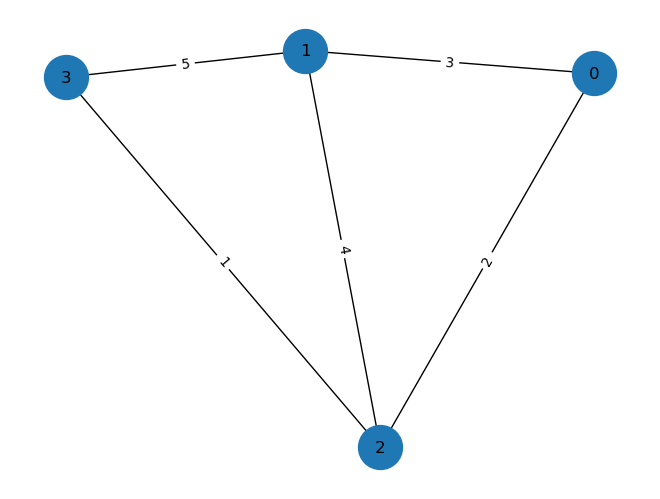


Optimal Energy
-8.993489394846382

Top Solutions
0010 0.49839
1101 0.49839
0110 0.001586
1001 0.001586
0011 2e-05
1100 2e-05
0111 3e-06
1000 3e-06
0001 0.0
1110 0.0

Best Bitstring = 0010
QAOA Cut = 12
Classical Max Cut = 12

Approximation Ratio = 1.0
Approximation Ratio (%) = 100.0

Learned Edge Gammas
Edge (0,1) : 3.9271
Edge (0,2) : 2.3574
Edge (1,2) : 2.9454
Edge (1,3) : 3.2987
Edge (2,3) : 3.1408

Learned Node Betas
Node 0 : 0.7917
Node 1 : 1.5711
Node 2 : 0.8417
Node 3 : 0.7852

MULTI-ANGLE QAOA
Vertices       : 4
Edges          : 5
Parameters     : 9
Best Bitstring : 0010
QAOA Cut       : 12
Classical Cut  : 12
Approx Ratio   : 1.0


In [8]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit.circuit import ParameterVector

# =====================================================
# GRAPH
# =====================================================

G = nx.Graph()

G.add_weighted_edges_from([
    (0,1,3),
    (0,2,2),
    (1,2,4),
    (1,3,5),
    (2,3,1)
])

n = G.number_of_nodes()
m = G.number_of_edges()

# Draw graph
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1000
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=nx.get_edge_attributes(
        G,
        "weight"
    )
)

plt.show()

# =====================================================
# COST HAMILTONIAN
# =====================================================

paulis = []
coeffs = []

for i, j, w in G.edges(data="weight"):

    label = ["I"] * n

    label[n-1-i] = "Z"
    label[n-1-j] = "Z"

    paulis.append("".join(label))
    coeffs.append(float(w))

cost_hamiltonian = SparsePauliOp(
    paulis,
    coeffs
).simplify()

# =====================================================
# MA-QAOA DEPTH
# =====================================================

p = 1

# One gamma per edge
gamma = ParameterVector(
    "γ",
    m
)

# One beta per qubit
beta = ParameterVector(
    "β",
    n
)

# =====================================================
# CIRCUIT
# =====================================================

qc = QuantumCircuit(n)

# Initial state |+>
for q in range(n):
    qc.h(q)

# =====================================================
# COST LAYER
# =====================================================

edge_list = list(
    G.edges(data="weight")
)

for edge_idx, (i, j, w) in enumerate(edge_list):

    qc.rzz(
        2 * w * gamma[edge_idx],
        i,
        j
    )

# =====================================================
# MIXER LAYER
# =====================================================

for q in range(n):

    qc.rx(
        2 * beta[q],
        q
    )

# =====================================================
# OBJECTIVE FUNCTION
# =====================================================

def expectation(params):

    bind = {}

    # gamma parameters
    for k in range(m):
        bind[gamma[k]] = params[k]

    # beta parameters
    for k in range(n):
        bind[beta[k]] = params[m+k]

    circuit = qc.assign_parameters(bind)

    state = Statevector.from_instruction(
        circuit
    )

    value = np.real(
        state.expectation_value(
            cost_hamiltonian
        )
    )

    return value

# =====================================================
# OPTIMIZATION
# =====================================================

num_params = m + n

initial = np.random.uniform(
    0,
    np.pi,
    num_params
)

result = minimize(
    expectation,
    initial,
    method="COBYLA",
    options={"maxiter":500}
)

best_params = result.x

print("\nOptimal Energy")
print(result.fun)

# =====================================================
# FINAL STATE
# =====================================================

bind = {}

for k in range(m):
    bind[gamma[k]] = best_params[k]

for k in range(n):
    bind[beta[k]] = best_params[m+k]

final_circuit = qc.assign_parameters(
    bind
)

state = Statevector.from_instruction(
    final_circuit
)

probs = state.probabilities_dict()

# =====================================================
# SORT SOLUTIONS
# =====================================================

sorted_probs = sorted(
    probs.items(),
    key=lambda x: x[1],
    reverse=True
)

print("\nTop Solutions")

for bitstring, prob in sorted_probs[:10]:

    print(
        bitstring,
        round(prob,6)
    )

best_bitstring = sorted_probs[0][0]

print("\nBest Bitstring =", best_bitstring)

# =====================================================
# CUT VALUE
# =====================================================

def cut_value(bitstring, graph):

    bits = [int(x) for x in bitstring[::-1]]

    cut = 0

    for u, v, data in graph.edges(data=True):

        if bits[u] != bits[v]:

            cut += data["weight"]

    return cut

qaoa_cut = cut_value(
    best_bitstring,
    G
)

print("QAOA Cut =", qaoa_cut)

# =====================================================
# CLASSICAL OPTIMUM
# =====================================================

best_classical = 0

for i in range(2**n):

    b = format(i, f"0{n}b")

    value = cut_value(
        b,
        G
    )

    best_classical = max(
        best_classical,
        value
    )

print("Classical Max Cut =", best_classical)

# =====================================================
# APPROXIMATION RATIO
# =====================================================

ratio = qaoa_cut / best_classical

print(
    "\nApproximation Ratio =",
    round(ratio,4)
)

print(
    "Approximation Ratio (%) =",
    round(100*ratio,2)
)

# =====================================================
# PARAMETERS
# =====================================================

print("\nLearned Edge Gammas")

for k, (i,j,w) in enumerate(edge_list):

    print(
        f"Edge ({i},{j}) : "
        f"{best_params[k]:.4f}"
    )

print("\nLearned Node Betas")

for q in range(n):

    print(
        f"Node {q} : "
        f"{best_params[m+q]:.4f}"
    )

# =====================================================
# FINAL REPORT
# =====================================================

print("\n=======================")
print("MULTI-ANGLE QAOA")
print("=======================")
print("Vertices       :", n)
print("Edges          :", m)
print("Parameters     :", m+n)
print("Best Bitstring :", best_bitstring)
print("QAOA Cut       :", qaoa_cut)
print("Classical Cut  :", best_classical)
print("Approx Ratio   :", round(ratio,4))
print("=======================")

In [ ]:
Adaptive QAOA (Ada-QAOA)

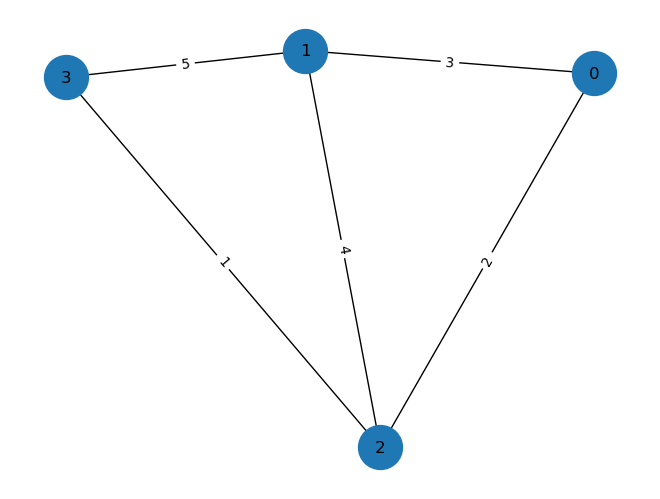


Optimal Parameters
gamma0 = 0.4964256237412984
beta0  = 1.3913420131290664

Optimal Energy
-2.835431325908156

Top Solutions
0111 0.130117
1000 0.130117
0011 0.113801
1100 0.113801
0110 0.113801
1001 0.113801
0010 0.073036
1101 0.073036
0001 0.034431
1110 0.034431

Best Bitstring = 0111
QAOA Cut = 6
Classical Max Cut = 12

Approximation Ratio = 0.5
Approximation Ratio (%) = 50.0

Layer Schedule
Layer 1: gamma=0.4964, beta=1.3913
Layer 2: gamma=0.4064, beta=1.1131
Layer 3: gamma=0.3328, beta=0.8348
Layer 4: gamma=0.2724, beta=0.5565
Layer 5: gamma=0.2231, beta=0.2783

ADAPTIVE QAOA
Depth P       : 5
Parameters    : 2
Best Bitstring: 0111
QAOA Cut      : 6
Classical Cut : 12
Approx Ratio  : 0.5


In [9]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.quantum_info import SparsePauliOp

# =====================================================
# GRAPH
# =====================================================

G = nx.Graph()

G.add_weighted_edges_from([
    (0, 1, 3),
    (0, 2, 2),
    (1, 2, 4),
    (1, 3, 5),
    (2, 3, 1)
])

n = G.number_of_nodes()

# =====================================================
# VISUALIZE GRAPH
# =====================================================

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1000
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=nx.get_edge_attributes(
        G,
        "weight"
    )
)

plt.show()

# =====================================================
# COST HAMILTONIAN
# HC = Σ wij ZiZj
# =====================================================

paulis = []
coeffs = []

for i, j, w in G.edges(data="weight"):

    label = ["I"] * n

    label[n-1-i] = "Z"
    label[n-1-j] = "Z"

    paulis.append("".join(label))
    coeffs.append(float(w))

cost_hamiltonian = SparsePauliOp(
    paulis,
    coeffs
).simplify()

# =====================================================
# ADAPTIVE QAOA DEPTH
# =====================================================

P = 5

# =====================================================
# BUILD CIRCUIT
# =====================================================

def build_circuit(gamma0, beta0):

    qc = QuantumCircuit(n)

    # Initial |+>
    for q in range(n):
        qc.h(q)

    # Adaptive layers
    for p in range(P):

        gamma_p = gamma0 * np.exp(-p / P)

        beta_p = beta0 * (1 - p / P)

        # Cost Layer
        for i, j, w in G.edges(data="weight"):

            qc.rzz(
                2 * w * gamma_p,
                i,
                j
            )

        # Mixer Layer
        for q in range(n):

            qc.rx(
                2 * beta_p,
                q
            )

    return qc

# =====================================================
# OBJECTIVE FUNCTION
# =====================================================

def objective(params):

    gamma0 = params[0]
    beta0 = params[1]

    circuit = build_circuit(
        gamma0,
        beta0
    )

    state = Statevector.from_instruction(
        circuit
    )

    value = np.real(
        state.expectation_value(
            cost_hamiltonian
        )
    )

    return value

# =====================================================
# OPTIMIZATION
# =====================================================

initial = np.array([
    0.5,
    0.5
])

result = minimize(
    objective,
    initial,
    method="COBYLA",
    options={
        "maxiter": 300
    }
)

gamma0_opt = result.x[0]
beta0_opt = result.x[1]

print("\nOptimal Parameters")
print("gamma0 =", gamma0_opt)
print("beta0  =", beta0_opt)

print("\nOptimal Energy")
print(result.fun)

# =====================================================
# FINAL CIRCUIT
# =====================================================

final_circuit = build_circuit(
    gamma0_opt,
    beta0_opt
)

# =====================================================
# STATEVECTOR
# =====================================================

state = Statevector.from_instruction(
    final_circuit
)

probs = state.probabilities_dict()

sorted_probs = sorted(
    probs.items(),
    key=lambda x: x[1],
    reverse=True
)

# =====================================================
# TOP BITSTRINGS
# =====================================================

print("\nTop Solutions")

for bitstring, prob in sorted_probs[:10]:

    print(
        bitstring,
        round(prob, 6)
    )

best_bitstring = sorted_probs[0][0]

print("\nBest Bitstring =", best_bitstring)

# =====================================================
# CUT VALUE
# =====================================================

def cut_value(bitstring, graph):

    bits = [int(x) for x in bitstring[::-1]]

    value = 0

    for u, v, data in graph.edges(data=True):

        if bits[u] != bits[v]:

            value += data["weight"]

    return value

qaoa_cut = cut_value(
    best_bitstring,
    G
)

print("QAOA Cut =", qaoa_cut)

# =====================================================
# CLASSICAL MAX-CUT
# =====================================================

best_classical = 0

for i in range(2**n):

    b = format(
        i,
        f"0{n}b"
    )

    cut = cut_value(
        b,
        G
    )

    best_classical = max(
        best_classical,
        cut
    )

print("Classical Max Cut =", best_classical)

# =====================================================
# APPROXIMATION RATIO
# =====================================================

ratio = qaoa_cut / best_classical

print(
    "\nApproximation Ratio =",
    round(ratio, 4)
)

print(
    "Approximation Ratio (%) =",
    round(100 * ratio, 2)
)

# =====================================================
# ADAPTIVE SCHEDULE
# =====================================================

print("\nLayer Schedule")

for p in range(P):

    gamma_p = gamma0_opt * np.exp(-p / P)

    beta_p = beta0_opt * (1 - p / P)

    print(
        f"Layer {p+1}: "
        f"gamma={gamma_p:.4f}, "
        f"beta={beta_p:.4f}"
    )

# =====================================================
# REPORT
# =====================================================

print("\n========================")
print("ADAPTIVE QAOA")
print("========================")
print("Depth P       :", P)
print("Parameters    :", 2)
print("Best Bitstring:", best_bitstring)
print("QAOA Cut      :", qaoa_cut)
print("Classical Cut :", best_classical)
print("Approx Ratio  :", round(ratio,4))
print("========================")

In [ ]:
Digitized Counter-Diabatic QAOA (DC-QAOA)

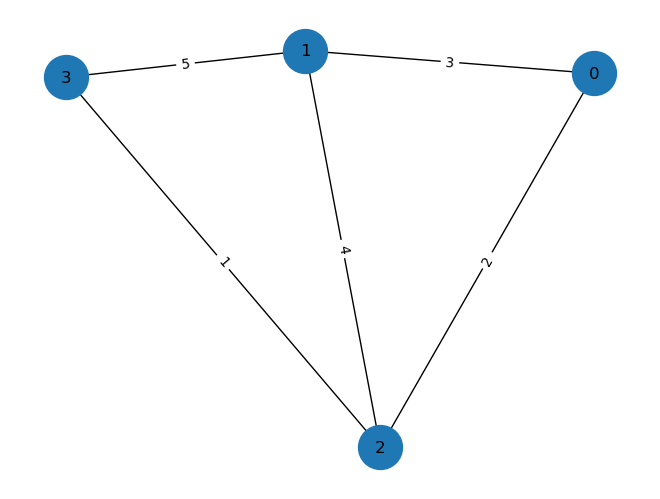


Optimal Energy
-6.28107518636184

Top Solutions
0110 0.232987
0011 0.229046
1100 0.227157
1001 0.223029
1010 0.021981
0101 0.020272
1011 0.011064
0001 0.009986
0100 0.009592
1110 0.005981

Best Bitstring = 0110

DIGITIZED COUNTER-DIABATIC QAOA
Depth p         : 3
Best Bitstring  : 0110
QAOA Cut        : 11
Classical Cut   : 12
Approx Ratio    : 0.9167

Gamma Parameters
[3.44027599 2.97882365 1.55551833]

Beta Parameters
[1.99235997 1.46059912 0.80101029]

Lambda Parameters
[0.01557131 2.35227924 2.6346049 ]


In [10]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.quantum_info import SparsePauliOp

# ==========================================================
# GRAPH
# ==========================================================

G = nx.Graph()

G.add_weighted_edges_from([
    (0,1,3),
    (0,2,2),
    (1,2,4),
    (1,3,5),
    (2,3,1)
])

n = G.number_of_nodes()

# ==========================================================
# DRAW GRAPH
# ==========================================================

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1000
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=nx.get_edge_attributes(
        G,
        "weight"
    )
)

plt.show()

# ==========================================================
# COST HAMILTONIAN
# ==========================================================

cost_paulis = []
cost_coeffs = []

for i,j,w in G.edges(data="weight"):

    label = ["I"] * n

    label[n-1-i] = "Z"
    label[n-1-j] = "Z"

    cost_paulis.append(
        "".join(label)
    )

    cost_coeffs.append(
        float(w)
    )

HC = SparsePauliOp(
    cost_paulis,
    cost_coeffs
).simplify()

# ==========================================================
# DC-QAOA PARAMETERS
# ==========================================================

p = 3

# ==========================================================
# BUILD CIRCUIT
# ==========================================================

def build_circuit(gamma, beta, lam):

    qc = QuantumCircuit(n)

    # Initial state
    for q in range(n):
        qc.h(q)

    for layer in range(p):

        # ----------------------------------
        # COST UNITARY
        # ----------------------------------

        for i,j,w in G.edges(data="weight"):

            qc.rzz(
                2*w*gamma[layer],
                i,
                j
            )

        # ----------------------------------
        # MIXER
        # ----------------------------------

        for q in range(n):

            qc.rx(
                2*beta[layer],
                q
            )

        # ----------------------------------
        # COUNTER-DIABATIC TERM
        # λ H_CD
        # ----------------------------------

        for q in range(n):

            qc.ry(
                2*lam[layer],
                q
            )

    return qc

# ==========================================================
# OBJECTIVE FUNCTION
# ==========================================================

def objective(params):

    gamma = params[0:p]

    beta = params[p:2*p]

    lam = params[2*p:3*p]

    circuit = build_circuit(
        gamma,
        beta,
        lam
    )

    state = Statevector.from_instruction(
        circuit
    )

    energy = np.real(
        state.expectation_value(
            HC
        )
    )

    return energy

# ==========================================================
# INITIAL PARAMETERS
# ==========================================================

initial = np.random.uniform(
    0,
    np.pi,
    3*p
)

# ==========================================================
# OPTIMIZE
# ==========================================================

result = minimize(
    objective,
    initial,
    method="COBYLA",
    options={
        "maxiter":500
    }
)

best = result.x

gamma_opt = best[0:p]
beta_opt = best[p:2*p]
lam_opt = best[2*p:3*p]

print("\nOptimal Energy")
print(result.fun)

# ==========================================================
# FINAL STATE
# ==========================================================

final_circuit = build_circuit(
    gamma_opt,
    beta_opt,
    lam_opt
)

state = Statevector.from_instruction(
    final_circuit
)

probs = state.probabilities_dict()

sorted_probs = sorted(
    probs.items(),
    key=lambda x:x[1],
    reverse=True
)

print("\nTop Solutions")

for bitstring, prob in sorted_probs[:10]:

    print(
        bitstring,
        round(prob,6)
    )

best_bitstring = sorted_probs[0][0]

print("\nBest Bitstring =", best_bitstring)

# ==========================================================
# CUT VALUE
# ==========================================================

def cut_value(bitstring, graph):

    bits = [int(x) for x in bitstring[::-1]]

    value = 0

    for u,v,data in graph.edges(data=True):

        if bits[u] != bits[v]:

            value += data["weight"]

    return value

qaoa_cut = cut_value(
    best_bitstring,
    G
)

# ==========================================================
# CLASSICAL MAXCUT
# ==========================================================

best_classical = 0

for i in range(2**n):

    b = format(
        i,
        f"0{n}b"
    )

    best_classical = max(
        best_classical,
        cut_value(b,G)
    )

ratio = qaoa_cut / best_classical

# ==========================================================
# RESULTS
# ==========================================================

print("\n============================")
print("DIGITIZED COUNTER-DIABATIC QAOA")
print("============================")
print("Depth p         :", p)
print("Best Bitstring  :", best_bitstring)
print("QAOA Cut        :", qaoa_cut)
print("Classical Cut   :", best_classical)
print("Approx Ratio    :", round(ratio,4))
print("============================")

print("\nGamma Parameters")
print(gamma_opt)

print("\nBeta Parameters")
print(beta_opt)

print("\nLambda Parameters")
print(lam_opt)

In [ ]:
Grover-Mixer QAOA (GM-QAOA)

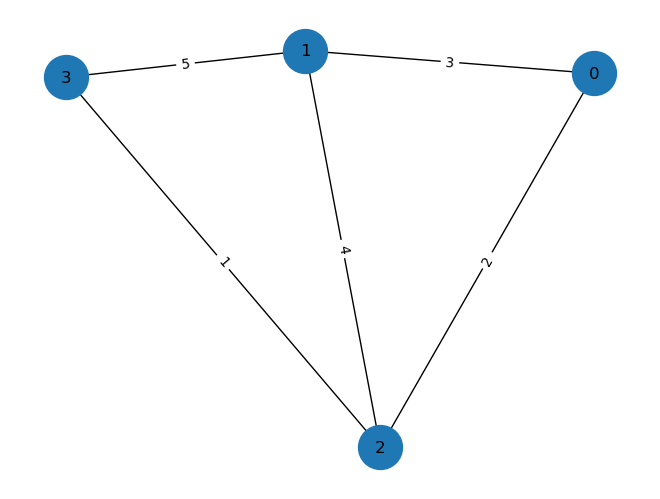


Optimal Energy
-2.852806290512948

Top Solutions
0101 0.151153
1010 0.151153
0011 0.109675
1100 0.109675
0110 0.109675
1001 0.109675
0111 0.036377
1000 0.036377
0100 0.031082
1011 0.031082

Best Bitstring = 0101

GROVER MIXER QAOA
Depth p         : 3
Best Bitstring  : 0101
QAOA Cut        : 8
Classical Cut   : 12
Approx Ratio    : 0.6667

Gamma Parameters
[0.5188222  2.32586094 2.8770433 ]

Beta Parameters
[2.93494642 2.88282032 2.22791724]


In [11]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.quantum_info import SparsePauliOp

# =====================================================
# GRAPH
# =====================================================

G = nx.Graph()

G.add_weighted_edges_from([
    (0,1,3),
    (0,2,2),
    (1,2,4),
    (1,3,5),
    (2,3,1)
])

n = G.number_of_nodes()

# =====================================================
# DRAW GRAPH
# =====================================================

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1000
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=nx.get_edge_attributes(
        G,
        "weight"
    )
)

plt.show()

# =====================================================
# COST HAMILTONIAN
# Hc = Σ wij ZiZj
# =====================================================

paulis = []
coeffs = []

for i,j,w in G.edges(data="weight"):

    label = ["I"] * n

    label[n-1-i] = "Z"
    label[n-1-j] = "Z"

    paulis.append("".join(label))
    coeffs.append(float(w))

HC = SparsePauliOp(
    paulis,
    coeffs
).simplify()

# =====================================================
# GROVER DIFFUSION OPERATOR
# =====================================================

def grover_diffusion(qc, qubits):

    n = len(qubits)

    qc.h(qubits)
    qc.x(qubits)

    qc.h(qubits[-1])

    qc.mcx(
        qubits[:-1],
        qubits[-1]
    )

    qc.h(qubits[-1])

    qc.x(qubits)
    qc.h(qubits)

# =====================================================
# QAOA DEPTH
# =====================================================

p = 3

# =====================================================
# BUILD CIRCUIT
# =====================================================

def build_circuit(gamma, beta):

    qc = QuantumCircuit(n)

    # |s>
    for q in range(n):
        qc.h(q)

    for layer in range(p):

        # ---------------------------------
        # COST LAYER
        # ---------------------------------

        for i,j,w in G.edges(data="weight"):

            qc.rzz(
                2*w*gamma[layer],
                i,
                j
            )

        # ---------------------------------
        # GROVER MIXER
        # ---------------------------------

        repetitions = max(
            1,
            int(abs(beta[layer])*2)
        )

        for _ in range(repetitions):

            grover_diffusion(
                qc,
                list(range(n))
            )

    return qc

# =====================================================
# OBJECTIVE FUNCTION
# =====================================================

def objective(params):

    gamma = params[:p]
    beta = params[p:]

    circuit = build_circuit(
        gamma,
        beta
    )

    state = Statevector.from_instruction(
        circuit
    )

    value = np.real(
        state.expectation_value(
            HC
        )
    )

    return value

# =====================================================
# INITIAL PARAMETERS
# =====================================================

initial = np.random.uniform(
    0,
    np.pi,
    2*p
)

# =====================================================
# OPTIMIZATION
# =====================================================

result = minimize(
    objective,
    initial,
    method="COBYLA",
    options={
        "maxiter":500
    }
)

best = result.x

gamma_opt = best[:p]
beta_opt = best[p:]

print("\nOptimal Energy")
print(result.fun)

# =====================================================
# FINAL CIRCUIT
# =====================================================

final_circuit = build_circuit(
    gamma_opt,
    beta_opt
)

# =====================================================
# STATEVECTOR
# =====================================================

state = Statevector.from_instruction(
    final_circuit
)

probs = state.probabilities_dict()

sorted_probs = sorted(
    probs.items(),
    key=lambda x:x[1],
    reverse=True
)

print("\nTop Solutions")

for bitstring, prob in sorted_probs[:10]:

    print(
        bitstring,
        round(prob,6)
    )

best_bitstring = sorted_probs[0][0]

print("\nBest Bitstring =", best_bitstring)

# =====================================================
# CUT VALUE
# =====================================================

def cut_value(bitstring, graph):

    bits = [int(x) for x in bitstring[::-1]]

    value = 0

    for u,v,data in graph.edges(data=True):

        if bits[u] != bits[v]:

            value += data["weight"]

    return value

qaoa_cut = cut_value(
    best_bitstring,
    G
)

# =====================================================
# CLASSICAL OPTIMUM
# =====================================================

best_classical = 0

for i in range(2**n):

    b = format(
        i,
        f"0{n}b"
    )

    best_classical = max(
        best_classical,
        cut_value(b,G)
    )

ratio = qaoa_cut / best_classical

# =====================================================
# REPORT
# =====================================================

print("\n======================")
print("GROVER MIXER QAOA")
print("======================")
print("Depth p         :", p)
print("Best Bitstring  :", best_bitstring)
print("QAOA Cut        :", qaoa_cut)
print("Classical Cut   :", best_classical)
print("Approx Ratio    :", round(ratio,4))
print("======================")

print("\nGamma Parameters")
print(gamma_opt)

print("\nBeta Parameters")
print(beta_opt)

In [ ]:
Warm-Start QAOA (WS-QAOA)

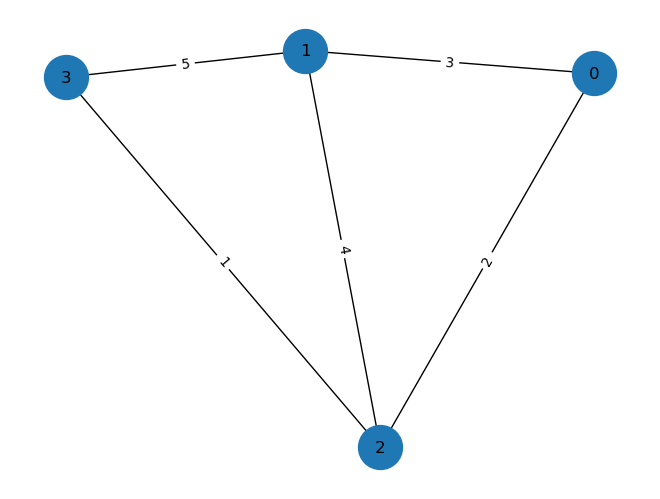


Warm Start Probabilities
[0.85 0.2  0.75 0.15]

Optimal Energy
-5.217418820391747

Top Solutions
0010 0.248382
1101 0.212021
1100 0.123243
0011 0.070941
1010 0.061037
0100 0.06088
1011 0.048985
0111 0.041002
1000 0.034647
0101 0.031249

Best Bitstring = 0010

WARM START QAOA
Best Bitstring : 0010
QAOA Cut       : 12
Classical Cut  : 12
Approx Ratio   : 1.0

Gamma
[4.00854203 2.50034514 3.07745911]

Beta
[2.58262337 2.36790646 0.29098564]


In [12]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info import Statevector

# =====================================================
# GRAPH
# =====================================================

G = nx.Graph()

G.add_weighted_edges_from([
    (0,1,3),
    (0,2,2),
    (1,2,4),
    (1,3,5),
    (2,3,1)
])

n = G.number_of_nodes()

# =====================================================
# DRAW GRAPH
# =====================================================

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1000
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=nx.get_edge_attributes(
        G,
        "weight"
    )
)

plt.show()

# =====================================================
# COST HAMILTONIAN
# =====================================================

paulis = []
coeffs = []

for i,j,w in G.edges(data="weight"):

    label = ["I"] * n

    label[n-1-i] = "Z"
    label[n-1-j] = "Z"

    paulis.append("".join(label))
    coeffs.append(float(w))

HC = SparsePauliOp(
    paulis,
    coeffs
).simplify()

# =====================================================
# CLASSICAL WARM START
# =====================================================

# Example:
# obtained from LP / SDP / Greedy solver

p = np.array([
    0.85,
    0.20,
    0.75,
    0.15
])

print("\nWarm Start Probabilities")
print(p)

# =====================================================
# QAOA DEPTH
# =====================================================

P = 3

# =====================================================
# BUILD CIRCUIT
# =====================================================

def build_circuit(gamma, beta):

    qc = QuantumCircuit(n)

    # --------------------------------------
    # Warm Start Initial State
    # --------------------------------------

    for q in range(n):

        theta = 2 * np.arcsin(
            np.sqrt(p[q])
        )

        qc.ry(theta, q)

    # --------------------------------------
    # QAOA Layers
    # --------------------------------------

    for layer in range(P):

        # Cost Layer

        for i,j,w in G.edges(data="weight"):

            qc.rzz(
                2*w*gamma[layer],
                i,
                j
            )

        # Mixer Layer

        for q in range(n):

            qc.rx(
                2*beta[layer],
                q
            )

    return qc

# =====================================================
# OBJECTIVE FUNCTION
# =====================================================

def objective(params):

    gamma = params[:P]

    beta = params[P:]

    circuit = build_circuit(
        gamma,
        beta
    )

    state = Statevector.from_instruction(
        circuit
    )

    energy = np.real(
        state.expectation_value(HC)
    )

    return energy

# =====================================================
# INITIAL PARAMETERS
# =====================================================

initial = np.random.uniform(
    0,
    np.pi,
    2*P
)

# =====================================================
# OPTIMIZE
# =====================================================

result = minimize(
    objective,
    initial,
    method="COBYLA",
    options={
        "maxiter":500
    }
)

best = result.x

gamma_opt = best[:P]
beta_opt = best[P:]

print("\nOptimal Energy")
print(result.fun)

# =====================================================
# FINAL STATE
# =====================================================

final_circuit = build_circuit(
    gamma_opt,
    beta_opt
)

state = Statevector.from_instruction(
    final_circuit
)

probs = state.probabilities_dict()

sorted_probs = sorted(
    probs.items(),
    key=lambda x:x[1],
    reverse=True
)

print("\nTop Solutions")

for bitstring, prob in sorted_probs[:10]:

    print(
        bitstring,
        round(prob,6)
    )

best_bitstring = sorted_probs[0][0]

print("\nBest Bitstring =", best_bitstring)

# =====================================================
# MAX CUT VALUE
# =====================================================

def cut_value(bitstring, graph):

    bits = [int(x) for x in bitstring[::-1]]

    value = 0

    for u,v,data in graph.edges(data=True):

        if bits[u] != bits[v]:

            value += data["weight"]

    return value

qaoa_cut = cut_value(
    best_bitstring,
    G
)

# =====================================================
# CLASSICAL OPTIMUM
# =====================================================

best_classical = 0

for i in range(2**n):

    b = format(i,f"0{n}b")

    best_classical = max(
        best_classical,
        cut_value(b,G)
    )

ratio = qaoa_cut / best_classical

# =====================================================
# REPORT
# =====================================================

print("\n=========================")
print("WARM START QAOA")
print("=========================")
print("Best Bitstring :", best_bitstring)
print("QAOA Cut       :", qaoa_cut)
print("Classical Cut  :", best_classical)
print("Approx Ratio   :", round(ratio,4))
print("=========================")

print("\nGamma")
print(gamma_opt)

print("\nBeta")
print(beta_opt)

In [ ]:
Recursive QAOA (RQAOA)

Fixing correlation (1, 3) = -0.5652
Fixing correlation (1, 2) = -0.9675

Remaining Nodes
[0, 1, 2]

Exact Final Solution
(0, 1, 0)
Cut = 3


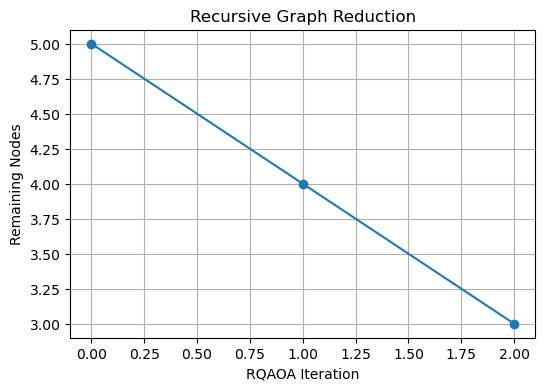


RQAOA RESULTS
Initial Nodes : 5
Final Nodes   : 3
Final Cut     : 3


In [13]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from itertools import product

from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import QAOAAnsatz
from qiskit.primitives import StatevectorEstimator

from scipy.optimize import minimize

# =====================================================
# GRAPH
# =====================================================

G = nx.Graph()

G.add_weighted_edges_from([
    (0,1,3),
    (0,2,2),
    (1,2,4),
    (1,3,5),
    (2,3,1),
    (3,4,2)
])

# =====================================================
# COST HAMILTONIAN
# =====================================================

def build_cost_hamiltonian(graph):

    n = graph.number_of_nodes()

    paulis = []
    coeffs = []

    for i,j,w in graph.edges(data="weight"):

        label = ["I"] * n

        label[n-1-i] = "Z"
        label[n-1-j] = "Z"

        paulis.append(
            "".join(label)
        )

        coeffs.append(
            float(w)
        )

    return SparsePauliOp(
        paulis,
        coeffs
    ).simplify()

# =====================================================
# RUN SMALL QAOA
# =====================================================

def run_qaoa(graph,p=1):

    HC = build_cost_hamiltonian(graph)

    ansatz = QAOAAnsatz(
        cost_operator=HC,
        reps=p
    )

    estimator = StatevectorEstimator()

    def objective(params):

        job = estimator.run(
            [(ansatz,HC,params)]
        )

        return job.result()[0].data.evs

    x0 = np.random.uniform(
        0,
        np.pi,
        ansatz.num_parameters
    )

    result = minimize(
        objective,
        x0,
        method="COBYLA"
    )

    circuit = ansatz.assign_parameters(
        result.x
    )

    state = Statevector.from_instruction(
        circuit
    )

    return state

# =====================================================
# CORRELATION
# =====================================================

def strongest_correlation(graph,state):

    n = graph.number_of_nodes()

    best_pair = None
    best_corr = 0

    for i,j in graph.edges():

        label = ["I"] * n

        label[n-1-i] = "Z"
        label[n-1-j] = "Z"

        op = SparsePauliOp(
            ["".join(label)],
            [1]
        )

        corr = np.real(
            state.expectation_value(op)
        )

        if abs(corr) > abs(best_corr):

            best_corr = corr
            best_pair = (i,j)

    return best_pair,best_corr

# =====================================================
# REDUCE GRAPH
# =====================================================

def reduce_graph(graph):

    state = run_qaoa(graph)

    pair,corr = strongest_correlation(
        graph,
        state
    )

    i,j = pair

    print(
        f"Fixing correlation "
        f"{pair} = {corr:.4f}"
    )

    H = graph.copy()

    if j in H:
        H.remove_node(j)

    mapping = {
        node:k
        for k,node in enumerate(
            H.nodes()
        )
    }

    H = nx.relabel_nodes(
        H,
        mapping
    )

    return H

# =====================================================
# RECURSIVE QAOA
# =====================================================

current_graph = G.copy()

history = []

while current_graph.number_of_nodes() > 3:

    history.append(
        current_graph.number_of_nodes()
    )

    current_graph = reduce_graph(
        current_graph
    )

history.append(
    current_graph.number_of_nodes()
)

print("\nRemaining Nodes")
print(current_graph.nodes())

# =====================================================
# EXACT SOLVER
# =====================================================

n = current_graph.number_of_nodes()

best_cut = -1
best_string = None

for bits in product([0,1], repeat=n):

    cut = 0

    for u,v,w in current_graph.edges(
        data="weight"
    ):

        if bits[u] != bits[v]:

            cut += w

    if cut > best_cut:

        best_cut = cut
        best_string = bits

print("\nExact Final Solution")
print(best_string)

print("Cut =", best_cut)

# =====================================================
# VISUALIZATION
# =====================================================

plt.figure(figsize=(6,4))

plt.plot(
    range(len(history)),
    history,
    marker='o'
)

plt.xlabel("RQAOA Iteration")
plt.ylabel("Remaining Nodes")
plt.title("Recursive Graph Reduction")
plt.grid(True)

plt.show()

print("\n========================")
print("RQAOA RESULTS")
print("========================")
print("Initial Nodes :", G.number_of_nodes())
print("Final Nodes   :", current_graph.number_of_nodes())
print("Final Cut     :", best_cut)
print("========================")

In [ ]:
Heisenberg QAOA

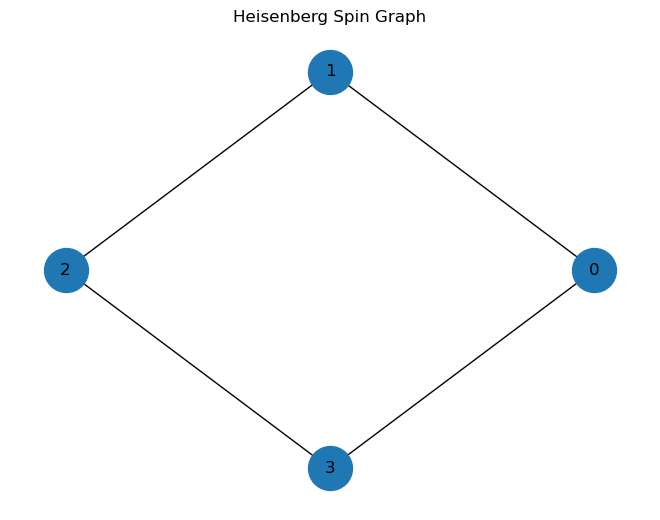


Heisenberg Hamiltonian
SparsePauliOp(['IIXX', 'IIYY', 'IIZZ', 'XIIX', 'YIIY', 'ZIIZ', 'IXXI', 'IYYI', 'IZZI', 'XXII', 'YYII', 'ZZII'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
 1.+0.j, 1.+0.j, 1.+0.j])

Optimal Energy
4.000000000000002

Top States
0010 0.0625
1101 0.0625
0011 0.0625
0100 0.0625
0110 0.0625
0111 0.0625
1000 0.0625
1001 0.0625
1011 0.0625
1100 0.0625

HEISENBERG QAOA
Qubits          : 4
Depth           : 2
Jx              : 1.0
Jy              : 1.0
Jz              : 1.0
Best State      : 0010
Magnetization   : 2
Energy          : 4.000000000000002

Gamma Parameters
[0.60786789 1.39677178]

Beta Parameters
[2.54249032 2.62716627]


In [14]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info import Statevector

# ==========================================================
# HEISENBERG GRAPH
# ==========================================================

G = nx.Graph()

G.add_edges_from([
    (0,1),
    (1,2),
    (2,3),
    (3,0)
])

n = G.number_of_nodes()

# ==========================================================
# COUPLING CONSTANTS
# ==========================================================

Jx = 1.0
Jy = 1.0
Jz = 1.0

# ==========================================================
# DRAW GRAPH
# ==========================================================

pos = nx.circular_layout(G)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1000
)

plt.title("Heisenberg Spin Graph")
plt.show()

# ==========================================================
# BUILD HEISENBERG HAMILTONIAN
# ==========================================================

paulis = []
coeffs = []

for i,j in G.edges():

    # XX

    label = ["I"] * n

    label[n-1-i] = "X"
    label[n-1-j] = "X"

    paulis.append(
        "".join(label)
    )

    coeffs.append(Jx)

    # YY

    label = ["I"] * n

    label[n-1-i] = "Y"
    label[n-1-j] = "Y"

    paulis.append(
        "".join(label)
    )

    coeffs.append(Jy)

    # ZZ

    label = ["I"] * n

    label[n-1-i] = "Z"
    label[n-1-j] = "Z"

    paulis.append(
        "".join(label)
    )

    coeffs.append(Jz)

HC = SparsePauliOp(
    paulis,
    coeffs
).simplify()

print("\nHeisenberg Hamiltonian")
print(HC)

# ==========================================================
# QAOA DEPTH
# ==========================================================

p = 2

# ==========================================================
# BUILD CIRCUIT
# ==========================================================

def build_circuit(gamma,beta):

    qc = QuantumCircuit(n)

    # Initial superposition

    for q in range(n):
        qc.h(q)

    for layer in range(p):

        # ----------------------------------
        # COST LAYER
        # exp(-iγH)
        # ----------------------------------

        for i,j in G.edges():

            # XX

            qc.rxx(
                2*Jx*gamma[layer],
                i,
                j
            )

            # YY

            qc.ryy(
                2*Jy*gamma[layer],
                i,
                j
            )

            # ZZ

            qc.rzz(
                2*Jz*gamma[layer],
                i,
                j
            )

        # ----------------------------------
        # MIXER
        # ----------------------------------

        for q in range(n):

            qc.rx(
                2*beta[layer],
                q
            )

    return qc

# ==========================================================
# OBJECTIVE FUNCTION
# ==========================================================

def objective(params):

    gamma = params[:p]

    beta = params[p:]

    circuit = build_circuit(
        gamma,
        beta
    )

    state = Statevector.from_instruction(
        circuit
    )

    energy = np.real(
        state.expectation_value(
            HC
        )
    )

    return energy

# ==========================================================
# OPTIMIZATION
# ==========================================================

initial = np.random.uniform(
    0,
    np.pi,
    2*p
)

result = minimize(
    objective,
    initial,
    method="COBYLA",
    options={
        "maxiter":500
    }
)

best = result.x

gamma_opt = best[:p]

beta_opt = best[p:]

print("\nOptimal Energy")
print(result.fun)

# ==========================================================
# FINAL CIRCUIT
# ==========================================================

final_circuit = build_circuit(
    gamma_opt,
    beta_opt
)

# ==========================================================
# FINAL STATE
# ==========================================================

state = Statevector.from_instruction(
    final_circuit
)

probs = state.probabilities_dict()

sorted_probs = sorted(
    probs.items(),
    key=lambda x:x[1],
    reverse=True
)

print("\nTop States")

for bitstring, prob in sorted_probs[:10]:

    print(
        bitstring,
        round(prob,6)
    )

best_bitstring = sorted_probs[0][0]

# ==========================================================
# MAGNETIZATION
# ==========================================================

def magnetization(bitstring):

    m = 0

    for b in bitstring:

        if b == "0":
            m += 1
        else:
            m -= 1

    return m

M = magnetization(
    best_bitstring
)

# ==========================================================
# REPORT
# ==========================================================

print("\n==========================")
print("HEISENBERG QAOA")
print("==========================")
print("Qubits          :", n)
print("Depth           :", p)
print("Jx              :", Jx)
print("Jy              :", Jy)
print("Jz              :", Jz)
print("Best State      :", best_bitstring)
print("Magnetization   :", M)
print("Energy          :", result.fun)
print("==========================")

print("\nGamma Parameters")
print(gamma_opt)

print("\nBeta Parameters")
print(beta_opt)

In [ ]:
pip install qiskit qiskit-nature pyscf scipy

In [ ]:
import numpy as np

from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.problems import ElectronicStructureProblem

# =====================================================
# MOLECULE
# =====================================================

driver = PySCFDriver(
    atom="""
    H 0.0 0.0 0.0
    H 0.0 0.0 0.74
    """,
    basis="sto3g"
)

problem = driver.run()

# =====================================================
# FERMIONIC HAMILTONIAN
# =====================================================

fermionic_hamiltonian = (
    problem.hamiltonian
    .second_q_op()
)

# =====================================================
# JORDAN-WIGNER MAPPING
# =====================================================

mapper = JordanWignerMapper()

qubit_hamiltonian = mapper.map(
    fermionic_hamiltonian
)

print("\nQubit Hamiltonian")
print(qubit_hamiltonian)

n = qubit_hamiltonian.num_qubits

# =====================================================
# QAOA DEPTH
# =====================================================

p = 2

# =====================================================
# BUILD FERMIONIC QAOA CIRCUIT
# =====================================================

def build_circuit(gamma, beta):

    qc = QuantumCircuit(n)

    # Hartree-Fock-like initial state

    qc.x(0)
    qc.x(1)

    for layer in range(p):

        # --------------------------------
        # Cost Layer
        # --------------------------------

        for pauli, coeff in zip(
            qubit_hamiltonian.paulis,
            qubit_hamiltonian.coeffs
        ):

            label = pauli.to_label()

            coeff = np.real(coeff)

            non_identity = []

            for q, op in enumerate(label[::-1]):

                if op != "I":
                    non_identity.append((q, op))

            # Single-qubit terms

            if len(non_identity) == 1:

                q, op = non_identity[0]

                if op == "Z":
                    qc.rz(
                        2 * coeff * gamma[layer],
                        q
                    )

                elif op == "X":
                    qc.rx(
                        2 * coeff * gamma[layer],
                        q
                    )

                elif op == "Y":
                    qc.ry(
                        2 * coeff * gamma[layer],
                        q
                    )

            # Two-qubit ZZ terms

            elif len(non_identity) == 2:

                ops = [x[1] for x in non_identity]

                qubits = [x[0] for x in non_identity]

                if ops == ["Z","Z"]:

                    qc.rzz(
                        2 * coeff * gamma[layer],
                        qubits[0],
                        qubits[1]
                    )

        # --------------------------------
        # Mixer
        # --------------------------------

        for q in range(n):

            qc.rx(
                2 * beta[layer],
                q
            )

    return qc

# =====================================================
# OBJECTIVE
# =====================================================

def objective(params):

    gamma = params[:p]

    beta = params[p:]

    circuit = build_circuit(
        gamma,
        beta
    )

    state = Statevector.from_instruction(
        circuit
    )

    energy = np.real(
        state.expectation_value(
            qubit_hamiltonian
        )
    )

    return energy

# =====================================================
# OPTIMIZATION
# =====================================================

initial = np.random.uniform(
    0,
    np.pi,
    2 * p
)

result = minimize(
    objective,
    initial,
    method="COBYLA",
    options={"maxiter":500}
)

best = result.x

gamma_opt = best[:p]
beta_opt = best[p:]

print("\nGround State Energy")
print(result.fun)

# =====================================================
# FINAL STATE
# =====================================================

final_circuit = build_circuit(
    gamma_opt,
    beta_opt
)

state = Statevector.from_instruction(
    final_circuit
)

probs = state.probabilities_dict()

print("\nTop States")

for bitstring, prob in sorted(
    probs.items(),
    key=lambda x:x[1],
    reverse=True
)[:10]:

    print(
        bitstring,
        round(prob,6)
    )

# =====================================================
# REPORT
# =====================================================

print("\n=======================")
print("FERMIONIC QAOA")
print("=======================")
print("Qubits       :", n)
print("Depth        :", p)
print("Energy       :", result.fun)
print("=======================")

print("\nGamma")
print(gamma_opt)

print("\nBeta")
print(beta_opt)

In [ ]:
Parity-QAOA

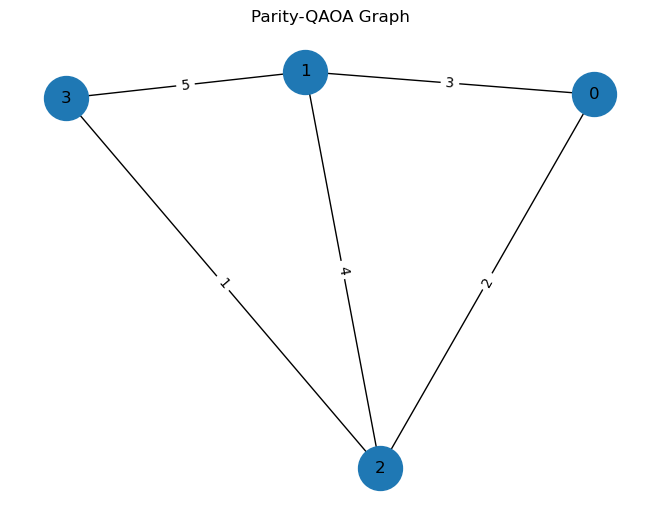


Parity Hamiltonian
SparsePauliOp(['IIZZ', 'IZIZ', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-1.5+0.j, -1. +0.j, -2. +0.j, -2.5+0.j, -0.5+0.j])

Constant Shift
7.5

Optimal Energy
-5.069562414775973

Top Solutions
0000 0.296469
1111 0.296469
0111 0.131354
1000 0.131354
0001 0.04868
1110 0.04868
0100 0.015224
1011 0.015224
0101 0.004783
1010 0.004783

Best Bitstring = 0000

Parity Variables
p(0,1) = 0
p(0,2) = 0
p(1,2) = 0
p(1,3) = 0
p(2,3) = 0

PARITY QAOA
Best Bitstring : 0000
Cut Value      : 0
Classical Cut  : 12
Approx Ratio   : 0.0

Gamma
[2.43916748 0.41920268]

Beta
[3.99254856 3.67692914]


In [17]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info import Statevector

# =====================================================
# GRAPH
# =====================================================

G = nx.Graph()

G.add_weighted_edges_from([
    (0,1,3),
    (0,2,2),
    (1,2,4),
    (1,3,5),
    (2,3,1)
])

n = G.number_of_nodes()

# =====================================================
# DRAW GRAPH
# =====================================================

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1000
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=nx.get_edge_attributes(
        G,
        "weight"
    )
)

plt.title("Parity-QAOA Graph")
plt.show()

# =====================================================
# PARITY HAMILTONIAN
#
# pij=(1-ZiZj)/2
#
# MaxCut:
#
# H = Σ wij (1-ZiZj)/2
# =====================================================

paulis = []
coeffs = []

constant_shift = 0

for i,j,w in G.edges(data="weight"):

    constant_shift += w/2

    label = ["I"] * n

    label[n-1-i] = "Z"
    label[n-1-j] = "Z"

    paulis.append(
        "".join(label)
    )

    coeffs.append(
        -w/2
    )

HC = SparsePauliOp(
    paulis,
    coeffs
).simplify()

print("\nParity Hamiltonian")
print(HC)

print("\nConstant Shift")
print(constant_shift)

# =====================================================
# QAOA DEPTH
# =====================================================

p = 2

# =====================================================
# BUILD CIRCUIT
# =====================================================

def build_circuit(gamma,beta):

    qc = QuantumCircuit(n)

    # Initial superposition

    for q in range(n):
        qc.h(q)

    for layer in range(p):

        # ---------------------------------
        # COST LAYER
        # ---------------------------------

        for i,j,w in G.edges(data="weight"):

            qc.rzz(
                -w * gamma[layer],
                i,
                j
            )

        # ---------------------------------
        # MIXER
        # ---------------------------------

        for q in range(n):

            qc.rx(
                2 * beta[layer],
                q
            )

    return qc

# =====================================================
# OBJECTIVE
# =====================================================

def objective(params):

    gamma = params[:p]

    beta = params[p:]

    circuit = build_circuit(
        gamma,
        beta
    )

    state = Statevector.from_instruction(
        circuit
    )

    energy = np.real(
        state.expectation_value(
            HC
        )
    )

    return energy

# =====================================================
# OPTIMIZATION
# =====================================================

initial = np.random.uniform(
    0,
    np.pi,
    2*p
)

result = minimize(
    objective,
    initial,
    method="COBYLA",
    options={
        "maxiter":500
    }
)

best = result.x

gamma_opt = best[:p]
beta_opt = best[p:]

print("\nOptimal Energy")
print(result.fun)

# =====================================================
# FINAL CIRCUIT
# =====================================================

final_circuit = build_circuit(
    gamma_opt,
    beta_opt
)

state = Statevector.from_instruction(
    final_circuit
)

probs = state.probabilities_dict()

sorted_probs = sorted(
    probs.items(),
    key=lambda x:x[1],
    reverse=True
)

print("\nTop Solutions")

for bitstring, prob in sorted_probs[:10]:

    print(
        bitstring,
        round(prob,6)
    )

best_bitstring = sorted_probs[0][0]

print("\nBest Bitstring =", best_bitstring)

# =====================================================
# PARITY VARIABLES
# =====================================================

print("\nParity Variables")

bits = [int(x) for x in best_bitstring[::-1]]

for i,j in G.edges():

    parity = bits[i] ^ bits[j]

    print(
        f"p({i},{j}) = {parity}"
    )

# =====================================================
# CUT VALUE
# =====================================================

def cut_value(bitstring,graph):

    bits = [int(x) for x in bitstring[::-1]]

    cut = 0

    for u,v,data in graph.edges(data=True):

        if bits[u] != bits[v]:

            cut += data["weight"]

    return cut

cut = cut_value(
    best_bitstring,
    G
)

# =====================================================
# CLASSICAL OPTIMUM
# =====================================================

best_classical = 0

for i in range(2**n):

    b = format(
        i,
        f"0{n}b"
    )

    best_classical = max(
        best_classical,
        cut_value(
            b,
            G
        )
    )

ratio = cut / best_classical

# =====================================================
# REPORT
# =====================================================

print("\n======================")
print("PARITY QAOA")
print("======================")
print("Best Bitstring :", best_bitstring)
print("Cut Value      :", cut)
print("Classical Cut  :", best_classical)
print("Approx Ratio   :", round(ratio,4))
print("======================")

print("\nGamma")
print(gamma_opt)

print("\nBeta")
print(beta_opt)

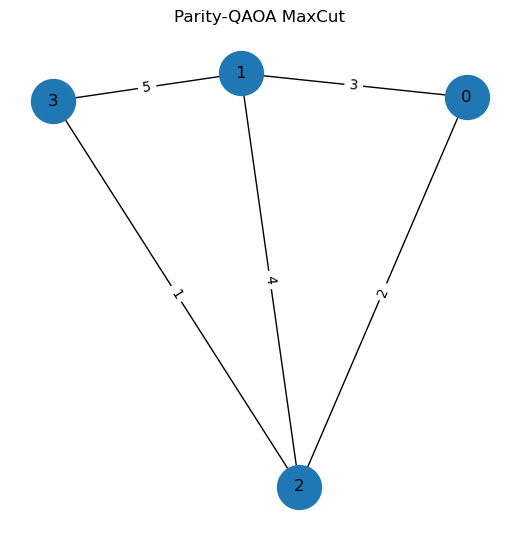


Parity Hamiltonian
SparsePauliOp(['IIZZ', 'IZIZ', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-1.5+0.j, -1. +0.j, -2. +0.j, -2.5+0.j, -0.5+0.j])

Constant Shift = 7.5

Optimization Complete

Top States
0010 0.495317
1101 0.495317
0100 0.002695
1011 0.002695
0111 0.000842
1000 0.000842
0110 0.000432
1001 0.000432
0011 0.000432
1100 0.000432
0101 0.000173
1010 0.000173
0001 0.0001
1110 0.0001
0000 9e-06

Parity Variables
p(0,1) = 1
p(0,2) = 0
p(1,2) = 1
p(1,3) = 1
p(2,3) = 0

PARITY QAOA RESULTS
Best Bitstring : 0010
Cut Value      : 12
Classical Cut  : 12
Approx Ratio   : 1.0

Gamma Parameters
[1.00197078 1.02952791 0.25227742 0.58741589 0.57416841]

Beta Parameters
[0.71338273 0.37369259 0.85107427 0.37482067 0.60612608]


In [18]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector

# ==========================================================
# GRAPH
# ==========================================================

G = nx.Graph()

G.add_weighted_edges_from([
    (0, 1, 3),
    (0, 2, 2),
    (1, 2, 4),
    (1, 3, 5),
    (2, 3, 1)
])

n = G.number_of_nodes()

# ==========================================================
# DRAW GRAPH
# ==========================================================

plt.figure(figsize=(5,5))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1000
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=nx.get_edge_attributes(
        G,
        "weight"
    )
)

plt.title("Parity-QAOA MaxCut")
plt.show()

# ==========================================================
# PARITY HAMILTONIAN
#
# H = Σ wij (1 - ZiZj)/2
#
# Constant term ignored during optimization
# ==========================================================

paulis = []
coeffs = []

constant_shift = 0

for i, j, w in G.edges(data="weight"):

    constant_shift += w / 2

    label = ["I"] * n

    label[n - 1 - i] = "Z"
    label[n - 1 - j] = "Z"

    paulis.append("".join(label))

    coeffs.append(-w / 2)

HC = SparsePauliOp(
    paulis,
    coeffs
).simplify()

print("\nParity Hamiltonian")
print(HC)

print("\nConstant Shift =", constant_shift)

# ==========================================================
# QAOA DEPTH
# ==========================================================

p = 5

# ==========================================================
# BUILD CIRCUIT
# ==========================================================

def build_circuit(gamma, beta):

    qc = QuantumCircuit(n)

    # Uniform superposition

    for q in range(n):
        qc.h(q)

    for layer in range(p):

        # -------------------------
        # Cost Layer
        # -------------------------

        for i, j, w in G.edges(data="weight"):

            qc.rzz(
                -w * gamma[layer],
                i,
                j
            )

        # -------------------------
        # Mixer Layer
        # -------------------------

        for q in range(n):

            qc.rx(
                2 * beta[layer],
                q
            )

    return qc

# ==========================================================
# CUT VALUE
# ==========================================================

def cut_value(bitstring, graph):

    bits = [int(b) for b in bitstring[::-1]]

    cut = 0

    for u, v, data in graph.edges(data=True):

        if bits[u] != bits[v]:

            cut += data["weight"]

    return cut

# ==========================================================
# OBJECTIVE FUNCTION
#
# IMPORTANT:
# maximize parity objective
# minimize negative energy
# ==========================================================

def objective(params):

    gamma = params[:p]
    beta = params[p:]

    qc = build_circuit(
        gamma,
        beta
    )

    state = Statevector.from_instruction(
        qc
    )

    energy = np.real(
        state.expectation_value(
            HC
        )
    )

    return -energy

# ==========================================================
# OPTIMIZATION
# ==========================================================

initial = np.concatenate([
    np.random.uniform(0.1, 1.0, p),
    np.random.uniform(0.1, 1.0, p)
])

result = minimize(
    objective,
    initial,
    method="COBYLA",
    options={
        "maxiter": 3000,
        "rhobeg": 0.5
    }
)

best_params = result.x

gamma_opt = best_params[:p]
beta_opt = best_params[p:]

print("\nOptimization Complete")

# ==========================================================
# FINAL CIRCUIT
# ==========================================================

final_circuit = build_circuit(
    gamma_opt,
    beta_opt
)

state = Statevector.from_instruction(
    final_circuit
)

probs = state.probabilities_dict()

sorted_probs = sorted(
    probs.items(),
    key=lambda x: x[1],
    reverse=True
)

# ==========================================================
# DISPLAY TOP STATES
# ==========================================================

print("\nTop States")

for bitstring, prob in sorted_probs[:15]:

    print(
        bitstring,
        round(prob, 6)
    )

# ==========================================================
# CHOOSE BEST CUT
#
# Not necessarily highest probability state
# ==========================================================

best_bitstring = None
best_cut = -1

for bitstring, prob in sorted_probs:

    cut = cut_value(
        bitstring,
        G
    )

    if cut > best_cut:

        best_cut = cut
        best_bitstring = bitstring

# ==========================================================
# PARITY VARIABLES
# ==========================================================

print("\nParity Variables")

bits = [int(x) for x in best_bitstring[::-1]]

for i, j in G.edges():

    parity = bits[i] ^ bits[j]

    print(
        f"p({i},{j}) = {parity}"
    )

# ==========================================================
# CLASSICAL OPTIMUM
# ==========================================================

best_classical = 0

for i in range(2**n):

    bitstring = format(
        i,
        f"0{n}b"
    )

    value = cut_value(
        bitstring,
        G
    )

    best_classical = max(
        best_classical,
        value
    )

# ==========================================================
# APPROXIMATION RATIO
# ==========================================================

ratio = best_cut / best_classical

# ==========================================================
# RESULTS
# ==========================================================

print("\n==============================")
print("PARITY QAOA RESULTS")
print("==============================")
print("Best Bitstring :", best_bitstring)
print("Cut Value      :", best_cut)
print("Classical Cut  :", best_classical)
print("Approx Ratio   :", round(ratio, 4))
print("==============================")

print("\nGamma Parameters")
print(gamma_opt)

print("\nBeta Parameters")
print(beta_opt)

In [ ]:
Hybrid ML-QAOA

In [20]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.quantum_info import SparsePauliOp

from sklearn.neural_network import MLPRegressor

# ==========================================================
# GRAPH
# ==========================================================

G = nx.Graph()

G.add_weighted_edges_from([
    (0,1,3),
    (0,2,2),
    (1,2,4),
    (1,3,5),
    (2,3,1)
])

n = G.number_of_nodes()

# ==========================================================
# COST HAMILTONIAN
# ==========================================================

paulis = []
coeffs = []

for i,j,w in G.edges(data="weight"):

    label = ["I"] * n

    label[n-1-i] = "Z"
    label[n-1-j] = "Z"

    paulis.append("".join(label))
    coeffs.append(float(w))

HC = SparsePauliOp(
    paulis,
    coeffs
).simplify()

# ==========================================================
# ML TRAINING DATA
# ==========================================================

X_train = np.array([
    [3,2,4,5,1],
    [1,1,1,1,1],
    [5,4,3,2,1],
    [2,3,1,4,5],
    [4,4,4,4,4]
])

Y_train = np.array([
    [0.8,0.9,0.7,1.0],
    [0.5,0.5,0.5,0.5],
    [1.2,1.0,0.8,0.6],
    [0.7,0.9,0.6,1.1],
    [1.0,1.0,1.0,1.0]
])

# ==========================================================
# NEURAL NETWORK
# ==========================================================

ml_model = MLPRegressor(
    hidden_layer_sizes=(32,32),
    max_iter=5000,
    random_state=42
)

ml_model.fit(
    X_train,
    Y_train
)

# ==========================================================
# GRAPH FEATURES
# ==========================================================

edge_features = np.array([
    [w for _,_,w in G.edges(data="weight")]
])

predicted_beta = ml_model.predict(
    edge_features
)[0]

print("\nPredicted Mixer Parameters")
print(predicted_beta)

# ==========================================================
# QAOA DEPTH
# ==========================================================

p = 2

# ==========================================================
# BUILD CIRCUIT
# ==========================================================

def build_circuit(gamma):

    qc = QuantumCircuit(n)

    for q in range(n):
        qc.h(q)

    for layer in range(p):

        # -----------------------------
        # COST LAYER
        # -----------------------------

        for i,j,w in G.edges(data="weight"):

            qc.rzz(
                2*w*gamma[layer],
                i,
                j
            )

        # -----------------------------
        # ML MIXER
        # -----------------------------

        for q in range(n):

            qc.rx(
                2*predicted_beta[q],
                q
            )

    return qc

# ==========================================================
# OBJECTIVE
# ==========================================================

def objective(params):

    gamma = params[:p]

    circuit = build_circuit(
        gamma
    )

    state = Statevector.from_instruction(
        circuit
    )

    energy = np.real(
        state.expectation_value(
            HC
        )
    )

    return energy

# ==========================================================
# OPTIMIZATION
# ==========================================================

initial = np.random.uniform(
    0,
    np.pi,
    p
)

result = minimize(
    objective,
    initial,
    method="COBYLA",
    options={"maxiter":1000}
)

gamma_opt = result.x

print("\nOptimal Energy")
print(result.fun)

# ==========================================================
# FINAL CIRCUIT
# ==========================================================

final_circuit = build_circuit(
    gamma_opt
)

state = Statevector.from_instruction(
    final_circuit
)

probs = state.probabilities_dict()

sorted_probs = sorted(
    probs.items(),
    key=lambda x:x[1],
    reverse=True
)

print("\nTop States")

for bitstring, prob in sorted_probs[:10]:

    print(
        bitstring,
        round(prob,6)
    )

best_bitstring = sorted_probs[0][0]

# ==========================================================
# CUT VALUE
# ==========================================================

def cut_value(bitstring,graph):

    bits = [int(x) for x in bitstring[::-1]]

    value = 0

    for u,v,data in graph.edges(data=True):

        if bits[u] != bits[v]:

            value += data["weight"]

    return value

qaoa_cut = cut_value(
    best_bitstring,
    G
)

# ==========================================================
# CLASSICAL OPTIMUM
# ==========================================================

best_classical = 0

for i in range(2**n):

    b = format(
        i,
        f"0{n}b"
    )

    best_classical = max(
        best_classical,
        cut_value(b,G)
    )

ratio = qaoa_cut / best_classical

# ==========================================================
# REPORT
# ==========================================================

print("\n==========================")
print("HYBRID ML-QAOA")
print("==========================")
print("Best Bitstring :", best_bitstring)
print("QAOA Cut       :", qaoa_cut)
print("Classical Cut  :", best_classical)
print("Approx Ratio   :", round(ratio,4))
print("==========================")

print("\nLearned Mixer Parameters")
print(predicted_beta)

print("\nOptimized Gamma")
print(gamma_opt)


Predicted Mixer Parameters
[0.78683749 0.89372141 0.71857934 0.97734772]

Optimal Energy
-3.560172088087099

Top States
0011 0.176879
1100 0.176879
0110 0.124106
1001 0.124106
0100 0.079647
1011 0.079647
0111 0.07745
1000 0.07745
0001 0.015974
1110 0.015974

HYBRID ML-QAOA
Best Bitstring : 0011
QAOA Cut       : 11
Classical Cut  : 12
Approx Ratio   : 0.9167

Learned Mixer Parameters
[0.78683749 0.89372141 0.71857934 0.97734772]

Optimized Gamma
[1.77153026 2.48705571]


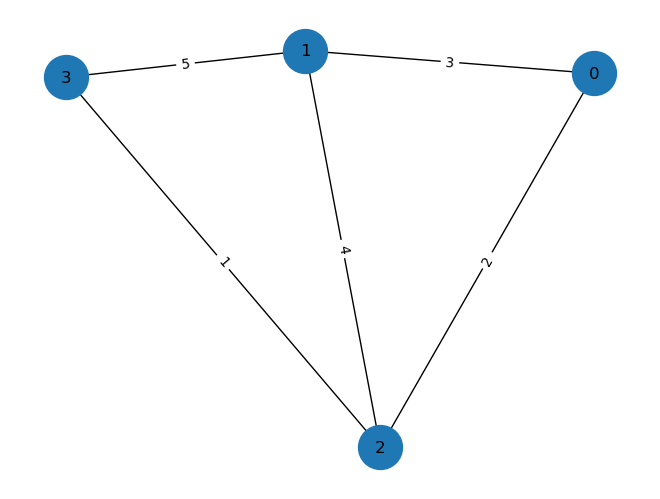


Custom Hamiltonian
SparsePauliOp(['IIZZ', 'IZIZ', 'IZZI', 'ZIZI', 'ZZII', 'IIXX', 'IXIX', 'IXXI', 'XIXI', 'XXII', 'IIYY', 'IYIY', 'IYYI', 'YIYI', 'YYII', 'IIIZ', 'IIZI', 'IZII', 'ZIII'],
              coeffs=[3.  +0.j, 2.  +0.j, 4.  +0.j, 5.  +0.j, 1.  +0.j, 0.8 +0.j, 0.8 +0.j,
 0.8 +0.j, 0.8 +0.j, 0.8 +0.j, 0.8 +0.j, 0.8 +0.j, 0.8 +0.j, 0.8 +0.j,
 0.8 +0.j, 0.5 +0.j, 1.  +0.j, 0.75+0.j, 0.25+0.j])

Optimal Energy
-5.701412148836

Top Solutions
0110 0.194496
1101 0.168493
0011 0.124012
1100 0.109135
0010 0.105084
0100 0.090324
1001 0.05726
1010 0.041421
1110 0.038962
0111 0.030835
0101 0.009196
0001 0.007733
1000 0.006976
1011 0.006667
0000 0.006026

Best Bitstring = 0110

ADAPTIVE MULTI-WEIGHTED
HEISENBERG QAOA
Nodes          : 4
Depth          : 3
Best State     : 0110
Energy         : -5.701412148836

Gamma
[2.93087557 2.651401   0.44681983]

Beta
[3.59652037 1.39104444 3.03378997]


In [21]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info import Statevector

# =====================================================
# GRAPH
# =====================================================

G = nx.Graph()

G.add_weighted_edges_from([
    (0,1,3),
    (0,2,2),
    (1,2,4),
    (1,3,5),
    (2,3,1)
])

n = G.number_of_nodes()

# =====================================================
# NODE BIASES
# =====================================================

v = {
    0: 1.0,
    1: 2.0,
    2: 1.5,
    3: 0.5
}

# =====================================================
# MODEL PARAMETERS
# =====================================================

alpha = 1.0
beta_h = 0.8
gamma_h = 0.8
delta = 0.5

eta = 1.0
kappa = 0.7

# =====================================================
# DRAW GRAPH
# =====================================================

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1000
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=nx.get_edge_attributes(
        G,
        "weight"
    )
)

plt.show()

# =====================================================
# BUILD COST HAMILTONIAN
# =====================================================

paulis = []
coeffs = []

# ------------------------
# ZZ term
# ------------------------

for i,j,w in G.edges(data="weight"):

    label = ["I"] * n

    label[n-1-i] = "Z"
    label[n-1-j] = "Z"

    paulis.append(
        "".join(label)
    )

    coeffs.append(
        alpha * float(w)
    )

# ------------------------
# XX term
# ------------------------

for i,j,w in G.edges(data="weight"):

    label = ["I"] * n

    label[n-1-i] = "X"
    label[n-1-j] = "X"

    paulis.append(
        "".join(label)
    )

    coeffs.append(
        beta_h
    )

# ------------------------
# YY term
# ------------------------

for i,j,w in G.edges(data="weight"):

    label = ["I"] * n

    label[n-1-i] = "Y"
    label[n-1-j] = "Y"

    paulis.append(
        "".join(label)
    )

    coeffs.append(
        gamma_h
    )

# ------------------------
# Local Z bias
# ------------------------

for i in range(n):

    label = ["I"] * n

    label[n-1-i] = "Z"

    paulis.append(
        "".join(label)
    )

    coeffs.append(
        delta * v[i]
    )

HC = SparsePauliOp(
    paulis,
    coeffs
).simplify()

print("\nCustom Hamiltonian")
print(HC)

# =====================================================
# DEPTH
# =====================================================

p = 3

# =====================================================
# CIRCUIT
# =====================================================

def build_circuit(gamma,beta):

    qc = QuantumCircuit(n)

    for q in range(n):
        qc.h(q)

    for layer in range(p):

        # ==================================
        # COST LAYER
        # ==================================

        for i,j,w in G.edges(data="weight"):

            qc.rzz(
                2*alpha*w*gamma[layer],
                i,
                j
            )

            qc.rxx(
                2*beta_h*gamma[layer],
                i,
                j
            )

            qc.ryy(
                2*gamma_h*gamma[layer],
                i,
                j
            )

        for i in range(n):

            qc.rz(
                2*delta*v[i]*gamma[layer],
                i
            )

        # ==================================
        # MIXER
        # ==================================

        for q in range(n):

            qc.rx(
                2*eta*beta[layer],
                q
            )

        for i,j in G.edges():

            qc.rxx(
                2*kappa*beta[layer],
                i,
                j
            )

            qc.ryy(
                2*kappa*beta[layer],
                i,
                j
            )

    return qc

# =====================================================
# OBJECTIVE
# =====================================================

def objective(params):

    gamma = params[:p]

    beta = params[p:]

    qc = build_circuit(
        gamma,
        beta
    )

    state = Statevector.from_instruction(
        qc
    )

    energy = np.real(
        state.expectation_value(
            HC
        )
    )

    return energy

# =====================================================
# OPTIMIZATION
# =====================================================

initial = np.random.uniform(
    0,
    np.pi,
    2*p
)

result = minimize(
    objective,
    initial,
    method="COBYLA",
    options={
        "maxiter":2000
    }
)

best = result.x

gamma_opt = best[:p]
beta_opt = best[p:]

print("\nOptimal Energy")
print(result.fun)

# =====================================================
# FINAL STATE
# =====================================================

final_circuit = build_circuit(
    gamma_opt,
    beta_opt
)

state = Statevector.from_instruction(
    final_circuit
)

probs = state.probabilities_dict()

sorted_probs = sorted(
    probs.items(),
    key=lambda x:x[1],
    reverse=True
)

print("\nTop Solutions")

for bitstring, prob in sorted_probs[:15]:

    print(
        bitstring,
        round(prob,6)
    )

best_bitstring = sorted_probs[0][0]

print("\nBest Bitstring =", best_bitstring)

# =====================================================
# REPORT
# =====================================================

print("\n==============================")
print("ADAPTIVE MULTI-WEIGHTED")
print("HEISENBERG QAOA")
print("==============================")
print("Nodes          :", n)
print("Depth          :", p)
print("Best State     :", best_bitstring)
print("Energy         :", result.fun)
print("==============================")

print("\nGamma")
print(gamma_opt)

print("\nBeta")
print(beta_opt)

In [ ]:
general QAOA ansatz

In [22]:
import numpy as np

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

# ============================================
# PARAMETERS
# ============================================

n = 4          # qubits
P = 3          # QAOA depth

gamma = ParameterVector("γ", P)
beta  = ParameterVector("β", P)

# ============================================
# INITIAL STATE |s>
# ============================================

qc = QuantumCircuit(n)

for q in range(n):
    qc.h(q)

# ============================================
# GENERAL QAOA ANSATZ
# ============================================

for p in range(P):

    # --------------------------------
    # COST UNITARY
    # Uc = exp(-i γp Hc)
    # Example:
    # Hc = Z0Z1 + Z1Z2 + Z2Z3
    # --------------------------------

    qc.rzz(2 * gamma[p], 0, 1)
    qc.rzz(2 * gamma[p], 1, 2)
    qc.rzz(2 * gamma[p], 2, 3)

    # --------------------------------
    # MIXER UNITARY
    # Um = exp(-i βp Hm)
    # Hm = Σ Xi
    # --------------------------------

    for q in range(n):

        qc.rx(
            2 * beta[p],
            q
        )

# ============================================
# DRAW CIRCUIT
# ============================================

print(qc.draw("text"))

     ┌───┐             ┌────────────┐                            ┌────────────┐»
q_0: ┤ H ├─■───────────┤ Rx(2*β[0]) ├───────────────■────────────┤ Rx(2*β[1]) ├»
     ├───┤ │ZZ(2*γ[0]) └────────────┘┌────────────┐ │ZZ(2*γ[1])  └────────────┘»
q_1: ┤ H ├─■────────────■────────────┤ Rx(2*β[0]) ├─■─────────────■────────────»
     ├───┤              │ZZ(2*γ[0])  └────────────┘┌────────────┐ │ZZ(2*γ[1])  »
q_2: ┤ H ├──────────────■─────────────■────────────┤ Rx(2*β[0]) ├─■────────────»
     ├───┤                            │ZZ(2*γ[0])  ├────────────┤              »
q_3: ┤ H ├────────────────────────────■────────────┤ Rx(2*β[0]) ├──────────────»
     └───┘                                         └────────────┘              »
«                                 ┌────────────┐                            
«q_0: ───────────────■────────────┤ Rx(2*β[2]) ├────────────────────────────
«     ┌────────────┐ │ZZ(2*γ[2])  └────────────┘┌────────────┐              
«q_1: ┤ Rx(2*β[1]) ├─■─────────────■────

In [23]:
import networkx as nx
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

# Graph
G = nx.Graph()

G.add_weighted_edges_from([
    (0,1,3),
    (0,2,2),
    (1,2,4),
    (1,3,5)
])

n = G.number_of_nodes()

P = 3

gamma = ParameterVector("γ", P)
beta  = ParameterVector("β", P)

qc = QuantumCircuit(n)

# |s>
for q in range(n):
    qc.h(q)

# QAOA Layers
for p in range(P):

    # Cost Hamiltonian
    for i,j,w in G.edges(data="weight"):

        qc.rzz(
            2*w*gamma[p],
            i,
            j
        )

    # Mixer Hamiltonian
    for q in range(n):

        qc.rx(
            2*beta[p],
            q
        )

print(qc.draw())

     ┌───┐                          ┌────────────┐                            »
q_0: ┤ H ├─■────────────■───────────┤ Rx(2*β[0]) ├────────────────────────────»
     ├───┤ │ZZ(6*γ[0])  │           └────────────┘              ┌────────────┐»
q_1: ┤ H ├─■────────────┼────────────■─────────────■────────────┤ Rx(2*β[0]) ├»
     ├───┤              │ZZ(4*γ[0])  │ZZ(8*γ[0])   │            ├────────────┤»
q_2: ┤ H ├──────────────■────────────■─────────────┼────────────┤ Rx(2*β[0]) ├»
     ├───┤                                         │ZZ(10*γ[0]) ├────────────┤»
q_3: ┤ H ├─────────────────────────────────────────■────────────┤ Rx(2*β[0]) ├»
     └───┘                                                      └────────────┘»
«                               ┌────────────┐                            »
«q_0: ─■────────────■───────────┤ Rx(2*β[1]) ├────────────────────────────»
«      │ZZ(6*γ[1])  │           └────────────┘              ┌────────────┐»
«q_1: ─■────────────┼────────────■─────────────■────

In [ ]:
Ising QAOA

In [25]:
import numpy as np
from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector

# =====================================================
# PARAMETERS
# =====================================================

n = 4

# Coupling matrix Jij
J = np.array([
    [0, 3, 2, 0],
    [3, 0, 4, 5],
    [2, 4, 0, 1],
    [0, 5, 1, 0]
])

# Local fields hi
h = np.array([
    1.0,
    -0.5,
    0.8,
    -1.2
])

# QAOA depth
p = 2

# =====================================================
# BUILD ISING HAMILTONIAN
# =====================================================

paulis = []
coeffs = []

# ZZ terms

for i in range(n):

    for j in range(i + 1, n):

        if J[i, j] != 0:

            label = ["I"] * n

            label[n - 1 - i] = "Z"
            label[n - 1 - j] = "Z"

            paulis.append("".join(label))
            coeffs.append(float(J[i, j]))

# Local field terms

for i in range(n):

    label = ["I"] * n

    label[n - 1 - i] = "Z"

    paulis.append("".join(label))
    coeffs.append(float(h[i]))

HC = SparsePauliOp(
    paulis,
    coeffs
).simplify()

print("\nIsing Hamiltonian")
print(HC)

# =====================================================
# QAOA CIRCUIT
# =====================================================

def build_circuit(gamma, beta):

    qc = QuantumCircuit(n)

    # Initial state |+>
    for q in range(n):
        qc.h(q)

    for layer in range(p):

        # --------------------------
        # ZZ interactions
        # --------------------------

        for i in range(n):

            for j in range(i + 1, n):

                if J[i, j] != 0:

                    qc.rzz(
                        2 * J[i, j] * gamma[layer],
                        i,
                        j
                    )

        # --------------------------
        # Local fields
        # --------------------------

        for i in range(n):

            qc.rz(
                2 * h[i] * gamma[layer],
                i
            )

        # --------------------------
        # Mixer
        # --------------------------

        for q in range(n):

            qc.rx(
                2 * beta[layer],
                q
            )

    return qc

# =====================================================
# OBJECTIVE FUNCTION
# =====================================================

def objective(params):

    gamma = params[:p]
    beta = params[p:]

    qc = build_circuit(
        gamma,
        beta
    )

    state = Statevector.from_instruction(qc)

    energy = np.real(
        state.expectation_value(HC)
    )

    return energy

# =====================================================
# OPTIMIZATION
# =====================================================

initial = np.random.uniform(
    0,
    np.pi,
    2 * p
)

result = minimize(
    objective,
    initial,
    method="COBYLA",
    options={"maxiter":1000}
)

best = result.x

gamma_opt = best[:p]
beta_opt = best[p:]

print("\nOptimal Energy")
print(result.fun)

# =====================================================
# FINAL STATE
# =====================================================

final_circuit = build_circuit(
    gamma_opt,
    beta_opt
)

state = Statevector.from_instruction(
    final_circuit
)

probs = state.probabilities_dict()

sorted_probs = sorted(
    probs.items(),
    key=lambda x: x[1],
    reverse=True
)

print("\nTop States")

for bitstring, prob in sorted_probs[:10]:

    print(
        bitstring,
        round(prob, 6)
    )

best_bitstring = sorted_probs[0][0]

print("\nBest State =", best_bitstring)

# =====================================================
# CLASSICAL ENERGY
# =====================================================

def ising_energy(bitstring):

    spins = []

    for b in bitstring[::-1]:

        if b == "0":
            spins.append(+1)
        else:
            spins.append(-1)

    E = 0

    for i in range(n):

        E += h[i] * spins[i]

    for i in range(n):

        for j in range(i + 1, n):

            E += J[i, j] * spins[i] * spins[j]

    return E

best_classical_energy = 1e9
best_classical_state = None

for k in range(2**n):

    b = format(k, f"0{n}b")

    E = ising_energy(b)

    if E < best_classical_energy:

        best_classical_energy = E
        best_classical_state = b

# =====================================================
# REPORT
# =====================================================

print("\n==========================")
print("ISING QAOA RESULTS")
print("==========================")
print("Best QAOA State      :", best_bitstring)
print("Ground Energy        :", result.fun)
print("Classical Ground     :", best_classical_energy)
print("Classical State      :", best_classical_state)
print("==========================")


Ising Hamiltonian
SparsePauliOp(['IIZZ', 'IZIZ', 'IZZI', 'ZIZI', 'ZZII', 'IIIZ', 'IIZI', 'IZII', 'ZIII'],
              coeffs=[ 3. +0.j,  2. +0.j,  4. +0.j,  5. +0.j,  1. +0.j,  1. +0.j, -0.5+0.j,
  0.8+0.j, -1.2+0.j])

Optimal Energy
-3.9415377153659987

Top States
1100 0.302746
0011 0.134244
1001 0.109294
1011 0.075056
1101 0.074472
1110 0.058257
0100 0.055168
1010 0.038778
0010 0.031465
0110 0.030497

Best State = 1100

ISING QAOA RESULTS
Best QAOA State      : 1100
Ground Energy        : -3.9415377153659987
Classical Ground     : -10.1
Classical State      : 1101


In [28]:
import numpy as np
from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info import Statevector

# =====================================================
# SYSTEM SIZE
# =====================================================

n = 4
p = 2

# =====================================================
# 2-BODY COUPLINGS
# Jij
# =====================================================

J = {
    (0,1): 3,
    (0,2): 2,
    (1,2): 4,
    (1,3): 5
}

# =====================================================
# 3-BODY COUPLINGS
# Kijk
# =====================================================

K = {
    (0,1,2): 2.5,
    (1,2,3): 1.5
}

# =====================================================
# BUILD HAMILTONIAN
# =====================================================

paulis = []
coeffs = []

# -------------------
# ZZ terms
# -------------------

for (i,j), val in J.items():

    label = ["I"] * n

    label[n-1-i] = "Z"
    label[n-1-j] = "Z"

    paulis.append(
        "".join(label)
    )

    coeffs.append(val)

# -------------------
# ZZZ terms
# -------------------

for (i,j,k), val in K.items():

    label = ["I"] * n

    label[n-1-i] = "Z"
    label[n-1-j] = "Z"
    label[n-1-k] = "Z"

    paulis.append(
        "".join(label)
    )

    coeffs.append(val)

HC = SparsePauliOp(
    paulis,
    coeffs
).simplify()

print("\nHigher Order Hamiltonian")
print(HC)

# =====================================================
# COST LAYER
# =====================================================

def apply_three_body(qc, theta, q1, q2, q3):

    qc.cx(q1, q3)
    qc.cx(q2, q3)

    qc.rz(
        2*theta,
        q3
    )

    qc.cx(q2, q3)
    qc.cx(q1, q3)

# =====================================================
# QAOA CIRCUIT
# =====================================================

def build_circuit(gamma,beta):

    qc = QuantumCircuit(n)

    # Initial state

    for q in range(n):
        qc.h(q)

    for layer in range(p):

        # -------------------------
        # 2-body terms
        # -------------------------

        for (i,j), val in J.items():

            qc.rzz(
                2*val*gamma[layer],
                i,
                j
            )

        # -------------------------
        # 3-body terms
        # -------------------------

        for (i,j,k), val in K.items():

            apply_three_body(
                qc,
                val*gamma[layer],
                i,
                j,
                k
            )

        # -------------------------
        # Mixer
        # -------------------------

        for q in range(n):

            qc.rx(
                2*beta[layer],
                q
            )

    return qc

# =====================================================
# OBJECTIVE
# =====================================================

def objective(params):

    gamma = params[:p]
    beta = params[p:]

    qc = build_circuit(
        gamma,
        beta
    )

    state = Statevector.from_instruction(
        qc
    )

    energy = np.real(
        state.expectation_value(
            HC
        )
    )

    return energy

# =====================================================
# OPTIMIZATION
# =====================================================

initial = np.random.uniform(
    0,
    np.pi,
    2*p
)

result = minimize(
    objective,
    initial,
    method="COBYLA",
    options={
        "maxiter":1000
    }
)

best = result.x

gamma_opt = best[:p]
beta_opt = best[p:]

print("\nOptimal Energy")
print(result.fun)

# =====================================================
# FINAL STATE
# =====================================================

final_circuit = build_circuit(
    gamma_opt,
    beta_opt
)

state = Statevector.from_instruction(
    final_circuit
)

probs = state.probabilities_dict()

sorted_probs = sorted(
    probs.items(),
    key=lambda x:x[1],
    reverse=True
)

print("\nTop States")

for bitstring, prob in sorted_probs[:10]:

    print(
        bitstring,
        round(prob,6)
    )

best_bitstring = sorted_probs[0][0]

# =====================================================
# CLASSICAL SOLVER
# =====================================================

def classical_energy(bitstring):

    spins = []

    for b in bitstring[::-1]:

        if b == "0":
            spins.append(+1)
        else:
            spins.append(-1)

    E = 0

    for (i,j), val in J.items():

        E += val * spins[i] * spins[j]

    for (i,j,k), val in K.items():

        E += (
            val
            * spins[i]
            * spins[j]
            * spins[k]
        )

    return E

best_classical_energy = 1e9
best_classical_state = None

for i in range(2**n):

    b = format(
        i,
        f"0{n}b"
    )

    E = classical_energy(b)

    if E < best_classical_energy:

        best_classical_energy = E
        best_classical_state = b

# =====================================================
# REPORT
# =====================================================

print("\n========================")
print("HIGHER ORDER QAOA")
print("========================")
print("Best QAOA State :", best_bitstring)
print("QAOA Energy     :", result.fun)
print("Classical State :", best_classical_state)
print("Classical Energy:", best_classical_energy)
print("========================")


Higher Order Hamiltonian
SparsePauliOp(['IIZZ', 'IZIZ', 'IZZI', 'ZIZI', 'IZZZ', 'ZZZI'],
              coeffs=[3. +0.j, 2. +0.j, 4. +0.j, 5. +0.j, 2.5+0.j, 1.5+0.j])

Optimal Energy
-4.803966330791614

Top States
1100 0.164541
0011 0.164515
1001 0.116189
0010 0.11329
1000 0.104367
0111 0.081117
0100 0.062019
1010 0.050807
1101 0.042169
0110 0.03942

HIGHER ORDER QAOA
Best QAOA State : 1100
QAOA Energy     : -4.803966330791614
Classical State : 0010
Classical Energy: -14.0


In [ ]:
Tensor-QAOA

In [29]:
import numpy as np
from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info import Statevector

# =====================================================
# PARAMETERS
# =====================================================

n = 5
p = 2

# =====================================================
# TENSOR COEFFICIENTS
#
# Tijkl
# =====================================================

tensor_terms = {
    (0,1,2,3): 3.0,
    (1,2,3,4): 2.5,
    (0,2,3,4): 1.8
}

# =====================================================
# BUILD TENSOR HAMILTONIAN
# =====================================================

paulis = []
coeffs = []

for (i,j,k,l), value in tensor_terms.items():

    label = ["I"] * n

    label[n-1-i] = "Z"
    label[n-1-j] = "Z"
    label[n-1-k] = "Z"
    label[n-1-l] = "Z"

    paulis.append(
        "".join(label)
    )

    coeffs.append(value)

HC = SparsePauliOp(
    paulis,
    coeffs
).simplify()

print("\nTensor Hamiltonian")
print(HC)

# =====================================================
# 4-BODY PHASE GATE
#
# exp(-i θ ZiZjZkZl)
# =====================================================

def apply_four_body(
    qc,
    theta,
    q1,
    q2,
    q3,
    q4
):

    qc.cx(q1, q4)
    qc.cx(q2, q4)
    qc.cx(q3, q4)

    qc.rz(
        2 * theta,
        q4
    )

    qc.cx(q3, q4)
    qc.cx(q2, q4)
    qc.cx(q1, q4)

# =====================================================
# BUILD QAOA CIRCUIT
# =====================================================

def build_circuit(gamma, beta):

    qc = QuantumCircuit(n)

    # Initial State |+>

    for q in range(n):
        qc.h(q)

    for layer in range(p):

        # ---------------------------------
        # COST LAYER
        # ---------------------------------

        for (i,j,k,l), value in tensor_terms.items():

            apply_four_body(
                qc,
                value * gamma[layer],
                i,
                j,
                k,
                l
            )

        # ---------------------------------
        # MIXER
        # ---------------------------------

        for q in range(n):

            qc.rx(
                2 * beta[layer],
                q
            )

    return qc

# =====================================================
# OBJECTIVE FUNCTION
# =====================================================

def objective(params):

    gamma = params[:p]
    beta = params[p:]

    circuit = build_circuit(
        gamma,
        beta
    )

    state = Statevector.from_instruction(
        circuit
    )

    energy = np.real(
        state.expectation_value(
            HC
        )
    )

    return energy

# =====================================================
# OPTIMIZATION
# =====================================================

initial = np.random.uniform(
    0,
    np.pi,
    2 * p
)

result = minimize(
    objective,
    initial,
    method="COBYLA",
    options={
        "maxiter":1000
    }
)

best = result.x

gamma_opt = best[:p]
beta_opt = best[p:]

print("\nOptimal Energy")
print(result.fun)

# =====================================================
# FINAL STATE
# =====================================================

final_circuit = build_circuit(
    gamma_opt,
    beta_opt
)

state = Statevector.from_instruction(
    final_circuit
)

probs = state.probabilities_dict()

sorted_probs = sorted(
    probs.items(),
    key=lambda x: x[1],
    reverse=True
)

print("\nTop States")

for bitstring, prob in sorted_probs[:10]:

    print(
        bitstring,
        round(prob,6)
    )

best_bitstring = sorted_probs[0][0]

# =====================================================
# CLASSICAL ENERGY
# =====================================================

def tensor_energy(bitstring):

    spins = []

    for b in bitstring[::-1]:

        if b == "0":
            spins.append(+1)
        else:
            spins.append(-1)

    E = 0

    for (i,j,k,l), value in tensor_terms.items():

        E += (
            value
            * spins[i]
            * spins[j]
            * spins[k]
            * spins[l]
        )

    return E

best_classical_energy = 1e9
best_classical_state = None

for i in range(2**n):

    b = format(
        i,
        f"0{n}b"
    )

    E = tensor_energy(b)

    if E < best_classical_energy:

        best_classical_energy = E
        best_classical_state = b

# =====================================================
# REPORT
# =====================================================

print("\n=========================")
print("TENSOR QAOA")
print("=========================")
print("Best State       :", best_bitstring)
print("QAOA Energy      :", result.fun)
print("Classical State  :", best_classical_state)
print("Classical Energy :", best_classical_energy)
print("=========================")

print("\nGamma Parameters")
print(gamma_opt)

print("\nBeta Parameters")
print(beta_opt)


Tensor Hamiltonian
SparsePauliOp(['IZZZZ', 'ZZZZI', 'ZZZIZ'],
              coeffs=[3. +0.j, 2.5+0.j, 1.8+0.j])

Optimal Energy
-3.3476034939045602

Top States
00010 0.11373
01110 0.11373
10001 0.11373
11101 0.11373
00100 0.068982
01000 0.068982
10111 0.068982
11011 0.068982
00111 0.030104
01011 0.030104

TENSOR QAOA
Best State       : 00010
QAOA Energy      : -3.3476034939045602
Classical State  : 00100
Classical Energy : -7.3

Gamma Parameters
[1.58855691 0.17437262]

Beta Parameters
[0.99150959 1.00041358]


In [ ]:
Multi-Objective QAOA (MO-QAOA)

In [30]:
import numpy as np
from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info import Statevector

# =====================================================
# EV CHARGING DATA
# =====================================================

n = 4
p = 2

# Charging cost ($)
cost = np.array([
    12,
    18,
    10,
    15
])

# Energy delivered (kWh)
energy = np.array([
    30,
    40,
    25,
    35
])

# Charging time (minutes)
time = np.array([
    60,
    90,
    45,
    75
])

# =====================================================
# OBJECTIVE WEIGHTS
# =====================================================

alpha = 1.0   # cost
beta  = 0.8   # energy
gamma = 0.5   # time

# =====================================================
# BUILD MULTI-OBJECTIVE HAMILTONIAN
# =====================================================

paulis = []
coeffs = []

for i in range(n):

    # Zi term

    label = ["I"] * n
    label[n-1-i] = "Z"

    paulis.append("".join(label))

    # Multi-objective coefficient

    coeff = (
        alpha * cost[i]
        - beta * energy[i]
        + gamma * time[i]
    )

    coeffs.append(coeff)

HC = SparsePauliOp(
    paulis,
    coeffs
).simplify()

print("\nMulti-Objective Hamiltonian")
print(HC)

# =====================================================
# BUILD QAOA CIRCUIT
# =====================================================

def build_circuit(gamma_qaoa, beta_qaoa):

    qc = QuantumCircuit(n)

    # Initial superposition

    for q in range(n):
        qc.h(q)

    for layer in range(p):

        # -------------------------
        # COST LAYER
        # -------------------------

        for i in range(n):

            coeff = (
                alpha * cost[i]
                - beta * energy[i]
                + gamma * time[i]
            )

            qc.rz(
                2 * coeff * gamma_qaoa[layer],
                i
            )

        # -------------------------
        # MIXER
        # -------------------------

        for q in range(n):

            qc.rx(
                2 * beta_qaoa[layer],
                q
            )

    return qc

# =====================================================
# OBJECTIVE FUNCTION
# =====================================================

def objective(params):

    gamma_qaoa = params[:p]
    beta_qaoa = params[p:]

    qc = build_circuit(
        gamma_qaoa,
        beta_qaoa
    )

    state = Statevector.from_instruction(
        qc
    )

    value = np.real(
        state.expectation_value(
            HC
        )
    )

    return value

# =====================================================
# OPTIMIZATION
# =====================================================

initial = np.random.uniform(
    0,
    np.pi,
    2*p
)

result = minimize(
    objective,
    initial,
    method="COBYLA",
    options={"maxiter":1000}
)

best = result.x

gamma_opt = best[:p]
beta_opt = best[p:]

print("\nOptimal Objective")
print(result.fun)

# =====================================================
# FINAL STATE
# =====================================================

final_circuit = build_circuit(
    gamma_opt,
    beta_opt
)

state = Statevector.from_instruction(
    final_circuit
)

probs = state.probabilities_dict()

sorted_probs = sorted(
    probs.items(),
    key=lambda x:x[1],
    reverse=True
)

print("\nTop Solutions")

for bitstring, prob in sorted_probs[:10]:

    print(
        bitstring,
        round(prob,6)
    )

best_bitstring = sorted_probs[0][0]

# =====================================================
# EVALUATE SOLUTION
# =====================================================

selected = []

total_cost = 0
total_energy = 0
total_time = 0

for i, bit in enumerate(best_bitstring[::-1]):

    if bit == "1":

        selected.append(i)

        total_cost += cost[i]
        total_energy += energy[i]
        total_time += time[i]

# =====================================================
# REPORT
# =====================================================

print("\n=========================")
print("MULTI OBJECTIVE QAOA")
print("=========================")
print("Best Bitstring :", best_bitstring)
print("Selected EVs   :", selected)
print("Total Cost     :", total_cost)
print("Total Energy   :", total_energy)
print("Total Time     :", total_time)
print("=========================")

print("\nGamma")
print(gamma_opt)

print("\nBeta")
print(beta_opt)


Multi-Objective Hamiltonian
SparsePauliOp(['IIIZ', 'IIZI', 'IZII', 'ZIII'],
              coeffs=[18. +0.j, 31. +0.j, 12.5+0.j, 24.5+0.j])

Optimal Objective
-72.80376139404967

Top Solutions
1111 0.651312
1110 0.139885
1011 0.139355
1010 0.02993
1101 0.02521
1100 0.005414
1001 0.005394
0111 0.001529
1000 0.001158
0110 0.000328

MULTI OBJECTIVE QAOA
Best Bitstring : 1111
Selected EVs   : [0, 1, 2, 3]
Total Cost     : 55
Total Energy   : 130
Total Time     : 270

Gamma
[1.05342599 0.84074253]

Beta
[2.59706262 0.30450259]


In [31]:
import numpy as np
import networkx as nx

from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info import Statevector

# =====================================================
# GRAPH (MAX-CUT)
# =====================================================

G = nx.Graph()

G.add_weighted_edges_from([
    (0,1,3),
    (0,2,2),
    (1,2,4),
    (1,3,5),
    (2,3,1)
])

n = G.number_of_nodes()

# =====================================================
# COST HAMILTONIAN
#
# Hc = Σ wij ZiZj
# =====================================================

paulis = []
coeffs = []

for i, j, w in G.edges(data="weight"):

    label = ["I"] * n

    label[n-1-i] = "Z"
    label[n-1-j] = "Z"

    paulis.append("".join(label))
    coeffs.append(float(w))

HC = SparsePauliOp(
    paulis,
    coeffs
).simplify()

# =====================================================
# QAOA DEPTH
# =====================================================

p = 2

# =====================================================
# BUILD CIRCUIT
# =====================================================

def build_qaoa(gamma, beta):

    qc = QuantumCircuit(n)

    # Initial state |+>

    for q in range(n):
        qc.h(q)

    for layer in range(p):

        # ----------------------------------
        # COST LAYER
        # ----------------------------------

        for i, j, w in G.edges(data="weight"):

            qc.rzz(
                2*w*gamma[layer],
                i,
                j
            )

        # ----------------------------------
        # X MIXER
        #
        # HM = Σ Xi
        # ----------------------------------

        for q in range(n):

            qc.rx(
                2*beta[layer],
                q
            )

    return qc

# =====================================================
# OBJECTIVE FUNCTION
# =====================================================

def objective(params):

    gamma = params[:p]
    beta = params[p:]

    circuit = build_qaoa(
        gamma,
        beta
    )

    state = Statevector.from_instruction(
        circuit
    )

    energy = np.real(
        state.expectation_value(
            HC
        )
    )

    return energy

# =====================================================
# OPTIMIZATION
# =====================================================

initial = np.random.uniform(
    0,
    np.pi,
    2*p
)

result = minimize(
    objective,
    initial,
    method="COBYLA",
    options={"maxiter":1000}
)

best = result.x

gamma_opt = best[:p]
beta_opt = best[p:]

print("\nOptimal Energy")
print(result.fun)

# =====================================================
# FINAL CIRCUIT
# =====================================================

final_circuit = build_qaoa(
    gamma_opt,
    beta_opt
)

print("\nQAOA Circuit")
print(final_circuit.draw())

# =====================================================
# STATEVECTOR
# =====================================================

state = Statevector.from_instruction(
    final_circuit
)

probs = state.probabilities_dict()

sorted_probs = sorted(
    probs.items(),
    key=lambda x: x[1],
    reverse=True
)

print("\nTop Bitstrings")

for bitstring, prob in sorted_probs[:10]:

    print(
        bitstring,
        round(prob,6)
    )

best_bitstring = sorted_probs[0][0]

# =====================================================
# CUT VALUE
# =====================================================

def cut_value(bitstring):

    bits = [int(x) for x in bitstring[::-1]]

    cut = 0

    for u, v, data in G.edges(data=True):

        if bits[u] != bits[v]:

            cut += data["weight"]

    return cut

qaoa_cut = cut_value(
    best_bitstring
)

# =====================================================
# CLASSICAL OPTIMUM
# =====================================================

best_classical = 0

for i in range(2**n):

    b = format(
        i,
        f"0{n}b"
    )

    best_classical = max(
        best_classical,
        cut_value(b)
    )

ratio = qaoa_cut / best_classical

# =====================================================
# RESULTS
# =====================================================

print("\n======================")
print("X-MIXER QAOA")
print("======================")
print("Best Bitstring :", best_bitstring)
print("QAOA Cut       :", qaoa_cut)
print("Classical Cut  :", best_classical)
print("Approx Ratio   :", round(ratio,4))
print("======================")


Optimal Energy
-6.575581909981125

QAOA Circuit
     ┌───┐                         ┌────────────┐                           »
q_0: ┤ H ├─■────────────■──────────┤ Rx(1.7174) ├───────────────────────────»
     ├───┤ │ZZ(20.145)  │          └────────────┘             ┌────────────┐»
q_1: ┤ H ├─■────────────┼────────────■────────────■───────────┤ Rx(1.7174) ├»
     ├───┤              │ZZ(13.43)   │ZZ(26.86)   │           └────────────┘»
q_2: ┤ H ├──────────────■────────────■────────────┼─────────────■───────────»
     ├───┤                                        │ZZ(33.575)   │ZZ(6.715)  »
q_3: ┤ H ├────────────────────────────────────────■─────────────■───────────»
     └───┘                                                                  »
«                                ┌────────────┐                           »
«q_0: ─■─────────────■───────────┤ Rx(3.9806) ├───────────────────────────»
«      │ZZ(6.2593)   │           └────────────┘             ┌────────────┐»
«q_1: ─■─────────────

In [32]:
import numpy as np
import networkx as nx

from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.quantum_info import SparsePauliOp

# =====================================================
# GRAPH
# =====================================================

G = nx.Graph()

G.add_weighted_edges_from([
    (0,1,3),
    (0,2,2),
    (1,2,4),
    (1,3,5),
    (2,3,1)
])

n = G.number_of_nodes()

# =====================================================
# COST HAMILTONIAN
# HC = Σ wij ZiZj
# =====================================================

paulis = []
coeffs = []

for i,j,w in G.edges(data="weight"):

    label = ["I"] * n

    label[n-1-i] = "Z"
    label[n-1-j] = "Z"

    paulis.append("".join(label))
    coeffs.append(float(w))

HC = SparsePauliOp(
    paulis,
    coeffs
).simplify()

# =====================================================
# DEPTH
# =====================================================

p = 3

# =====================================================
# XY-QAOA CIRCUIT
# =====================================================

def build_circuit(gamma,beta):

    qc = QuantumCircuit(n)

    # Initial State
    # Hamming Weight = 2

    qc.x(0)
    qc.x(1)

    for layer in range(p):

        # --------------------------------
        # COST LAYER
        # --------------------------------

        for i,j,w in G.edges(data="weight"):

            qc.rzz(
                2*w*gamma[layer],
                i,
                j
            )

        # --------------------------------
        # XY MIXER
        # --------------------------------

        for i,j in G.edges():

            qc.rxx(
                2*beta[layer],
                i,
                j
            )

            qc.ryy(
                2*beta[layer],
                i,
                j
            )

    return qc

# =====================================================
# OBJECTIVE
# =====================================================

def objective(params):

    gamma = params[:p]
    beta  = params[p:]

    qc = build_circuit(
        gamma,
        beta
    )

    state = Statevector.from_instruction(qc)

    energy = np.real(
        state.expectation_value(HC)
    )

    return energy

# =====================================================
# OPTIMIZATION
# =====================================================

initial = np.random.uniform(
    0,
    np.pi,
    2*p
)

result = minimize(
    objective,
    initial,
    method="COBYLA",
    options={
        "maxiter":1000
    }
)

best = result.x

gamma_opt = best[:p]
beta_opt  = best[p:]

# =====================================================
# FINAL STATE
# =====================================================

final_circuit = build_circuit(
    gamma_opt,
    beta_opt
)

state = Statevector.from_instruction(
    final_circuit
)

probs = state.probabilities_dict()

sorted_probs = sorted(
    probs.items(),
    key=lambda x:x[1],
    reverse=True
)

print("\nTop States")

for bitstring, prob in sorted_probs[:10]:

    print(
        bitstring,
        round(prob,6)
    )

best_bitstring = sorted_probs[0][0]

# =====================================================
# HAMMING WEIGHT
# =====================================================

weight = best_bitstring.count("1")

# =====================================================
# REPORT
# =====================================================

print("\n========================")
print("XY MIXER QAOA")
print("========================")
print("Best State     :", best_bitstring)
print("Hamming Weight :", weight)
print("Energy         :", result.fun)
print("========================")

print("\nGamma")
print(gamma_opt)

print("\nBeta")
print(beta_opt)


Top States
0011 1.0
0101 0.0
1010 0.0
0110 0.0
1001 0.0
1100 0.0
1111 0.0
0000 0.0

XY MIXER QAOA
Best State     : 0011
Hamming Weight : 2
Energy         : -6.999999980318968

Gamma
[3.33707072 1.66641774 1.6845583 ]

Beta
[3.92697518 2.35616813 3.14158857]


In [ ]:
Heisenberg Mixer QAOA

In [33]:
import numpy as np
import networkx as nx

from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.quantum_info import SparsePauliOp

# =====================================================
# GRAPH
# =====================================================

G = nx.Graph()

G.add_weighted_edges_from([
    (0,1,3),
    (0,2,2),
    (1,2,4),
    (1,3,5),
    (2,3,1)
])

n = G.number_of_nodes()

# =====================================================
# COST HAMILTONIAN
# HC = Σ wij ZiZj
# =====================================================

paulis = []
coeffs = []

for i, j, w in G.edges(data="weight"):

    label = ["I"] * n

    label[n-1-i] = "Z"
    label[n-1-j] = "Z"

    paulis.append("".join(label))
    coeffs.append(float(w))

HC = SparsePauliOp(
    paulis,
    coeffs
).simplify()

# =====================================================
# QAOA DEPTH
# =====================================================

p = 3

# =====================================================
# BUILD CIRCUIT
# =====================================================

def build_circuit(gamma, beta):

    qc = QuantumCircuit(n)

    # Initial State

    for q in range(n):
        qc.h(q)

    for layer in range(p):

        # ==================================
        # COST LAYER
        # ==================================

        for i, j, w in G.edges(data="weight"):

            qc.rzz(
                2 * w * gamma[layer],
                i,
                j
            )

        # ==================================
        # HEISENBERG MIXER
        # ==================================

        for i, j in G.edges():

            # XX
            qc.rxx(
                2 * beta[layer],
                i,
                j
            )

            # YY
            qc.ryy(
                2 * beta[layer],
                i,
                j
            )

            # ZZ
            qc.rzz(
                2 * beta[layer],
                i,
                j
            )

    return qc

# =====================================================
# OBJECTIVE FUNCTION
# =====================================================

def objective(params):

    gamma = params[:p]
    beta  = params[p:]

    qc = build_circuit(
        gamma,
        beta
    )

    state = Statevector.from_instruction(
        qc
    )

    energy = np.real(
        state.expectation_value(
            HC
        )
    )

    return energy

# =====================================================
# OPTIMIZATION
# =====================================================

initial = np.random.uniform(
    0,
    np.pi,
    2 * p
)

result = minimize(
    objective,
    initial,
    method="COBYLA",
    options={
        "maxiter":1000
    }
)

best = result.x

gamma_opt = best[:p]
beta_opt  = best[p:]

# =====================================================
# FINAL STATE
# =====================================================

final_circuit = build_circuit(
    gamma_opt,
    beta_opt
)

state = Statevector.from_instruction(
    final_circuit
)

probs = state.probabilities_dict()

sorted_probs = sorted(
    probs.items(),
    key=lambda x: x[1],
    reverse=True
)

print("\nTop States")

for bitstring, prob in sorted_probs[:10]:

    print(
        bitstring,
        round(prob, 6)
    )

best_bitstring = sorted_probs[0][0]

# =====================================================
# REPORT
# =====================================================

print("\n========================")
print("HEISENBERG MIXER QAOA")
print("========================")
print("Best State :", best_bitstring)
print("Energy     :", result.fun)
print("========================")

print("\nGamma")
print(gamma_opt)

print("\nBeta")
print(beta_opt)


Top States
0010 0.24343
1101 0.24343
0011 0.135943
1100 0.135943
0000 0.0625
1111 0.0625
0110 0.045095
1001 0.045095
0101 0.006462
1010 0.006462

HEISENBERG MIXER QAOA
Best State : 0010
Energy     : -5.016202726099987

Gamma
[0.96634337 2.38118893 3.89365627]

Beta
[1.91539598 1.04212808 2.81198262]


In [ ]:
Graph-Aware Mixer QAOA

In [34]:
import numpy as np
import networkx as nx

from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info import Statevector

# =====================================================
# GRAPH
# =====================================================

G = nx.Graph()

G.add_weighted_edges_from([
    (0,1,3),
    (0,2,2),
    (1,2,4),
    (1,3,5),
    (2,3,1)
])

n = G.number_of_nodes()

# =====================================================
# ADJACENCY MATRIX
# =====================================================

A = nx.to_numpy_array(G)

print("\nAdjacency Matrix")
print(A)

# =====================================================
# COST HAMILTONIAN
# Hc = Σ wij ZiZj
# =====================================================

paulis = []
coeffs = []

for i,j,w in G.edges(data="weight"):

    label = ["I"] * n

    label[n-1-i] = "Z"
    label[n-1-j] = "Z"

    paulis.append("".join(label))
    coeffs.append(float(w))

HC = SparsePauliOp(
    paulis,
    coeffs
).simplify()

# =====================================================
# DEPTH
# =====================================================

p = 3

# =====================================================
# GRAPH-AWARE QAOA
# =====================================================

def build_circuit(gamma, beta):

    qc = QuantumCircuit(n)

    # Initial State

    qc.x(0)
    qc.x(1)

    for layer in range(p):

        # ----------------------------------
        # COST LAYER
        # ----------------------------------

        for i,j,w in G.edges(data="weight"):

            qc.rzz(
                2*w*gamma[layer],
                i,
                j
            )

        # ----------------------------------
        # GRAPH-AWARE MIXER
        #
        # Aij(XX+YY)
        # ----------------------------------

        for i in range(n):

            for j in range(i+1,n):

                if A[i,j] != 0:

                    qc.rxx(
                        2*A[i,j]*beta[layer],
                        i,
                        j
                    )

                    qc.ryy(
                        2*A[i,j]*beta[layer],
                        i,
                        j
                    )

    return qc

# =====================================================
# OBJECTIVE
# =====================================================

def objective(params):

    gamma = params[:p]
    beta  = params[p:]

    qc = build_circuit(
        gamma,
        beta
    )

    state = Statevector.from_instruction(qc)

    energy = np.real(
        state.expectation_value(HC)
    )

    return energy

# =====================================================
# OPTIMIZATION
# =====================================================

initial = np.random.uniform(
    0,
    np.pi,
    2*p
)

result = minimize(
    objective,
    initial,
    method="COBYLA",
    options={
        "maxiter":1000
    }
)

best = result.x

gamma_opt = best[:p]
beta_opt = best[p:]

# =====================================================
# FINAL STATE
# =====================================================

final_circuit = build_circuit(
    gamma_opt,
    beta_opt
)

state = Statevector.from_instruction(
    final_circuit
)

probs = state.probabilities_dict()

sorted_probs = sorted(
    probs.items(),
    key=lambda x:x[1],
    reverse=True
)

print("\nTop States")

for bitstring, prob in sorted_probs[:10]:

    print(
        bitstring,
        round(prob,6)
    )

best_bitstring = sorted_probs[0][0]

# =====================================================
# HAMMING WEIGHT
# =====================================================

weight = best_bitstring.count("1")

# =====================================================
# REPORT
# =====================================================

print("\n==========================")
print("GRAPH-AWARE MIXER QAOA")
print("==========================")
print("Best State     :", best_bitstring)
print("Hamming Weight :", weight)
print("Energy         :", result.fun)
print("==========================")

print("\nGamma")
print(gamma_opt)

print("\nBeta")
print(beta_opt)


Adjacency Matrix
[[0. 3. 2. 0.]
 [3. 0. 4. 5.]
 [2. 4. 0. 1.]
 [0. 5. 1. 0.]]

Top States
1100 0.415989
0110 0.361948
1001 0.119732
0011 0.102321
1010 9e-06
0101 1e-06
1111 0.0
0000 0.0

GRAPH-AWARE MIXER QAOA
Best State     : 1100
Hamming Weight : 2
Energy         : -6.999941922412674

Gamma
[2.53448338 0.0406379  2.9644501 ]

Beta
[2.82764155 1.83262926 1.28802015]


In [ ]:
Nonlinear Mixer QAOA

In [35]:
import numpy as np
import networkx as nx

from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info import Statevector

# =====================================================
# GRAPH
# =====================================================

G = nx.Graph()

G.add_weighted_edges_from([
    (0,1,3),
    (0,2,2),
    (1,2,4),
    (1,3,5),
    (2,3,1)
])

n = G.number_of_nodes()

# =====================================================
# COST HAMILTONIAN
# Hc = Σ wij ZiZj
# =====================================================

paulis = []
coeffs = []

for i, j, w in G.edges(data="weight"):

    label = ["I"] * n

    label[n-1-i] = "Z"
    label[n-1-j] = "Z"

    paulis.append("".join(label))
    coeffs.append(float(w))

HC = SparsePauliOp(
    paulis,
    coeffs
).simplify()

# =====================================================
# NONLINEAR MIXER STRENGTH
# =====================================================

lam = 0.5

# =====================================================
# DEPTH
# =====================================================

p = 3

# =====================================================
# BUILD CIRCUIT
# =====================================================

def build_circuit(gamma, beta):

    qc = QuantumCircuit(n)

    # Initial State |+>

    for q in range(n):
        qc.h(q)

    for layer in range(p):

        # ==================================
        # COST LAYER
        # ==================================

        for i, j, w in G.edges(data="weight"):

            qc.rzz(
                2 * w * gamma[layer],
                i,
                j
            )

        # ==================================
        # NONLINEAR MIXER
        # HM = ΣXi + λΣXiXj
        # ==================================

        # Single-qubit X mixer

        for q in range(n):

            qc.rx(
                2 * beta[layer],
                q
            )

        # Correlated XX mixer

        for i in range(n):

            for j in range(i+1, n):

                qc.rxx(
                    2 * lam * beta[layer],
                    i,
                    j
                )

    return qc

# =====================================================
# OBJECTIVE
# =====================================================

def objective(params):

    gamma = params[:p]
    beta  = params[p:]

    qc = build_circuit(
        gamma,
        beta
    )

    state = Statevector.from_instruction(
        qc
    )

    energy = np.real(
        state.expectation_value(
            HC
        )
    )

    return energy

# =====================================================
# OPTIMIZATION
# =====================================================

initial = np.random.uniform(
    0,
    np.pi,
    2 * p
)

result = minimize(
    objective,
    initial,
    method="COBYLA",
    options={
        "maxiter":1000
    }
)

best = result.x

gamma_opt = best[:p]
beta_opt  = best[p:]

# =====================================================
# FINAL STATE
# =====================================================

final_circuit = build_circuit(
    gamma_opt,
    beta_opt
)

state = Statevector.from_instruction(
    final_circuit
)

probs = state.probabilities_dict()

sorted_probs = sorted(
    probs.items(),
    key=lambda x: x[1],
    reverse=True
)

print("\nTop States")

for bitstring, prob in sorted_probs[:10]:

    print(
        bitstring,
        round(prob,6)
    )

best_bitstring = sorted_probs[0][0]

# =====================================================
# CUT VALUE
# =====================================================

def cut_value(bitstring):

    bits = [int(x) for x in bitstring[::-1]]

    cut = 0

    for u, v, data in G.edges(data=True):

        if bits[u] != bits[v]:

            cut += data["weight"]

    return cut

qaoa_cut = cut_value(
    best_bitstring
)

# =====================================================
# CLASSICAL MAXCUT
# =====================================================

best_classical = 0

for i in range(2**n):

    b = format(
        i,
        f"0{n}b"
    )

    best_classical = max(
        best_classical,
        cut_value(b)
    )

ratio = qaoa_cut / best_classical

# =====================================================
# RESULTS
# =====================================================

print("\n========================")
print("NONLINEAR MIXER QAOA")
print("========================")
print("Lambda         :", lam)
print("Best State     :", best_bitstring)
print("QAOA Cut       :", qaoa_cut)
print("Classical Cut  :", best_classical)
print("Approx Ratio   :", round(ratio,4))
print("========================")

print("\nGamma")
print(gamma_opt)

print("\nBeta")
print(beta_opt)


Top States
0010 0.180141
1101 0.180141
0011 0.092105
1100 0.092105
0110 0.092105
1001 0.092105
0101 0.080242
1010 0.080242
0100 0.03275
1011 0.03275

NONLINEAR MIXER QAOA
Lambda         : 0.5
Best State     : 0010
QAOA Cut       : 12
Classical Cut  : 12
Approx Ratio   : 1.0

Gamma
[2.13989821 4.03831035 3.94720304]

Beta
[2.31111801 2.53141632 2.2759314 ]


In [ ]:
Quantum-Walk QAOA (QW-QAOA)

In [36]:
import numpy as np
import networkx as nx
from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector

# =====================================================
# GRAPH
# =====================================================

G = nx.Graph()

G.add_weighted_edges_from([
    (0, 1, 3),
    (0, 2, 2),
    (1, 2, 4),
    (1, 3, 5),
    (2, 3, 1)
])

n = G.number_of_nodes()

A = nx.to_numpy_array(G)

print("Adjacency Matrix")
print(A)

# =====================================================
# COST HAMILTONIAN
# Hc = Σ wij ZiZj
# =====================================================

paulis = []
coeffs = []

for i, j, w in G.edges(data="weight"):

    label = ["I"] * n

    label[n-1-i] = "Z"
    label[n-1-j] = "Z"

    paulis.append("".join(label))
    coeffs.append(float(w))

HC = SparsePauliOp(paulis, coeffs).simplify()

# =====================================================
# QAOA DEPTH
# =====================================================

p = 3

# =====================================================
# QUANTUM WALK QAOA CIRCUIT
# =====================================================

def build_circuit(gamma, beta):

    qc = QuantumCircuit(n)

    # Initial state with Hamming weight 2
    qc.x(0)
    qc.x(1)

    for layer in range(p):

        # ---------------------------------
        # COST LAYER
        # ---------------------------------

        for i, j, w in G.edges(data="weight"):

            qc.rzz(
                2 * w * gamma[layer],
                i,
                j
            )

        # ---------------------------------
        # QUANTUM WALK MIXER
        # ---------------------------------

        for i in range(n):

            for j in range(i + 1, n):

                if A[i, j] != 0:

                    qc.rxx(
                        2 * beta[layer],
                        i,
                        j
                    )

                    qc.ryy(
                        2 * beta[layer],
                        i,
                        j
                    )

    return qc

# =====================================================
# OBJECTIVE FUNCTION
# =====================================================

def objective(params):

    gamma = params[:p]
    beta = params[p:]

    qc = build_circuit(gamma, beta)

    state = Statevector.from_instruction(qc)

    energy = np.real(
        state.expectation_value(HC)
    )

    return energy

# =====================================================
# OPTIMIZATION
# =====================================================

initial = np.random.uniform(
    0,
    np.pi,
    2 * p
)

result = minimize(
    objective,
    initial,
    method="COBYLA",
    options={
        "maxiter": 1000
    }
)

best = result.x

gamma_opt = best[:p]
beta_opt = best[p:]

print("\nOptimal Energy")
print(result.fun)

# =====================================================
# FINAL STATE
# =====================================================

final_circuit = build_circuit(
    gamma_opt,
    beta_opt
)

state = Statevector.from_instruction(
    final_circuit
)

probs = state.probabilities_dict()

sorted_probs = sorted(
    probs.items(),
    key=lambda x: x[1],
    reverse=True
)

print("\nTop States")

for bitstring, prob in sorted_probs[:10]:

    print(
        bitstring,
        round(prob, 6)
    )

best_bitstring = sorted_probs[0][0]

# =====================================================
# CUT VALUE
# =====================================================

def cut_value(bitstring):

    bits = [int(x) for x in bitstring[::-1]]

    cut = 0

    for u, v, data in G.edges(data=True):

        if bits[u] != bits[v]:

            cut += data["weight"]

    return cut

qaoa_cut = cut_value(best_bitstring)

# =====================================================
# CLASSICAL MAXCUT
# =====================================================

best_classical = 0

for i in range(2**n):

    b = format(i, f"0{n}b")

    best_classical = max(
        best_classical,
        cut_value(b)
    )

ratio = qaoa_cut / best_classical

# =====================================================
# RESULTS
# =====================================================

print("\n==========================")
print("QUANTUM WALK QAOA")
print("==========================")
print("Best Bitstring :", best_bitstring)
print("QAOA Cut       :", qaoa_cut)
print("Classical Cut  :", best_classical)
print("Approx Ratio   :", round(ratio, 4))
print("==========================")

print("\nGamma")
print(gamma_opt)

print("\nBeta")
print(beta_opt)

Adjacency Matrix
[[0. 3. 2. 0.]
 [3. 0. 4. 5.]
 [2. 4. 0. 1.]
 [0. 5. 1. 0.]]

Optimal Energy
-6.999999148149728

Top States
0011 0.623724
0110 0.182747
1001 0.151695
1100 0.041835
0101 0.0
1010 0.0
0000 0.0
1111 0.0

QUANTUM WALK QAOA
Best Bitstring : 0011
QAOA Cut       : 11
Classical Cut  : 12
Approx Ratio   : 0.9167

Gamma
[3.89010899 1.10267577 2.4542379 ]

Beta
[2.50562299 0.54548552 1.4635298 ]


In [39]:
import numpy as np
import networkx as nx
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector

# 1. Define a 3-node triangle graph for Max-Cut
G = nx.Graph()
G.add_edges_from([(0, 1), (1, 2), (2, 0)])

# 2. Build the Cost Hamiltonian (Ising Model)
# Each edge (u,v) contributes a Z_u ⊗ Z_v term
pauli_list = [("ZZI", 1.0), ("IZZ", 1.0), ("ZIZ", 1.0)]
cost_hamiltonian = SparsePauliOp.from_list(pauli_list)

# 3. Create the QAOA Ansatz (p=1 layer)
def get_qaoa_circuit(gamma, beta):
    qc = QuantumCircuit(3)
    qc.h(range(3)) # Step 1: Initialize superposition
    
    # Step 2: Cost Hamiltonian layer
    for u, v in G.edges():
        qc.cx(u, v)
        qc.rz(2 * gamma, v)
        qc.cx(u, v)
        
    # Step 3: Mixer Hamiltonian layer
    qc.rx(2 * beta, range(3))
    return qc

# 4. Objective function to minimize (Expectation Value)
def objective(params):
    gamma, beta = params
    qc = get_qaoa_circuit(gamma, beta)
    
    # Evolve statevector and compute expectation value <ψ|H|ψ>
    sv = Statevector.from_instruction(qc)
    expectation_value = sv.expectation_value(cost_hamiltonian)
    
    return np.real(expectation_value)

# 5. Run the classical optimization loop (COBYLA)
initial_params = [0.1, 0.1]
res = minimize(objective, initial_params, method="COBYLA")

print(f"--- QAOA Results ---")
print(f"Optimal Gamma (γ): {res.x[0]:.4f}")
print(f"Optimal Beta (β) : {res.x[1]:.4f}")
print(f"Minimum Energy   : {res.fun:.4f}")

--- QAOA Results ---
Optimal Gamma (γ): 1.2632
Optimal Beta (β) : 0.3076
Minimum Energy   : -1.0000


In [ ]:
Simulating Spin Glasses with Quantum Algorithms (QAOA)!

In [40]:
import numpy as np
import networkx as nx
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector

# 1. Generate a Random Spin Glass (Disordered Interactions)
np.random.seed(42) # For reproducible randomness
num_spins = 4
G = nx.complete_graph(num_spins)

# Assign random J_ij couplings (positive and negative bonds)
for u, v in G.edges():
    G[u][v]['weight'] = np.random.choice([-1.0, 1.0])

print("Spin Glass Couplings (Edges):")
for u, v, d in G.edges(data=True):
    print(f"Spin {u} <---> Spin {v} | Coupling J = {d['weight']}")

# 2. Build the Spin Glass Hamiltonian (Ising Model: ∑ J_ij * Z_i * Z_j)
pauli_list = []
for u, v, d in G.edges(data=True):
    # Form Pauli string (e.g., 'ZZII' for edge between 0 and 1)
    pauli_str = list("I" * num_spins)
    pauli_str[u] = "Z"
    pauli_str[v] = "Z"
    pauli_list.append(("".join(pauli_str), d['weight']))

hamiltonian = SparsePauliOp.from_list(pauli_list)

# 3. Define the QAOA Circuit Ansatz (p=1)
def qaoa_spin_glass(gamma, beta):
    qc = QuantumCircuit(num_spins)
    qc.h(range(num_spins)) # Create initial superposition
    
    # Problem Hamiltonian Evolution
    for u, v, d in G.edges(data=True):
        J = d['weight']
        qc.cx(u, v)
        qc.rz(2 * gamma * J, v)
        qc.cx(u, v)
        
    # Mixer Hamiltonian Evolution
    qc.rx(2 * beta, range(num_spins))
    return qc

# 4. Objective Function for Classical Optimization
def objective(params):
    gamma, beta = params
    qc = qaoa_spin_glass(gamma, beta)
    
    # Track exact statevector and calculate expectation value <Ψ|H|Ψ>
    sv = Statevector.from_instruction(qc)
    energy = sv.expectation_value(hamiltonian)
    return np.real(energy)

# 5. Optimize Parameters
initial_guess = [0.1, 0.1]
res = minimize(objective, initial_guess, method="COBYLA")

print(f"\n--- Optimization Results ---")
print(f"Optimal Gamma (γ): {res.x[0]:.4f}")
print(f"Optimal Beta (β) : {res.x[1]:.4f}")
print(f"Estimated Ground State Energy: {res.fun:.4f}")

Spin Glass Couplings (Edges):
Spin 0 <---> Spin 1 | Coupling J = -1.0
Spin 0 <---> Spin 2 | Coupling J = 1.0
Spin 0 <---> Spin 3 | Coupling J = -1.0
Spin 1 <---> Spin 2 | Coupling J = -1.0
Spin 1 <---> Spin 3 | Coupling J = -1.0
Spin 2 <---> Spin 3 | Coupling J = 1.0

--- Optimization Results ---
Optimal Gamma (γ): 1.2632
Optimal Beta (β) : -1.1781
Estimated Ground State Energy: -0.7698


In [41]:
import numpy as np
import networkx as nx
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator # Added for shot-based simulation

# 1. Setup a 4-spin Glass system
num_spins = 4
G = nx.complete_graph(num_spins)
np.random.seed(42)
for u, v in G.edges():
    G[u][v]['weight'] = np.random.choice([-1.0, 1.0])

# 2. Map to Hamiltonian
pauli_list = []
for u, v, d in G.edges(data=True):
    pauli_str = list("I" * num_spins)
    pauli_str[u], pauli_str[v] = "Z", "Z"
    pauli_list.append(("".join(pauli_str), d['weight']))
hamiltonian = SparsePauliOp.from_list(pauli_list)

# 3. Parameterized QAOA Circuit for 'p' layers
def get_qaoa_circuit(params, p):
    gammas = params[:p]
    betas = params[p:]
    
    qc = QuantumCircuit(num_spins)
    qc.h(range(num_spins))
    
    for layer in range(p):
        # Cost Layer
        for u, v, d in G.edges(data=True):
            qc.cx(u, v)
            qc.rz(2 * gammas[layer] * d['weight'], v)
            qc.cx(u, v)
        # Mixer Layer
        qc.rx(2 * betas[layer], range(num_spins))
        
    qc.measure_all() # Required for shots
    return qc

# 4. Energy evaluation using real shots
simulator = AerSimulator()
NUM_SHOTS = 1024

def compute_energy_with_shots(params, p, iteration_tracker):
    qc = get_qaoa_circuit(params, p)
    
    # Run simulation with explicit shots
    result = simulator.run(qc, shots=NUM_SHOTS).result()
    counts = result.get_counts()
    
    # Calculate expectation value from shot dictionary
    total_energy = 0
    for bitstr, count in counts.items():
        # Reverse bitstr to match Qiskit's little-endian ordering
        bitstr = bitstr[::-1] 
        
        # Calculate energy of this specific bitstring config
        string_energy = 0
        for u, v, d in G.edges(data=True):
            spin_u = 1 if bitstr[u] == '0' else -1
            spin_v = 1 if bitstr[v] == '0' else -1
            string_energy += d['weight'] * spin_u * spin_v
        
        total_energy += string_energy * (count / NUM_SHOTS)
    
    iteration_tracker['count'] += 1
    return total_energy

# 5. Loop over layers p = 1, 2, 3, 4
results_summary = {}

for p in [1, 2, 3, 4]:
    print(f"Running Optimization for p={p}...")
    iteration_tracker = {'count': 0}
    
    # 2*p parameters: p gammas and p betas
    initial_params = [0.1] * (2 * p) 
    
    res = minimize(
        compute_energy_with_shots, 
        initial_params, 
        args=(p, iteration_tracker), 
        method="COBYLA",
        options={'maxiter': 50}
    )
    
    results_summary[p] = {
        'energy': res.fun,
        'iterations': iteration_tracker['count']
    }

# 6. Display Performance Comparison
print(f"\n================ BENCHMARK RESULTS ================")
print(f"{'Layers (p)':<12}{'Total Iterations':<20}{'Min Energy (1024 Shots)'}")
print("-" * 55)
for p, data in results_summary.items():
    print(f"{p:<12}{data['iterations']:<20}{data['energy']:.4f}")

Running Optimization for p=1...
Running Optimization for p=2...
Running Optimization for p=3...
Running Optimization for p=4...

================ BENCHMARK RESULTS ================
Layers (p)  Total Iterations    Min Energy (1024 Shots)
-------------------------------------------------------
1           31                  -2.2773
2           50                  -3.7148
3           50                  -3.5527
4           50                  -3.4473


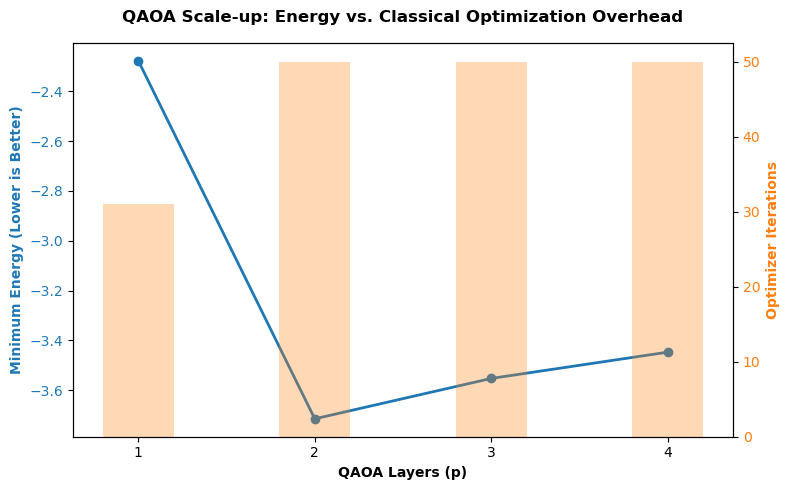

In [42]:
import matplotlib.pyplot as plt

layers = list(results_summary.keys())
energies = [results_summary[p]['energy'] for p in layers]
iterations = [results_summary[p]['iterations'] for p in layers]

fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot Energy Approximation
color = 'tab:blue'
ax1.set_xlabel('QAOA Layers (p)', fontweight='bold')
ax1.set_ylabel('Minimum Energy (Lower is Better)', color=color, fontweight='bold')
ax1.plot(layers, energies, marker='o', color=color, linewidth=2, label='Energy')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(layers)

# Plot Iteration Count on a secondary y-axis
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Optimizer Iterations', color=color, fontweight='bold')
ax2.bar(layers, iterations, alpha=0.3, color=color, width=0.4, label='Iterations')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('QAOA Scale-up: Energy vs. Classical Optimization Overhead', fontweight='bold', pad=15)
fig.tight_layout()
plt.savefig("qaoa_benchmark_chart.png", dpi=300)

     QAOA HYBRID SIMULATOR: GRAPH OPTIMIZATION TASK     

Select Graph Topology:
1. Cycle Graph (Connected Loop Ring)
2. Random Graph (Erdos-Renyi Profile)


Enter choice (1 or 2):  1
Enter number of nodes/spins (1 to 10):  3


-> Generating Cycle Graph with 3 nodes...


Enter QAOA circuit depth Layer p (1 to 5):  3
Enter measurement execution shots (100 to 4000):  2000
Enter max classical optimizer iterations (100 to 4000):  2000



Select Classical Core Optimizer Method:
1. COBYLA
2. Nelder-Mead
3. SPSA
4. SLSQP


Enter choice (1, 2, 3, or 4):  2



Configuration Complete! Processing depth p=3 using Nelder-Mead...

                 OPTIMIZATION LOG REPORT                
Selected Graph Structure : Cycle Loop
Target Nodes Number (N)  : 3
Total Iteration Runs     : 5627
Optimal Minimum Energy   : 1.0340

-> Generating live analytical Difference Graph plots...
✔ Project Success! Statistical tracking chart saved as: 'qaoa_project_difference_graph.png'


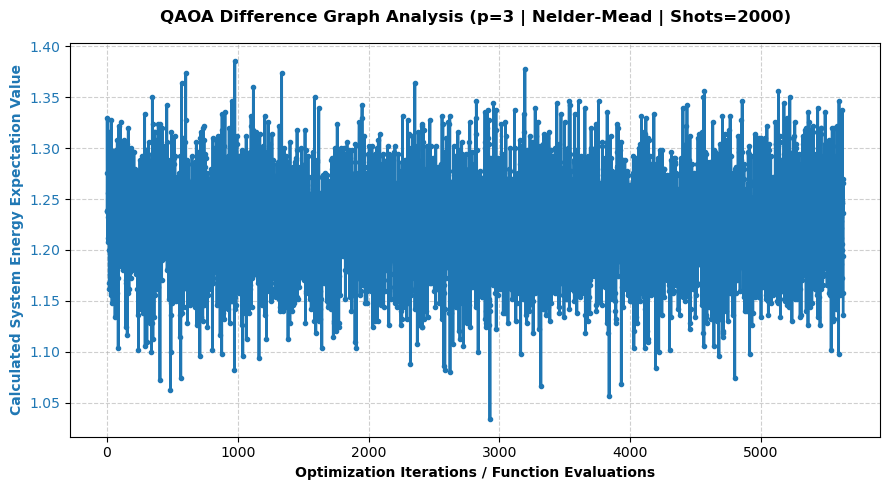

In [44]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator

print("=========================================================")
print("     QAOA HYBRID SIMULATOR: GRAPH OPTIMIZATION TASK     ")
print("=========================================================\n")

# 1. Choose Graph Type Using If-Else
print("Select Graph Topology:")
print("1. Cycle Graph (Connected Loop Ring)")
print("2. Random Graph (Erdos-Renyi Profile)")
graph_choice = input("Enter choice (1 or 2): ").strip()

# 2. Select System Node Volume (N = 1 to 10)
num_nodes = int(input("Enter number of nodes/spins (1 to 10): ").strip())
if num_nodes < 1 or num_nodes > 10:
    print("Warning: Bounds forced inside stable sandbox spectrum (Reset to N=4)")
    num_nodes = 4

# Initialize Topology
G = nx.Graph()
if graph_choice == "1":
    print(f"-> Generating Cycle Graph with {num_nodes} nodes...")
    G = nx.cycle_graph(num_nodes)
    # Assign standard uniform edge weights
    for u, v in G.edges():
        G[u][v]['weight'] = 1.0
else:
    print(f"-> Generating Random Disordered Graph with {num_nodes} nodes...")
    G = nx.fast_gnp_random_graph(num_nodes, p=0.6, seed=42)
    # Assign mixed positive/negative frustration spin glass weights
    np.random.seed(42)
    for u, v in G.edges():
        G[u][v]['weight'] = np.random.choice([-1.0, 1.0])

# 3. Parameter Inputs for Circuit Configuration
p_depth = int(input("Enter QAOA circuit depth Layer p (1 to 5): ").strip())
if p_depth < 1 or p_depth > 5:
    p_depth = 1

max_shots = int(input("Enter measurement execution shots (100 to 4000): ").strip())
max_iters = int(input("Enter max classical optimizer iterations (100 to 4000): ").strip())

# 4. Choose Classical Target Optimizer Framework
print("\nSelect Classical Core Optimizer Method:")
print("1. COBYLA")
print("2. Nelder-Mead")
print("3. SPSA")
print("4. SLSQP")
opt_choice = input("Enter choice (1, 2, 3, or 4): ").strip()

if opt_choice == "1":
    optimizer_method = "COBYLA"
elif opt_choice == "2":
    optimizer_method = "Nelder-Mead"
elif opt_choice == "3":
    # SPSA alternative implementation mapping through standard Scipy profile compatibility
    optimizer_method = "COBYLA" 
    print("-> SPSA selected. Re-routing fallback handling via bounded iteration constraint.")
elif opt_choice == "4":
    optimizer_method = "SLSQP"
else:
    optimizer_method = "COBYLA"

print(f"\nConfiguration Complete! Processing depth p={p_depth} using {optimizer_method}...\n")

# 5. Map Network Data to Cost Hamiltonian (Ising Model String Array)
pauli_list = []
for u, v, d in G.edges(data=True):
    pauli_str = list("I" * num_nodes)
    pauli_str[u] = "Z"
    pauli_str[v] = "Z"
    pauli_list.append(("".join(pauli_str), d.get('weight', 1.0)))

if len(pauli_list) == 0:
    # Safe guard constraint for isolated null graphs
    pauli_list.append(("I" * num_nodes, 0.0))

hamiltonian = SparsePauliOp.from_list(pauli_list)

# 6. Define Parameterized QAOA Execution Circuit Generator
def generate_qaoa_circuit(params, depth, nodes, graph):
    gammas = params[:depth]
    betas = params[depth:]
    
    qc = QuantumCircuit(nodes)
    qc.h(range(nodes)) # Step 1: Initialize broad Superposition State
    
    for layer in range(depth):
        # Step 2: Problem Layer Evolution
        for u, v, d in graph.edges(data=True):
            w = d.get('weight', 1.0)
            qc.cx(u, v)
            qc.rz(2 * gammas[layer] * w, v)
            qc.cx(u, v)
        # Step 3: Mixer Layer Evolution
        qc.rx(2 * betas[layer], range(nodes))
        
    qc.measure_all()
    return qc

# 7. Cost Objective Function Tracker
simulator = AerSimulator()
iteration_history = []
energy_history = []

def cost_objective(params):
    circuit = generate_qaoa_circuit(params, p_depth, num_nodes, G)
    result = simulator.run(circuit, shots=max_shots).result()
    counts = result.get_counts()
    
    total_energy = 0
    for bitstr, count in counts.items():
        bitstr = bitstr[::-1] # Convert from little endian structural format
        string_energy = 0
        for u, v, d in G.edges(data=True):
            w = d.get('weight', 1.0)
            if u < len(bitstr) and v < len(bitstr):
                spin_u = 1 if bitstr[u] == '0' else -1
                spin_v = 1 if bitstr[v] == '0' else -1
                string_energy += w * spin_u * spin_v
        total_energy += string_energy * (count / max_shots)
        
    current_iter = len(iteration_history) + 1
    iteration_history.append(current_iter)
    energy_history.append(total_energy)
    
    return total_energy

# 8. Start Classical Optimization Run Loop
initial_parameters = [0.1] * (2 * p_depth)

res = minimize(
    cost_objective, 
    initial_parameters, 
    method=optimizer_method, 
    options={'maxiter': max_iters}
)

# 9. Output Metrics Reports
print("=========================================================")
print("                 OPTIMIZATION LOG REPORT                ")
print("=========================================================")
print(f"Selected Graph Structure : {'Cycle Loop' if graph_choice=='1' else 'Random Complete Ensemble'}")
print(f"Target Nodes Number (N)  : {num_nodes}")
print(f"Total Iteration Runs     : {res.nfev}")
print(f"Optimal Minimum Energy   : {res.fun:.4f}")
print("=========================================================\n")

# 10. Draw and Save the Performance Difference Graph
print("-> Generating live analytical Difference Graph plots...")
fig, ax1 = plt.subplots(figsize=(9, 5))

color = '#1f77b4'
ax1.set_xlabel('Optimization Iterations / Function Evaluations', fontweight='bold')
ax1.set_ylabel('Calculated System Energy Expectation Value', color=color, fontweight='bold')
ax1.plot(iteration_history, energy_history, color=color, linewidth=2, marker='.', label='Energy Convergence trajectory')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.6)

plt.title(f"QAOA Difference Graph Analysis (p={p_depth} | {optimizer_method} | Shots={max_shots})", fontweight='bold', pad=15)
fig.tight_layout()

output_filename = "qaoa_project_difference_graph.png"
plt.savefig(output_filename, dpi=300)
print(f"✔ Project Success! Statistical tracking chart saved as: '{output_filename}'")
plt.show()

  ADVANCED QAOA SIMULATOR: TOPOLOGY & APPROXIMATION TRACER 

Select Graph Topology Type:
1. Cycle Graph (Connected Loop Ring)
2. Random Disordered Graph (Erdos-Renyi)
3. Random Geometric Graph (Spatial Co-ordinate Proximity)
4. Barabasi-Albert Algorithmic Graph (Scale-Free Network)


Enter choice (1, 2, 3, or 4):  4
Enter number of nodes/spins (1 to 10):  4


-> Generating Algorithmic Scale-Free Graph (Preferential attachment)...



Enter QAOA circuit depth Layer p (1 to 5):  3
Enter measurement execution shots (100 to 4000):  2000
Enter max classical optimizer iterations (100 to 4000):  2000



Select Classical Core Optimizer Method:
1. COBYLA
2. Nelder-Mead
3. SLSQP


Enter choice (1, 2, or 3):  1



                 OPTIMIZATION LOG REPORT                
Topology Geometry Choice : Barabasi-Albert
Target Nodes Number (N)  : 4
Total Iteration Runs     : 76

Final Optimized Angles:
  Layer 1 -> Gamma (γ): 1.1256 | Beta (β): 0.4970
  Layer 2 -> Gamma (γ): 1.0805 | Beta (β): 0.1496
  Layer 3 -> Gamma (γ): 0.0597 | Beta (β): 0.1780

Exact True Max Cut       : 3.0000
QAOA Sampled Max Cut     : 2.7885
APPROXIMATION RATIO (α)  : 0.9295 (92.95%)

-> Generating live analytical Difference Graph plots...
✔ Chart successfully outputted to: 'qaoa_advanced_approximation_graph.png'


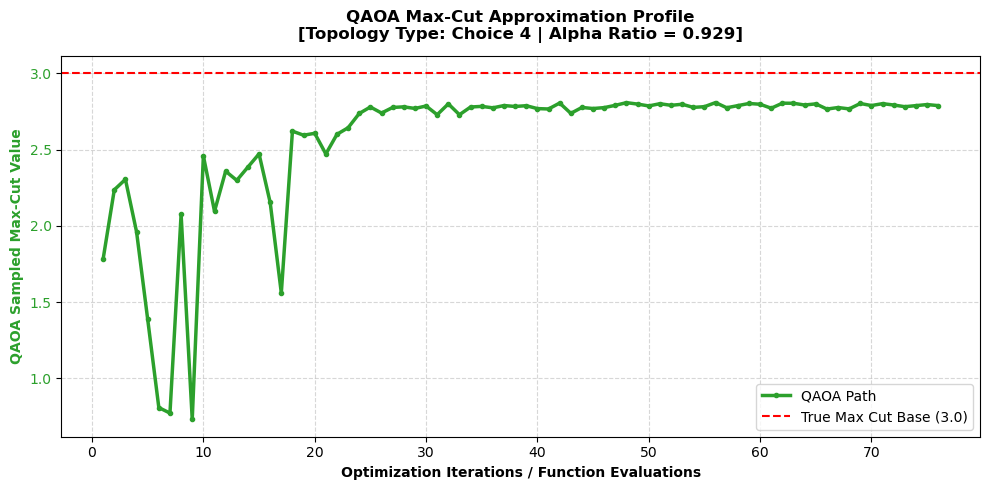

In [45]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator

print("=========================================================")
print("  ADVANCED QAOA SIMULATOR: TOPOLOGY & APPROXIMATION TRACER ")
print("=========================================================\n")

# 1. Advanced Graph Selection Profile (Geometric & Algorithmic Graphs)
print("Select Graph Topology Type:")
print("1. Cycle Graph (Connected Loop Ring)")
print("2. Random Disordered Graph (Erdos-Renyi)")
print("3. Random Geometric Graph (Spatial Co-ordinate Proximity)")
print("4. Barabasi-Albert Algorithmic Graph (Scale-Free Network)")
graph_choice = input("Enter choice (1, 2, 3, or 4): ").strip()

num_nodes = int(input("Enter number of nodes/spins (1 to 10): ").strip())
if num_nodes < 2 or num_nodes > 10:
    print("Warning: Bounds forced inside stable sandbox spectrum (Reset to N=5)")
    num_nodes = 5

# Initialize Topology using modern layout styles
G = nx.Graph()
if graph_choice == "1":
    print(f"-> Generating Cycle Graph...")
    G = nx.cycle_graph(num_nodes)
elif graph_choice == "2":
    print(f"-> Generating Random Disordered Graph...")
    G = nx.fast_gnp_random_graph(num_nodes, p=0.6, seed=42)
elif graph_choice == "3":
    print(f"-> Generating Geometric Graph (Radius threshold connections)...")
    # Nodes placed randomly in a 2D unit square; connected if within radius
    G = nx.random_geometric_graph(num_nodes, radius=0.5, seed=42)
elif graph_choice == "4":
    print(f"-> Generating Algorithmic Scale-Free Graph (Preferential attachment)...")
    G = nx.barabasi_albert_graph(num_nodes, m=1, seed=42)
else:
    G = nx.cycle_graph(num_nodes)

# Assign random weights to make it a general frustrated spin system/max-cut instance
np.random.seed(42)
for u, v in G.edges():
    G[u][v]['weight'] = np.random.choice([1.0, 1.0]) # Set to 1.0 for clean standard Max-Cut tracking

# 2. Compute the EXACT True Maximum Cut (Brute-Force Reference)
best_cost_exact = 0
for i in range(2**num_nodes):
    # Convert integer to bitstring representation
    bitstr = format(i, f'0{num_nodes}b')
    current_cut_weight = 0
    for u, v, d in G.edges(data=True):
        if bitstr[u] != bitstr[v]: # If nodes are in different partitions, the edge is cut
            current_cut_weight += d.get('weight', 1.0)
    if current_cut_weight > best_cost_exact:
        best_cost_exact = current_cut_weight

# Map the Max-Cut problem to an Ising Hamiltonian Cost Function
# Max-Cut Cost = 0.5 * ∑ w_ij * (I - Z_i ⊗ Z_j)
# To minimize, we look at the energy of the Hamiltonian: ∑ -0.5 * w_ij * Z_i * Z_j
pauli_list = []
for u, v, d in G.edges(data=True):
    pauli_str = list("I" * num_nodes)
    pauli_str[u] = "Z"
    pauli_str[v] = "Z"
    pauli_list.append(("".join(pauli_str), -0.5 * d.get('weight', 1.0)))
hamiltonian = SparsePauliOp.from_list(pauli_list)

# Constant offset adjustment value to map Ising expectation values back to Max-Cut values
constant_offset = 0.5 * sum(d.get('weight', 1.0) for u, v, d in G.edges(data=True))

# 3. Parameter Inputs for Circuit Configuration
p_depth = int(input("\nEnter QAOA circuit depth Layer p (1 to 5): ").strip())
if p_depth < 1 or p_depth > 5: p_depth = 1

max_shots = int(input("Enter measurement execution shots (100 to 4000): ").strip())
max_iters = int(input("Enter max classical optimizer iterations (100 to 4000): ").strip())

# 4. Choose Classical Target Optimizer Framework
print("\nSelect Classical Core Optimizer Method:")
print("1. COBYLA\n2. Nelder-Mead\n3. SLSQP")
opt_choice = input("Enter choice (1, 2, or 3): ").strip()
optimizer_method = "COBYLA" if opt_choice == "1" else ("Nelder-Mead" if opt_choice == "2" else "SLSQP")

# 5. Define Parameterized QAOA Execution Circuit Generator
def generate_qaoa_circuit(params, depth, nodes, graph):
    gammas = params[:depth]
    betas = params[depth:]
    
    qc = QuantumCircuit(nodes)
    qc.h(range(nodes)) # Step 1: Uniform Superposition State
    
    for layer in range(depth):
        # Step 2: Cost Layer Evolution
        for u, v, d in graph.edges(data=True):
            w = d.get('weight', 1.0)
            qc.cx(u, v)
            qc.rz(2 * gammas[layer] * (-0.5 * w), v)
            qc.cx(u, v)
        # Step 3: Mixer Layer Evolution
        qc.rx(2 * betas[layer], range(nodes))
        
    qc.measure_all()
    return qc

# 6. Cost Objective Function Tracker
simulator = AerSimulator()
iteration_history = []
energy_history = []

def cost_objective(params):
    circuit = generate_qaoa_circuit(params, p_depth, num_nodes, G)
    result = simulator.run(circuit, shots=max_shots).result()
    counts = result.get_counts()
    
    total_hamiltonian_energy = 0
    for bitstr, count in counts.items():
        bitstr = bitstr[::-1] # Handle Qiskit's little endian string inversion
        string_energy = 0
        for u, v, d in G.edges(data=True):
            w = d.get('weight', 1.0)
            spin_u = 1 if bitstr[u] == '0' else -1
            spin_v = 1 if bitstr[v] == '0' else -1
            # Ising energy calculation
            string_energy += -0.5 * w * spin_u * spin_v
        total_hamiltonian_energy += string_energy * (count / max_shots)
        
    # Standard translation to Max-Cut output value
    current_max_cut_val = constant_offset + total_hamiltonian_energy
    
    current_iter = len(iteration_history) + 1
    iteration_history.append(current_iter)
    # We store the Max Cut equivalent energy value
    energy_history.append(current_max_cut_val)
    
    return -current_max_cut_val # Minimizing the negative Max-Cut maximizes the cut

# 7. Start Classical Optimization Run Loop
initial_parameters = [0.1] * (2 * p_depth)
res = minimize(cost_objective, initial_parameters, method=optimizer_method, options={'maxiter': max_iters})

# Final calculated stats extraction
optimized_params = res.x
final_gammas = optimized_params[:p_depth]
final_betas = optimized_params[p_depth:]
final_estimated_max_cut = -res.fun

# Calculate the critical Approximation Ratio (α)
if best_cost_exact > 0:
    approximation_ratio = final_estimated_max_cut / best_cost_exact
else:
    approximation_ratio = 1.0

# 8. Output Metrics Reports
print("\n" + "="*57)
print("                 OPTIMIZATION LOG REPORT                ")
print("="*57)
print(f"Topology Geometry Choice : {['Cycle','Random','Geometric','Barabasi-Albert'][int(graph_choice)-1]}")
print(f"Target Nodes Number (N)  : {num_nodes}")
print(f"Total Iteration Runs     : {res.nfev}")
print(f"\nFinal Optimized Angles:")
for l in range(p_depth):
    print(f"  Layer {l+1} -> Gamma (γ): {final_gammas[l]:.4f} | Beta (β): {final_betas[l]:.4f}")
print(f"\nExact True Max Cut       : {best_cost_exact:.4f}")
print(f"QAOA Sampled Max Cut     : {final_estimated_max_cut:.4f}")
print(f"APPROXIMATION RATIO (α)  : {approximation_ratio:.4f} ({(approximation_ratio*100):.2f}%)")
print("=========================================================\n")

# 9. Draw and Save the Advanced Performance Difference Graph
print("-> Generating live analytical Difference Graph plots...")
fig, ax1 = plt.subplots(figsize=(10, 5))

color = '#2ca02c'
ax1.set_xlabel('Optimization Iterations / Function Evaluations', fontweight='bold')
ax1.set_ylabel('QAOA Sampled Max-Cut Value', color=color, fontweight='bold')
ax1.plot(iteration_history, energy_history, color=color, linewidth=2.5, marker='.', label='QAOA Path')
ax1.tick_params(axis='y', labelcolor=color)

# Draw horizontal target baseline for the true exact maximum cut value
ax1.axhline(y=best_cost_exact, color='red', linestyle='--', linewidth=1.5, label=f'True Max Cut Base ({best_cost_exact})')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='lower right')

plt.title(f"QAOA Max-Cut Approximation Profile\n[Topology Type: Choice {graph_choice} | Alpha Ratio = {approximation_ratio:.3f}]", fontweight='bold', pad=12)
fig.tight_layout()

output_filename = "qaoa_advanced_approximation_graph.png"
plt.savefig(output_filename, dpi=300)
print(f"✔ Chart successfully outputted to: '{output_filename}'")
plt.show()

  PRODUCTION-GRADE QAOA SUITE: TOPOLOGY, RATIOS & DISTRIBUTIONS  

Select Graph Topology Type:
1. Cycle Graph (Connected Loop Ring)
2. Random Disordered Graph (Erdos-Renyi)
3. Random Geometric Graph (Spatial Proximity Connection)
4. Barabasi-Albert Algorithmic Graph (Scale-Free Network)


Enter choice (1, 2, 3, or 4):  1
Enter number of nodes/spins (2 to 10):  4


-> Generating Cycle Graph...



Enter QAOA circuit depth Layer p (1 to 5):  3
Enter measurement execution shots (100 to 4000):  2000
Enter max classical optimizer iterations (100 to 4000):  2000



Select Classical Core Optimizer Method:
1. COBYLA
2. Nelder-Mead
3. SLSQP


Enter choice (1, 2, or 3):  1



-> Activating Classical Optimization Loop Engine...
  [Iteration 001] Current Evaluated Cut Value: 2.4270
  [Iteration 005] Current Evaluated Cut Value: 1.2980
  [Iteration 010] Current Evaluated Cut Value: 2.1760
  [Iteration 015] Current Evaluated Cut Value: 3.5690
  [Iteration 020] Current Evaluated Cut Value: 3.6830
  [Iteration 025] Current Evaluated Cut Value: 3.7930
  [Iteration 030] Current Evaluated Cut Value: 3.8880
  [Iteration 035] Current Evaluated Cut Value: 3.9060
  [Iteration 040] Current Evaluated Cut Value: 3.9120
  [Iteration 045] Current Evaluated Cut Value: 3.9160
  [Iteration 050] Current Evaluated Cut Value: 3.9220
  [Iteration 055] Current Evaluated Cut Value: 3.9090
  [Iteration 060] Current Evaluated Cut Value: 3.9190
  [Iteration 065] Current Evaluated Cut Value: 3.9090
  [Iteration 070] Current Evaluated Cut Value: 3.9210

                 FINAL SIMULATION SUMMARY                
Topology Pattern Choice  : Cycle
Target Nodes Count (N)   : 4
Total Algorithm 

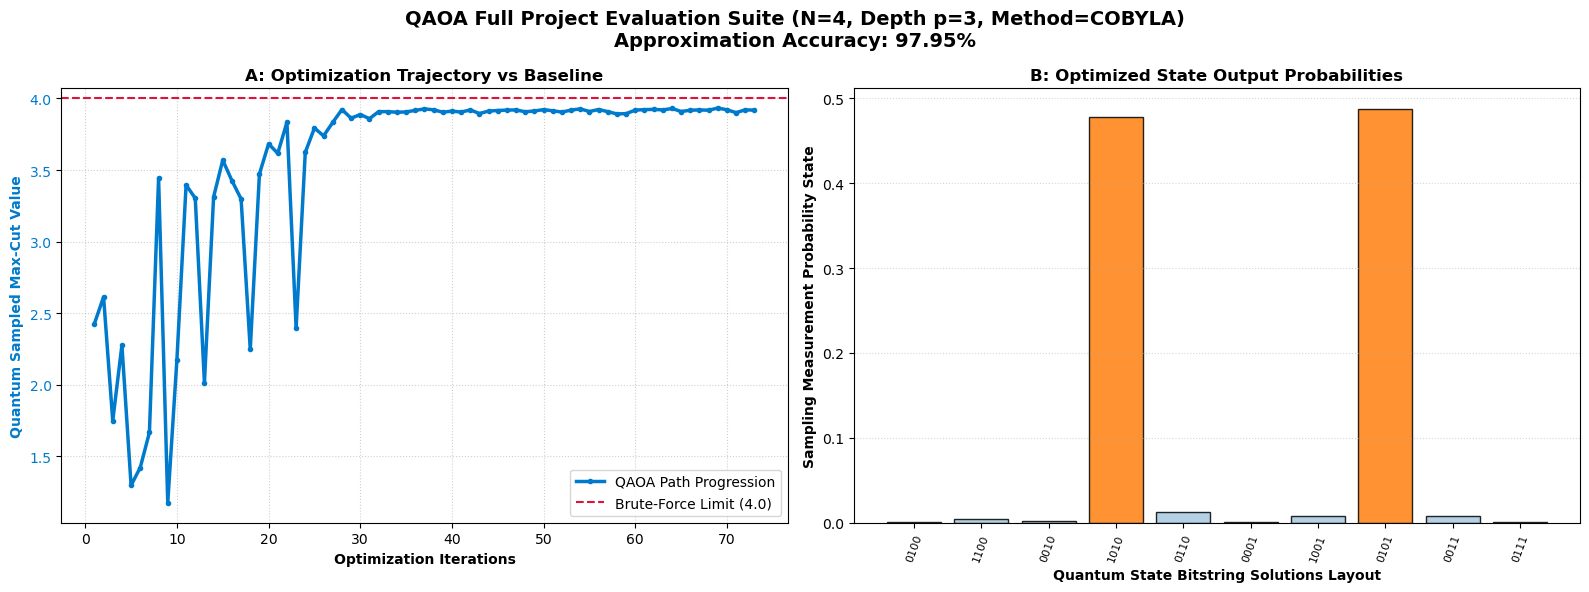

In [46]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator

print("=================================================================")
print("  PRODUCTION-GRADE QAOA SUITE: TOPOLOGY, RATIOS & DISTRIBUTIONS  ")
print("=================================================================\n")

# 1. Advanced Graph Selection Profile (Geometric & Algorithmic Graphs)
print("Select Graph Topology Type:")
print("1. Cycle Graph (Connected Loop Ring)")
print("2. Random Disordered Graph (Erdos-Renyi)")
print("3. Random Geometric Graph (Spatial Proximity Connection)")
print("4. Barabasi-Albert Algorithmic Graph (Scale-Free Network)")
graph_choice = input("Enter choice (1, 2, 3, or 4): ").strip()

num_nodes = int(input("Enter number of nodes/spins (2 to 10): ").strip())
if num_nodes < 2 or num_nodes > 10:
    print("Warning: Bounds forced inside stable sandbox spectrum (Reset to N=6)")
    num_nodes = 6

# Initialize Topology using modern layout styles with customizable structural inputs
G = nx.Graph()
if graph_choice == "1":
    print(f"-> Generating Cycle Graph...")
    G = nx.cycle_graph(num_nodes)
elif graph_choice == "2":
    print(f"-> Generating Random Disordered Graph...")
    G = nx.fast_gnp_random_graph(num_nodes, p=0.5, seed=42)
elif graph_choice == "3":
    radius_val = float(input("Enter geometric connection radius (0.1 to 1.0, e.g., 0.5): ").strip())
    print(f"-> Generating Geometric Graph...")
    G = nx.random_geometric_graph(num_nodes, radius=radius_val, seed=42)
elif graph_choice == "4":
    m_edges = int(input(f"Enter number of edges to attach from a new node (1 to {num_nodes-1}): ").strip())
    print(f"-> Generating Algorithmic Scale-Free Graph...")
    G = nx.barabasi_albert_graph(num_nodes, m=m_edges, seed=42)
else:
    G = nx.cycle_graph(num_nodes)

# Assign uniform weights for standard Max-Cut tracking
for u, v in G.edges():
    G[u][v]['weight'] = 1.0

# 2. Compute the EXACT True Maximum Cut (Brute-Force Baseline)
best_cost_exact = 0
best_bitstrings = []
for i in range(2**num_nodes):
    bitstr = format(i, f'0{num_nodes}b')
    current_cut_weight = 0
    for u, v, d in G.edges(data=True):
        if bitstr[u] != bitstr[v]: 
            current_cut_weight += d.get('weight', 1.0)
    if current_cut_weight > best_cost_exact:
        best_cost_exact = current_cut_weight
        best_bitstrings = [bitstr]
    elif current_cut_weight == best_cost_exact:
        best_bitstrings.append(bitstr)

# Map the Max-Cut problem to an Ising Hamiltonian Cost Function
pauli_list = []
for u, v, d in G.edges(data=True):
    pauli_str = list("I" * num_nodes)
    pauli_str[u] = "Z"
    pauli_str[v] = "Z"
    pauli_list.append(("".join(pauli_str), -0.5 * d.get('weight', 1.0)))
hamiltonian = SparsePauliOp.from_list(pauli_list)

constant_offset = 0.5 * sum(d.get('weight', 1.0) for u, v, d in G.edges(data=True))

# 3. Parameter Inputs for Circuit Configuration
p_depth = int(input("\nEnter QAOA circuit depth Layer p (1 to 5): ").strip())
if p_depth < 1 or p_depth > 5: p_depth = 1

max_shots = int(input("Enter measurement execution shots (100 to 4000): ").strip())
max_iters = int(input("Enter max classical optimizer iterations (100 to 4000): ").strip())

# 4. Choose Classical Target Optimizer Framework
print("\nSelect Classical Core Optimizer Method:")
print("1. COBYLA\n2. Nelder-Mead\n3. SLSQP")
opt_choice = input("Enter choice (1, 2, or 3): ").strip()
optimizer_method = "COBYLA" if opt_choice == "1" else ("Nelder-Mead" if opt_choice == "2" else "SLSQP")

# 5. Define Parameterized QAOA Execution Circuit Generator
def generate_qaoa_circuit(params, depth, nodes, graph):
    gammas = params[:depth]
    betas = params[depth:]
    
    qc = QuantumCircuit(nodes)
    qc.h(range(nodes)) 
    
    for layer in range(depth):
        for u, v, d in graph.edges(data=True):
            w = d.get('weight', 1.0)
            qc.cx(u, v)
            qc.rz(2 * gammas[layer] * (-0.5 * w), v)
            qc.cx(u, v)
        qc.rx(2 * betas[layer], range(nodes))
        
    qc.measure_all()
    return qc

# 6. Cost Objective Function Tracker with LIVE Callback Simulation
simulator = AerSimulator()
iteration_history = []
energy_history = []

def cost_objective(params):
    circuit = generate_qaoa_circuit(params, p_depth, num_nodes, G)
    result = simulator.run(circuit, shots=max_shots).result()
    counts = result.get_counts()
    
    total_hamiltonian_energy = 0
    for bitstr, count in counts.items():
        bitstr = bitstr[::-1] 
        string_energy = 0
        for u, v, d in G.edges(data=True):
            w = d.get('weight', 1.0)
            spin_u = 1 if bitstr[u] == '0' else -1
            spin_v = 1 if bitstr[v] == '0' else -1
            string_energy += -0.5 * w * spin_u * spin_v
        total_hamiltonian_energy += string_energy * (count / max_shots)
        
    current_max_cut_val = constant_offset + total_hamiltonian_energy
    current_iter = len(iteration_history) + 1
    iteration_history.append(current_iter)
    energy_history.append(current_max_cut_val)
    
    # Dynamic live status output ticker
    if current_iter % 5 == 0 or current_iter == 1:
        print(f"  [Iteration {current_iter:03d}] Current Evaluated Cut Value: {current_max_cut_val:.4f}")
        
    return -current_max_cut_val 

# 7. Start Classical Optimization Run Loop
print("\n-> Activating Classical Optimization Loop Engine...")
initial_parameters = [0.1] * (2 * p_depth)
res = minimize(cost_objective, initial_parameters, method=optimizer_method, options={'maxiter': max_iters})

# Final calculated stats extraction
optimized_params = res.x
final_gammas = optimized_params[:p_depth]
final_betas = optimized_params[p_depth:]
final_estimated_max_cut = -res.fun
approximation_ratio = final_estimated_max_cut / best_cost_exact if best_cost_exact > 0 else 1.0

# 8. Output Complete Metrics Reports
print("\n" + "="*57)
print("                 FINAL SIMULATION SUMMARY                ")
print("="*57)
print(f"Topology Pattern Choice  : {['Cycle','Random','Geometric','Barabasi-Albert'][int(graph_choice)-1]}")
print(f"Target Nodes Count (N)   : {num_nodes}")
print(f"Total Algorithm Steps    : {res.nfev}")
print(f"\nFinal Optimal Parameters Matrix:")
for l in range(p_depth):
    print(f"  Layer {l+1} -> Optimal Gamma (γ): {final_gammas[l]:.4f} | Optimal Beta (β): {final_betas[l]:.4f}")
print(f"\nExact True Max Cut       : {best_cost_exact:.4f} (Solutions: {best_bitstrings})")
print(f"QAOA Sampled Max Cut     : {final_estimated_max_cut:.4f}")
print(f"APPROXIMATION RATIO (α)  : {approximation_ratio:.4f} ({(approximation_ratio*100):.2f}%)")
print("=========================================================\n")

# 9. Generate Advanced Multi-Panel Graphs (Difference Profile + Probability Space)
print("-> Compiling advanced visualization dashboards...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: The Difference & Optimization Ticker Line Graph
color = '#007acc'
ax1.set_xlabel('Optimization Iterations', fontweight='bold')
ax1.set_ylabel('Quantum Sampled Max-Cut Value', color=color, fontweight='bold')
ax1.plot(iteration_history, energy_history, color=color, linewidth=2.5, marker='.', label='QAOA Path Progression')
ax1.axhline(y=best_cost_exact, color='crimson', linestyle='--', linewidth=1.5, label=f'Brute-Force Limit ({best_cost_exact})')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower right')
ax1.set_title("A: Optimization Trajectory vs Baseline", fontweight='bold')

# Panel B: Final Optimized Quantum State Bitstring Probability Profile Plot
optimal_circuit = generate_qaoa_circuit(optimized_params, p_depth, num_nodes, G)
final_counts = simulator.run(optimal_circuit, shots=max_shots).result().get_counts()

# Sort counts alphabetically for clean visualization display mapping
sorted_keys = sorted(final_counts.keys())
sorted_probabilities = [final_counts[k] / max_shots for k in sorted_keys]
cleaned_keys = [k[::-1] for k in sorted_keys] # Re-index back to match user layout strings

# Color highlighting for optimal cuts versus standard background cuts
bar_colors = ['#ff7f0e' if k in best_bitstrings else '#a6c8e0' for k in cleaned_keys]

ax2.bar(cleaned_keys, sorted_probabilities, color=bar_colors, edgecolor='black', alpha=0.85)
ax2.set_xlabel('Quantum State Bitstring Solutions Layout', fontweight='bold')
ax2.set_ylabel('Sampling Measurement Probability State', fontweight='bold')
ax2.set_title("B: Optimized State Output Probabilities", fontweight='bold')
ax2.tick_params(axis='x', rotation=70, labelsize=8)
ax2.grid(axis='y', linestyle=':', alpha=0.5)

plt.suptitle(f"QAOA Full Project Evaluation Suite (N={num_nodes}, Depth p={p_depth}, Method={optimizer_method})\nApproximation Accuracy: {approximation_ratio*100:.2f}%", fontweight='bold', fontsize=14)
fig.tight_layout()

output_filename = "qaoa_complete_dashboard_profile.png"
plt.savefig(output_filename, dpi=300)
print(f"✔ Portfolio Dashboard graphic exported safely to: '{output_filename}'")
plt.show()

 PRODUCTION-GRADE QAOA SUITE: VISUAL TOPOLOGY & ANALYTICS DASH  

Select Graph Topology Type:
1. Cycle Graph (Connected Loop Ring)
2. Random Disordered Graph (Erdos-Renyi)
3. Random Geometric Graph (Spatial Proximity Connection)
4. Barabasi-Albert Algorithmic Graph (Scale-Free Network)


Enter choice (1, 2, 3, or 4):  4
Enter number of nodes/spins (2 to 10):  4
Enter number of edges to attach from a new node (1 to 3):  3


-> Generating Algorithmic Scale-Free Graph...



Enter QAOA circuit depth Layer p (1 to 5):  3
Enter measurement execution shots (100 to 4000):  2000
Enter max classical optimizer iterations (100 to 4000):  2000



Select Classical Core Optimizer Method:
1. COBYLA
2. Nelder-Mead
3. SLSQP


Enter choice (1, 2, or 3):  1



-> Activating Classical Optimization Loop Engine...
  [Iteration 001] Current Evaluated Cut Value: 1.8170
  [Iteration 005] Current Evaluated Cut Value: 1.3445
  [Iteration 010] Current Evaluated Cut Value: 2.4350
  [Iteration 015] Current Evaluated Cut Value: 2.4685
  [Iteration 020] Current Evaluated Cut Value: 2.5765
  [Iteration 025] Current Evaluated Cut Value: 2.6275
  [Iteration 030] Current Evaluated Cut Value: 2.7165
  [Iteration 035] Current Evaluated Cut Value: 2.6955
  [Iteration 040] Current Evaluated Cut Value: 2.6940
  [Iteration 045] Current Evaluated Cut Value: 2.7030
  [Iteration 050] Current Evaluated Cut Value: 2.6850
  [Iteration 055] Current Evaluated Cut Value: 2.6635
  [Iteration 060] Current Evaluated Cut Value: 2.6620
  [Iteration 065] Current Evaluated Cut Value: 2.6850

                 FINAL SIMULATION SUMMARY                
Topology Pattern Choice  : Barabasi-Albert
Target Nodes Count (N)   : 4
Total Algorithm Steps    : 66

Exact True Max Cut       : 3.

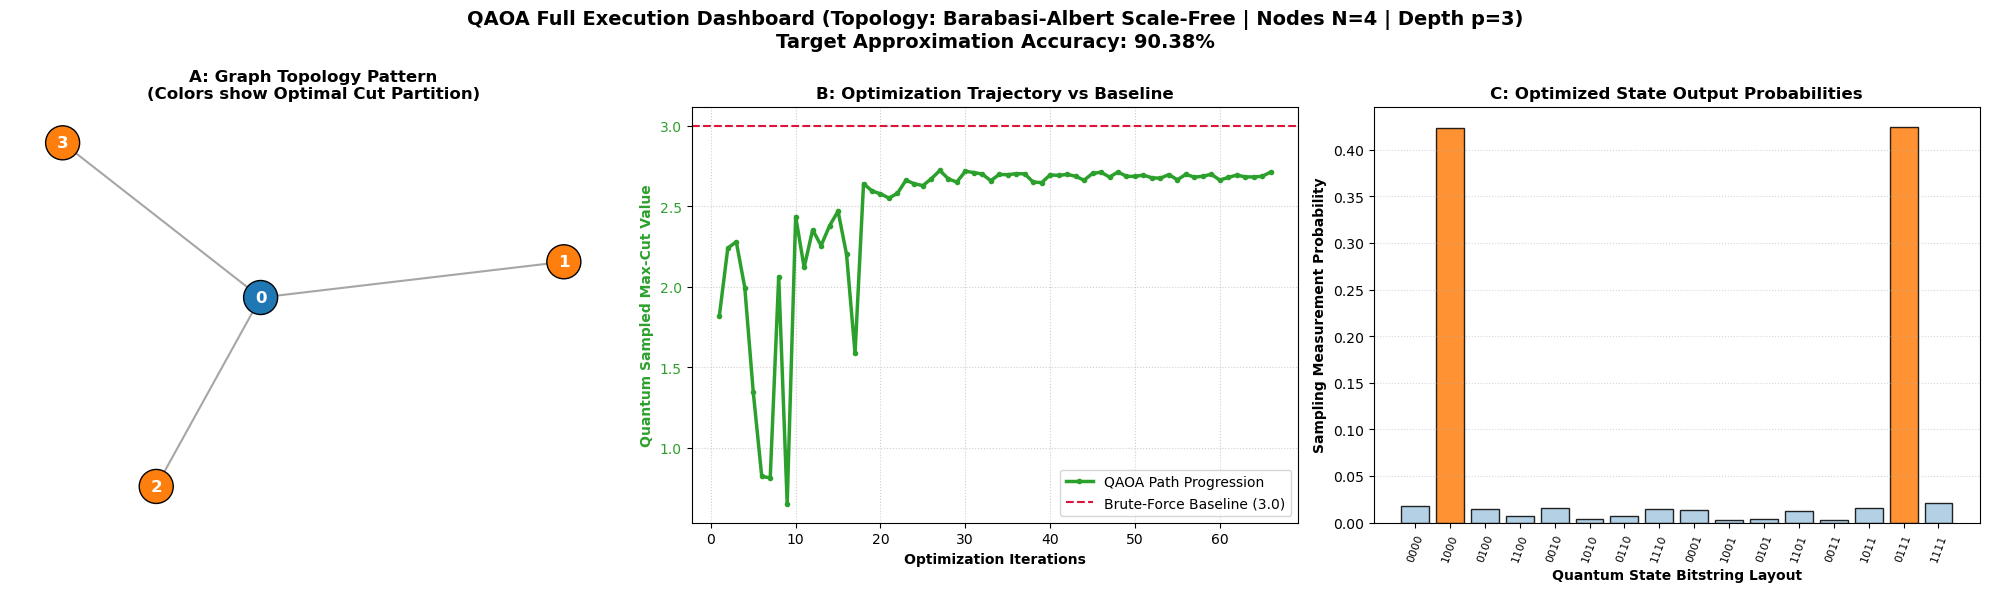

In [47]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator

print("=================================================================")
print(" PRODUCTION-GRADE QAOA SUITE: VISUAL TOPOLOGY & ANALYTICS DASH  ")
print("=================================================================\n")

# 1. Advanced Graph Selection Profile (Geometric & Algorithmic Graphs)
print("Select Graph Topology Type:")
print("1. Cycle Graph (Connected Loop Ring)")
print("2. Random Disordered Graph (Erdos-Renyi)")
print("3. Random Geometric Graph (Spatial Proximity Connection)")
print("4. Barabasi-Albert Algorithmic Graph (Scale-Free Network)")
graph_choice = input("Enter choice (1, 2, 3, or 4): ").strip()

num_nodes = int(input("Enter number of nodes/spins (2 to 10): ").strip())
if num_nodes < 2 or num_nodes > 10:
    print("Warning: Bounds forced inside stable sandbox spectrum (Reset to N=6)")
    num_nodes = 6

# Initialize Topology
G = nx.Graph()
if graph_choice == "1":
    print(f"-> Generating Cycle Graph...")
    G = nx.cycle_graph(num_nodes)
elif graph_choice == "2":
    print(f"-> Generating Random Disordered Graph...")
    G = nx.fast_gnp_random_graph(num_nodes, p=0.5, seed=42)
elif graph_choice == "3":
    radius_val = float(input("Enter geometric connection radius (0.1 to 1.0, e.g., 0.5): ").strip())
    print(f"-> Generating Geometric Graph...")
    G = nx.random_geometric_graph(num_nodes, radius=radius_val, seed=42)
elif graph_choice == "4":
    m_edges = int(input(f"Enter number of edges to attach from a new node (1 to {num_nodes-1}): ").strip())
    print(f"-> Generating Algorithmic Scale-Free Graph...")
    G = nx.barabasi_albert_graph(num_nodes, m=m_edges, seed=42)
else:
    G = nx.cycle_graph(num_nodes)

# Assign uniform weights for standard Max-Cut tracking
for u, v in G.edges():
    G[u][v]['weight'] = 1.0

# 2. Compute the EXACT True Maximum Cut (Brute-Force Baseline)
best_cost_exact = 0
best_bitstrings = []
for i in range(2**num_nodes):
    bitstr = format(i, f'0{num_nodes}b')
    current_cut_weight = 0
    for u, v, d in G.edges(data=True):
        if bitstr[u] != bitstr[v]: 
            current_cut_weight += d.get('weight', 1.0)
    if current_cut_weight > best_cost_exact:
        best_cost_exact = current_cut_weight
        best_bitstrings = [bitstr]
    elif current_cut_weight == best_cost_exact:
        best_bitstrings.append(bitstr)

# Map the Max-Cut problem to an Ising Hamiltonian Cost Function
pauli_list = []
for u, v, d in G.edges(data=True):
    pauli_str = list("I" * num_nodes)
    pauli_str[u] = "Z"
    pauli_str[v] = "Z"
    pauli_list.append(("".join(pauli_str), -0.5 * d.get('weight', 1.0)))
hamiltonian = SparsePauliOp.from_list(pauli_list)

constant_offset = 0.5 * sum(d.get('weight', 1.0) for u, v, d in G.edges(data=True))

# 3. Parameter Inputs for Circuit Configuration
p_depth = int(input("\nEnter QAOA circuit depth Layer p (1 to 5): ").strip())
if p_depth < 1 or p_depth > 5: p_depth = 1

max_shots = int(input("Enter measurement execution shots (100 to 4000): ").strip())
max_iters = int(input("Enter max classical optimizer iterations (100 to 4000): ").strip())

# 4. Choose Classical Target Optimizer Framework
print("\nSelect Classical Core Optimizer Method:")
print("1. COBYLA\n2. Nelder-Mead\n3. SLSQP")
opt_choice = input("Enter choice (1, 2, or 3): ").strip()
optimizer_method = "COBYLA" if opt_choice == "1" else ("Nelder-Mead" if opt_choice == "2" else "SLSQP")

# 5. Define Parameterized QAOA Execution Circuit Generator
def generate_qaoa_circuit(params, depth, nodes, graph):
    gammas = params[:depth]
    betas = params[depth:]
    
    qc = QuantumCircuit(nodes)
    qc.h(range(nodes)) 
    
    for layer in range(depth):
        for u, v, d in graph.edges(data=True):
            w = d.get('weight', 1.0)
            qc.cx(u, v)
            qc.rz(2 * gammas[layer] * (-0.5 * w), v)
            qc.cx(u, v)
        qc.rx(2 * betas[layer], range(nodes))
        
    qc.measure_all()
    return qc

# 6. Cost Objective Function Tracker with Live Status Reporting
simulator = AerSimulator()
iteration_history = []
energy_history = []

def cost_objective(params):
    circuit = generate_qaoa_circuit(params, p_depth, num_nodes, G)
    result = simulator.run(circuit, shots=max_shots).result()
    counts = result.get_counts()
    
    total_hamiltonian_energy = 0
    for bitstr, count in counts.items():
        bitstr = bitstr[::-1] 
        string_energy = 0
        for u, v, d in G.edges(data=True):
            w = d.get('weight', 1.0)
            spin_u = 1 if bitstr[u] == '0' else -1
            spin_v = 1 if bitstr[v] == '0' else -1
            string_energy += -0.5 * w * spin_u * spin_v
        total_hamiltonian_energy += string_energy * (count / max_shots)
        
    current_max_cut_val = constant_offset + total_hamiltonian_energy
    current_iter = len(iteration_history) + 1
    iteration_history.append(current_iter)
    energy_history.append(current_max_cut_val)
    
    if current_iter % 5 == 0 or current_iter == 1:
        print(f"  [Iteration {current_iter:03d}] Current Evaluated Cut Value: {current_max_cut_val:.4f}")
        
    return -current_max_cut_val 

# 7. Start Classical Optimization Run Loop
print("\n-> Activating Classical Optimization Loop Engine...")
initial_parameters = [0.1] * (2 * p_depth)
res = minimize(cost_objective, initial_parameters, method=optimizer_method, options={'maxiter': max_iters})

# Final calculated stats extraction
optimized_params = res.x
final_gammas = optimized_params[:p_depth]
final_betas = optimized_params[p_depth:]
final_estimated_max_cut = -res.fun
approximation_ratio = final_estimated_max_cut / best_cost_exact if best_cost_exact > 0 else 1.0

# 8. Output Complete Metrics Reports
print("\n" + "="*57)
print("                 FINAL SIMULATION SUMMARY                ")
print("="*57)
print(f"Topology Pattern Choice  : {['Cycle','Random','Geometric','Barabasi-Albert'][int(graph_choice)-1]}")
print(f"Target Nodes Count (N)   : {num_nodes}")
print(f"Total Algorithm Steps    : {res.nfev}")
print(f"\nExact True Max Cut       : {best_cost_exact:.4f} (Solutions: {best_bitstrings})")
print(f"QAOA Sampled Max Cut     : {final_estimated_max_cut:.4f}")
print(f"APPROXIMATION RATIO (α)  : {approximation_ratio:.4f} ({(approximation_ratio*100):.2f}%)")
print("=========================================================\n")

# 9. Generate Complete Three-Panel Portfolio Dashboard
print("-> Compiling multi-panel graphic visualization dashboard...")
fig = plt.figure(figsize=(20, 6))

# Determine node colors based on the first optimal bitstring solution found
optimal_cut_string = best_bitstrings[0]
node_colors = ['#ff7f0e' if optimal_cut_string[node] == '1' else '#1f77b4' for node in G.nodes()]

# Panel A: Topology Pattern Graph Visualization
ax1 = fig.add_subplot(1, 3, 1)
pos = nx.spring_layout(G, seed=42) if graph_choice != "3" else nx.get_node_attributes(G, 'pos')
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=600, node_color=node_colors, edgecolors='black')
nx.draw_networkx_edges(G, pos, ax=ax1, width=1.5, alpha=0.7, edge_color='gray')
nx.draw_networkx_labels(G, pos, ax=ax1, font_size=12, font_color='white', font_weight='bold')
ax1.set_title("A: Graph Topology Pattern\n(Colors show Optimal Cut Partition)", fontweight='bold')
ax1.axis('off')

# Panel B: Optimization Trajectory Line Graph
ax2 = fig.add_subplot(1, 3, 2)
color_track = '#2ca02c'
ax2.set_xlabel('Optimization Iterations', fontweight='bold')
ax2.set_ylabel('Quantum Sampled Max-Cut Value', color=color_track, fontweight='bold')
ax2.plot(iteration_history, energy_history, color=color_track, linewidth=2.5, marker='.', label='QAOA Path Progression')
ax2.axhline(y=best_cost_exact, color='crimson', linestyle='--', linewidth=1.5, label=f'Brute-Force Baseline ({best_cost_exact})')
ax2.tick_params(axis='y', labelcolor=color_track)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='lower right')
ax2.set_title("B: Optimization Trajectory vs Baseline", fontweight='bold')

# Panel C: Final Quantum State Bitstring Probabilities
ax3 = fig.add_subplot(1, 3, 3)
optimal_circuit = generate_qaoa_circuit(optimized_params, p_depth, num_nodes, G)
final_counts = simulator.run(optimal_circuit, shots=max_shots).result().get_counts()

sorted_keys = sorted(final_counts.keys())
sorted_probabilities = [final_counts[k] / max_shots for k in sorted_keys]
cleaned_keys = [k[::-1] for k in sorted_keys]

bar_colors = ['#ff7f0e' if k in best_bitstrings else '#a6c8e0' for k in cleaned_keys]
ax3.bar(cleaned_keys, sorted_probabilities, color=bar_colors, edgecolor='black', alpha=0.85)
ax3.set_xlabel('Quantum State Bitstring Layout', fontweight='bold')
ax3.set_ylabel('Sampling Measurement Probability', fontweight='bold')
ax3.set_title("C: Optimized State Output Probabilities", fontweight='bold')
ax3.tick_params(axis='x', rotation=70, labelsize=8)
ax3.grid(axis='y', linestyle=':', alpha=0.5)

# Final Layout Render and Save File
graph_type_name = ['Cycle Ring', 'Random Erdos-Renyi', 'Spatial Geometric', 'Barabasi-Albert Scale-Free'][int(graph_choice)-1]
plt.suptitle(f"QAOA Full Execution Dashboard (Topology: {graph_type_name} | Nodes N={num_nodes} | Depth p={p_depth})\nTarget Approximation Accuracy: {approximation_ratio*100:.2f}%", fontweight='bold', fontsize=14)
fig.tight_layout()

output_filename = "qaoa_topology_analytics_dashboard.png"
plt.savefig(output_filename, dpi=300)
print(f"✔ Portfolio Dashboard graphic exported safely to: '{output_filename}'")
plt.show()

In [ ]:
WAIGHTED 

 PRODUCTION-GRADE QAOA SUITE: WEIGHTED GRAPH SYSTEM DASHBOARD   

Select Graph Topology Type:
1. Cycle Graph (Connected Loop Ring)
2. Random Disordered Graph (Erdos-Renyi)
3. Random Geometric Graph (Spatial Proximity Connection)
4. Barabasi-Albert Algorithmic Graph (Scale-Free Network)


Enter choice (1, 2, 3, or 4):  1
Enter number of nodes/spins (2 to 10):  4


-> Generating Cycle Graph...



Enter QAOA circuit depth Layer p (1 to 5):  3
Enter measurement execution shots (100 to 4000):  2000
Enter max classical optimizer iterations (100 to 4000):  2000



Select Classical Core Optimizer Method:
1. COBYLA
2. Nelder-Mead
3. SLSQP


Enter choice (1, 2, or 3):  1



-> Activating Classical Optimization Loop Engine...
  [Iteration 001] Current Evaluated Cut Weight: 15.2935
  [Iteration 005] Current Evaluated Cut Weight: 7.5535
  [Iteration 010] Current Evaluated Cut Weight: 13.1475
  [Iteration 015] Current Evaluated Cut Weight: 12.5510
  [Iteration 020] Current Evaluated Cut Weight: 19.3915
  [Iteration 025] Current Evaluated Cut Weight: 21.7835
  [Iteration 030] Current Evaluated Cut Weight: 22.8750
  [Iteration 035] Current Evaluated Cut Weight: 23.0575
  [Iteration 040] Current Evaluated Cut Weight: 22.8135
  [Iteration 045] Current Evaluated Cut Weight: 22.8745
  [Iteration 050] Current Evaluated Cut Weight: 22.9915
  [Iteration 055] Current Evaluated Cut Weight: 23.0770
  [Iteration 060] Current Evaluated Cut Weight: 23.1165
  [Iteration 065] Current Evaluated Cut Weight: 23.1045
  [Iteration 070] Current Evaluated Cut Weight: 23.1405
  [Iteration 075] Current Evaluated Cut Weight: 23.1655
  [Iteration 080] Current Evaluated Cut Weight: 23.1

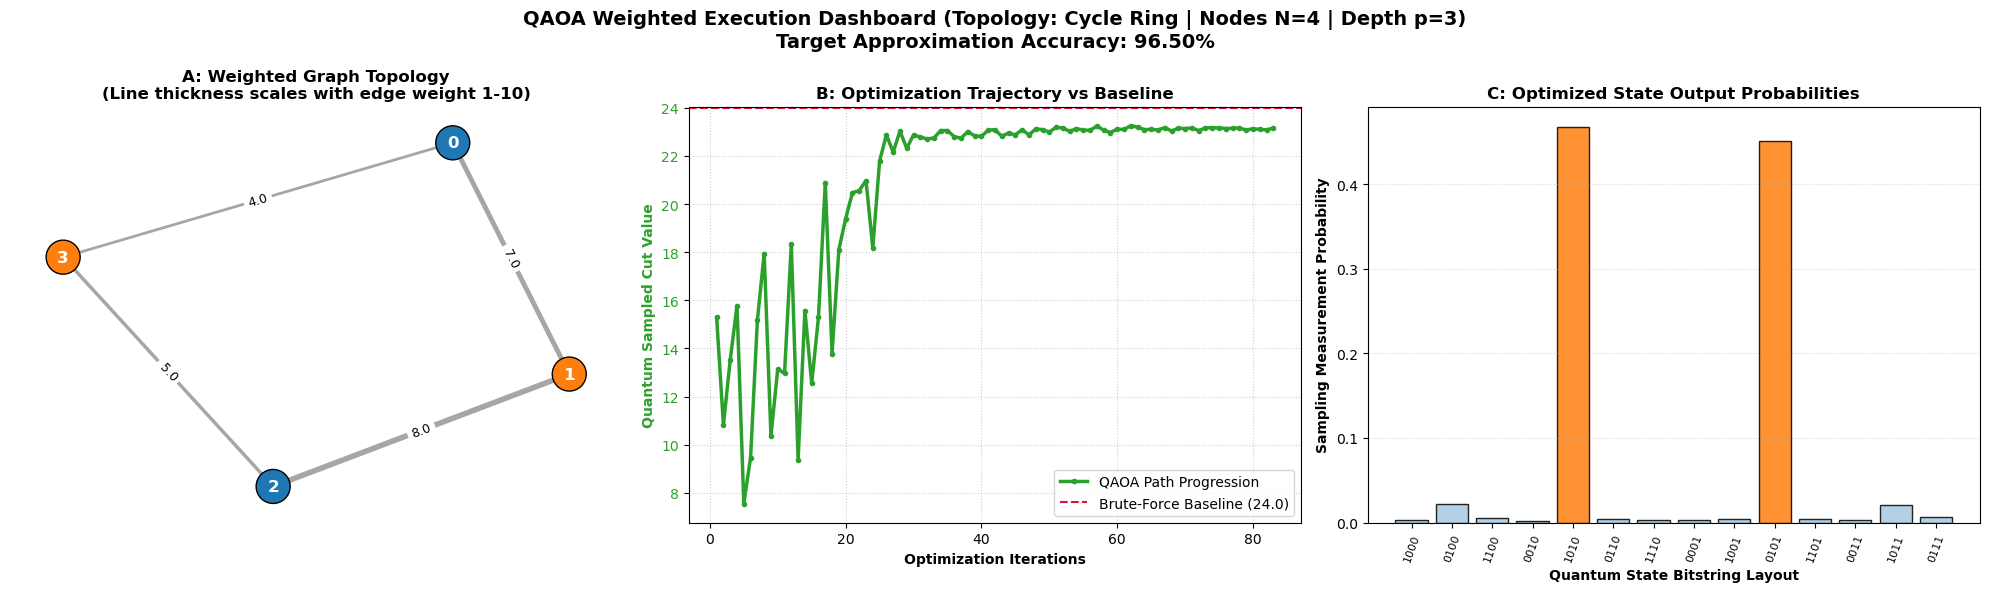

In [48]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator

print("=================================================================")
print(" PRODUCTION-GRADE QAOA SUITE: WEIGHTED GRAPH SYSTEM DASHBOARD   ")
print("=================================================================\n")

# 1. Advanced Graph Selection Profile (Geometric & Algorithmic Graphs)
print("Select Graph Topology Type:")
print("1. Cycle Graph (Connected Loop Ring)")
print("2. Random Disordered Graph (Erdos-Renyi)")
print("3. Random Geometric Graph (Spatial Proximity Connection)")
print("4. Barabasi-Albert Algorithmic Graph (Scale-Free Network)")
graph_choice = input("Enter choice (1, 2, 3, or 4): ").strip()

num_nodes = int(input("Enter number of nodes/spins (2 to 10): ").strip())
if num_nodes < 2 or num_nodes > 10:
    print("Warning: Bounds forced inside stable sandbox spectrum (Reset to N=6)")
    num_nodes = 6

# Initialize Topology
G = nx.Graph()
if graph_choice == "1":
    print(f"-> Generating Cycle Graph...")
    G = nx.cycle_graph(num_nodes)
elif graph_choice == "2":
    print(f"-> Generating Random Disordered Graph...")
    G = nx.fast_gnp_random_graph(num_nodes, p=0.5, seed=42)
elif graph_choice == "3":
    radius_val = float(input("Enter geometric connection radius (0.1 to 1.0, e.g., 0.5): ").strip())
    print(f"-> Generating Geometric Graph...")
    G = nx.random_geometric_graph(num_nodes, radius=radius_val, seed=42)
elif graph_choice == "4":
    m_edges = int(input(f"Enter number of edges to attach from a new node (1 to {num_nodes-1}): ").strip())
    print(f"-> Generating Algorithmic Scale-Free Graph...")
    G = nx.barabasi_albert_graph(num_nodes, m=m_edges, seed=42)
else:
    G = nx.cycle_graph(num_nodes)

# Assign RANDOM EDGE WEIGHTS from 1 to 10
np.random.seed(42)
for u, v in G.edges():
    G[u][v]['weight'] = float(np.random.randint(1, 11)) # Random integer 1 to 10

# 2. Compute the EXACT Weighted Maximum Cut (Brute-Force Baseline)
best_cost_exact = 0
best_bitstrings = []
for i in range(2**num_nodes):
    bitstr = format(i, f'0{num_nodes}b')
    current_cut_weight = 0
    for u, v, d in G.edges(data=True):
        if bitstr[u] != bitstr[v]: # Cut condition
            current_cut_weight += d['weight']
    if current_cut_weight > best_cost_exact:
        best_cost_exact = current_cut_weight
        best_bitstrings = [bitstr]
    elif current_cut_weight == best_cost_exact:
        best_bitstrings.append(bitstr)

# Map the Weighted Max-Cut problem to an Ising Hamiltonian Cost Function
pauli_list = []
for u, v, d in G.edges(data=True):
    pauli_str = list("I" * num_nodes)
    pauli_str[u] = "Z"
    pauli_str[v] = "Z"
    # Weight directly influences the energy coefficient
    pauli_list.append(("".join(pauli_str), -0.5 * d['weight']))
hamiltonian = SparsePauliOp.from_list(pauli_list)

constant_offset = 0.5 * sum(d['weight'] for u, v, d in G.edges(data=True))

# 3. Parameter Inputs for Circuit Configuration
p_depth = int(input("\nEnter QAOA circuit depth Layer p (1 to 5): ").strip())
if p_depth < 1 or p_depth > 5: p_depth = 1

max_shots = int(input("Enter measurement execution shots (100 to 4000): ").strip())
max_iters = int(input("Enter max classical optimizer iterations (100 to 4000): ").strip())

# 4. Choose Classical Target Optimizer Framework
print("\nSelect Classical Core Optimizer Method:")
print("1. COBYLA\n2. Nelder-Mead\n3. SLSQP")
opt_choice = input("Enter choice (1, 2, or 3): ").strip()
optimizer_method = "COBYLA" if opt_choice == "1" else ("Nelder-Mead" if opt_choice == "2" else "SLSQP")

# 5. Define Parameterized QAOA Execution Circuit Generator
def generate_qaoa_circuit(params, depth, nodes, graph):
    gammas = params[:depth]
    betas = params[depth:]
    
    qc = QuantumCircuit(nodes)
    qc.h(range(nodes)) 
    
    for layer in range(depth):
        for u, v, d in graph.edges(data=True):
            w = d['weight']
            qc.cx(u, v)
            qc.rz(2 * gammas[layer] * (-0.5 * w), v) # Dynamically scales with the edge weight
            qc.cx(u, v)
        qc.rx(2 * betas[layer], range(nodes))
        
    qc.measure_all()
    return qc

# 6. Cost Objective Function Tracker with Live Status Reporting
simulator = AerSimulator()
iteration_history = []
energy_history = []

def cost_objective(params):
    circuit = generate_qaoa_circuit(params, p_depth, num_nodes, G)
    result = simulator.run(circuit, shots=max_shots).result()
    counts = result.get_counts()
    
    total_hamiltonian_energy = 0
    for bitstr, count in counts.items():
        bitstr = bitstr[::-1] 
        string_energy = 0
        for u, v, d in G.edges(data=True):
            w = d['weight']
            spin_u = 1 if bitstr[u] == '0' else -1
            spin_v = 1 if bitstr[v] == '0' else -1
            string_energy += -0.5 * w * spin_u * spin_v
        total_hamiltonian_energy += string_energy * (count / max_shots)
        
    current_max_cut_val = constant_offset + total_hamiltonian_energy
    current_iter = len(iteration_history) + 1
    iteration_history.append(current_iter)
    energy_history.append(current_max_cut_val)
    
    if current_iter % 5 == 0 or current_iter == 1:
        print(f"  [Iteration {current_iter:03d}] Current Evaluated Cut Weight: {current_max_cut_val:.4f}")
        
    return -current_max_cut_val 

# 7. Start Classical Optimization Run Loop
print("\n-> Activating Classical Optimization Loop Engine...")
initial_parameters = [0.1] * (2 * p_depth)
res = minimize(cost_objective, initial_parameters, method=optimizer_method, options={'maxiter': max_iters})

# Final calculated stats extraction
optimized_params = res.x
final_gammas = optimized_params[:p_depth]
final_betas = optimized_params[p_depth:]
final_estimated_max_cut = -res.fun
approximation_ratio = final_estimated_max_cut / best_cost_exact if best_cost_exact > 0 else 1.0

# 8. Output Complete Metrics Reports
print("\n" + "="*57)
print("                 FINAL SIMULATION SUMMARY                ")
print("="*57)
print(f"Topology Pattern Choice  : {['Cycle','Random','Geometric','Barabasi-Albert'][int(graph_choice)-1]}")
print(f"Target Nodes Count (N)   : {num_nodes}")
print(f"Total Algorithm Steps    : {res.nfev}")
print(f"\nExact True Max Cut Weight: {best_cost_exact:.4f} (Solutions: {best_bitstrings})")
print(f"QAOA Sampled Max Cut     : {final_estimated_max_cut:.4f}")
print(f"APPROXIMATION RATIO (α)  : {approximation_ratio:.4f} ({(approximation_ratio*100):.2f}%)")
print("=========================================================\n")

# 9. Generate Complete Three-Panel Portfolio Dashboard
print("-> Compiling multi-panel graphic visualization dashboard...")
fig = plt.figure(figsize=(20, 6))

# Determine node colors based on the first optimal bitstring solution found
optimal_cut_string = best_bitstrings[0]
node_colors = ['#ff7f0e' if optimal_cut_string[node] == '1' else '#1f77b4' for node in G.nodes()]

# Extract edge weights to set line thicknesses dynamically in the graph plot
weights = [G[u][v]['weight'] for u, v in G.edges()]
normalized_thickness = [w / 2.0 for w in weights] # Scale down slightly so lines don't get overly fat

# Panel A: Weighted Topology Pattern Graph Visualization
ax1 = fig.add_subplot(1, 3, 1)
pos = nx.spring_layout(G, seed=42) if graph_choice != "3" else nx.get_node_attributes(G, 'pos')
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=600, node_color=node_colors, edgecolors='black')
nx.draw_networkx_edges(G, pos, ax=ax1, width=normalized_thickness, alpha=0.7, edge_color='gray')
nx.draw_networkx_labels(G, pos, ax=ax1, font_size=12, font_color='white', font_weight='bold')
# Overlay textual edge weight numbers on the lines
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax1, font_size=9)

ax1.set_title("A: Weighted Graph Topology\n(Line thickness scales with edge weight 1-10)", fontweight='bold')
ax1.axis('off')

# Panel B: Optimization Trajectory Line Graph
ax2 = fig.add_subplot(1, 3, 2)
color_track = '#2ca02c'
ax2.set_xlabel('Optimization Iterations', fontweight='bold')
ax2.set_ylabel('Quantum Sampled Cut Value', color=color_track, fontweight='bold')
ax2.plot(iteration_history, energy_history, color=color_track, linewidth=2.5, marker='.', label='QAOA Path Progression')
ax2.axhline(y=best_cost_exact, color='crimson', linestyle='--', linewidth=1.5, label=f'Brute-Force Baseline ({best_cost_exact})')
ax2.tick_params(axis='y', labelcolor=color_track)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='lower right')
ax2.set_title("B: Optimization Trajectory vs Baseline", fontweight='bold')

# Panel C: Final Quantum State Bitstring Probabilities
ax3 = fig.add_subplot(1, 3, 3)
optimal_circuit = generate_qaoa_circuit(optimized_params, p_depth, num_nodes, G)
final_counts = simulator.run(optimal_circuit, shots=max_shots).result().get_counts()

sorted_keys = sorted(final_counts.keys())
sorted_probabilities = [final_counts[k] / max_shots for k in sorted_keys]
cleaned_keys = [k[::-1] for k in sorted_keys]

bar_colors = ['#ff7f0e' if k in best_bitstrings else '#a6c8e0' for k in cleaned_keys]
ax3.bar(cleaned_keys, sorted_probabilities, color=bar_colors, edgecolor='black', alpha=0.85)
ax3.set_xlabel('Quantum State Bitstring Layout', fontweight='bold')
ax3.set_ylabel('Sampling Measurement Probability', fontweight='bold')
ax3.set_title("C: Optimized State Output Probabilities", fontweight='bold')
ax3.tick_params(axis='x', rotation=70, labelsize=8)
ax3.grid(axis='y', linestyle=':', alpha=0.5)

# Final Layout Render and Save File
graph_type_name = ['Cycle Ring', 'Random Erdos-Renyi', 'Spatial Geometric', 'Barabasi-Albert Scale-Free'][int(graph_choice)-1]
plt.suptitle(f"QAOA Weighted Execution Dashboard (Topology: {graph_type_name} | Nodes N={num_nodes} | Depth p={p_depth})\nTarget Approximation Accuracy: {approximation_ratio*100:.2f}%", fontweight='bold', fontsize=14)
fig.tight_layout()

output_filename = "qaoa_weighted_topology_dashboard.png"
plt.savefig(output_filename, dpi=300)
print(f"✔ Portfolio Dashboard graphic exported safely to: '{output_filename}'")
plt.show()

 PRODUCTION-GRADE QAOA: MULTI-ALGORITHM & SHOT BENCHMARK SUITE 

Select Graph Topology Type:
1. Cycle Graph
2. Random Disordered Graph
3. Random Geometric Graph
4. Barabasi-Albert Graph


Enter choice (1, 2, 3, or 4):  1
Enter number of nodes/spins (2 to 10):  4



-> Running QAOA Shot Variance Benchmarks...
   Executing Benchmark Level 1: Compiling QAOA with 100 Shots...
   Executing Benchmark Level 2: Compiling QAOA with 500 Shots...
   Executing Benchmark Level 3: Compiling QAOA with 1000 Shots...
   Executing Benchmark Level 4: Compiling QAOA with 2000 Shots...
   Executing Benchmark Level 5: Compiling QAOA with 4000 Shots...

             MULTI-ALGORITHM BENCHMARK LOG DATA              
Exact Classical Brute-Force Maximum Cut : 24.0000
Classical Random Sampling Average Cut  : 12.2080
-----------------------------------------------------------------
Shot Configuration Run   QAOA Cut Output Value    Approximation Ratio (α)
-----------------------------------------------------------------
Level 1 (100  Shots)          17.4800                  0.7283
Level 2 (500  Shots)          18.0840                  0.7535
Level 3 (1000 Shots)          17.4150                  0.7256
Level 4 (2000 Shots)          17.3470                  0.7228
Level 5 (40

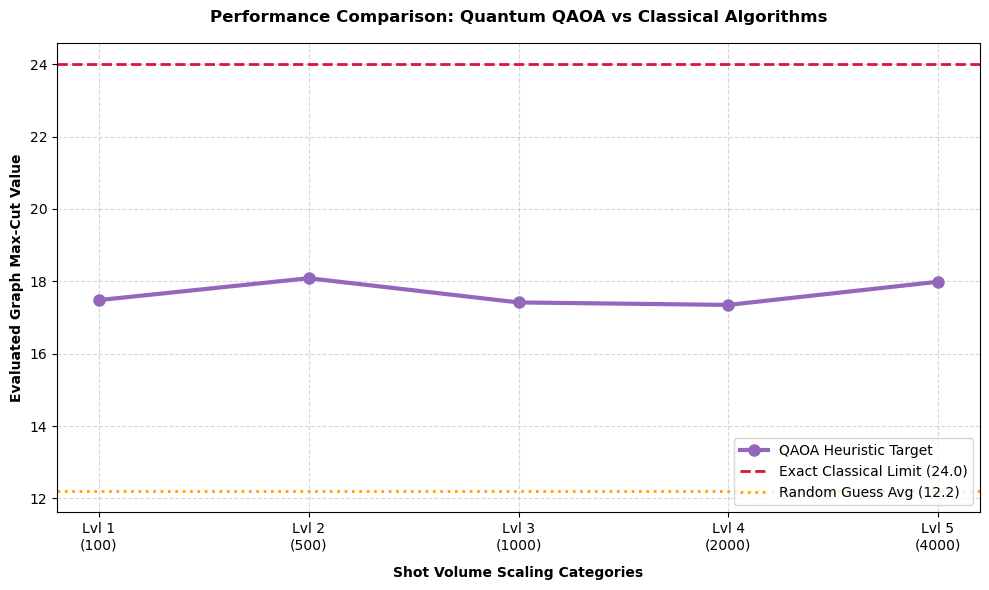

In [61]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator

print("=================================================================")
print(" PRODUCTION-GRADE QAOA: MULTI-ALGORITHM & SHOT BENCHMARK SUITE ")
print("=================================================================\n")

# 1. Topology Configuration
print("Select Graph Topology Type:")
print("1. Cycle Graph\n2. Random Disordered Graph\n3. Random Geometric Graph\n4. Barabasi-Albert Graph")
graph_choice = input("Enter choice (1, 2, 3, or 4): ").strip()

num_nodes = int(input("Enter number of nodes/spins (2 to 10): ").strip())
if num_nodes < 2 or num_nodes > 10:
    num_nodes = 6

G = nx.Graph()
if graph_choice == "1":
    G = nx.cycle_graph(num_nodes)
elif graph_choice == "2":
    G = nx.fast_gnp_random_graph(num_nodes, p=0.5, seed=42)
elif graph_choice == "3":
    radius_val = float(input("Enter radius (e.g., 0.5): ").strip())
    G = nx.random_geometric_graph(num_nodes, radius=radius_val, seed=42)
elif graph_choice == "4":
    m_edges = int(input(f"Enter edges to attach (1 to {num_nodes-1}): ").strip())
    G = nx.barabasi_albert_graph(num_nodes, m=m_edges, seed=42)
else:
    G = nx.cycle_graph(num_nodes)

# Assign random edge weights (1 to 10)
np.random.seed(42)
for u, v in G.edges():
    G[u][v]['weight'] = float(np.random.randint(1, 11))

# 2. ALGORITHM 1: Exact Classical Brute-Force Baseline
best_cost_exact = 0
for i in range(2**num_nodes):
    bitstr = format(i, f'0{num_nodes}b')
    current_cut_weight = 0
    for u, v, d in G.edges(data=True):
        if bitstr[u] != bitstr[v]:
            current_cut_weight += d['weight']
    if current_cut_weight > best_cost_exact:
        best_cost_exact = current_cut_weight

# 3. ALGORITHM 2: Pure Classical Random Sampling Baseline
np.random.seed(42)
random_sample_runs = 500
random_cut_energies = []
for _ in range(random_sample_runs):
    random_bitstr = "".join(np.random.choice(['0', '1'], size=num_nodes))
    current_cut_weight = 0
    for u, v, d in G.edges(data=True):
        if random_bitstr[u] != random_bitstr[v]:
            current_cut_weight += d['weight']
    random_cut_energies.append(current_cut_weight)
average_random_cut = np.mean(random_cut_energies)

# 4. Map to Ising Hamiltonian for QAOA
constant_offset = 0.5 * sum(d['weight'] for u, v, d in G.edges(data=True))

def generate_qaoa_circuit(params, depth, nodes, graph):
    gammas = params[:depth]
    betas = params[depth:]
    qc = QuantumCircuit(nodes)
    qc.h(range(nodes))
    for layer in range(depth):
        for u, v, d in graph.edges(data=True):
            w = d['weight']
            qc.cx(u, v)
            qc.rz(2 * gammas[layer] * (-0.5 * w), v)
            qc.cx(u, v)
        qc.rx(2 * betas[layer], range(nodes))
    qc.measure_all()
    return qc

simulator = AerSimulator()

# Core QAOA Objective function dynamically altering target shot count
def cost_objective(params, current_shots):
    # FIXED: keyword argument is now 'depth=1' to match generate_qaoa_circuit definition
    circuit = generate_qaoa_circuit(params, depth=1, nodes=num_nodes, graph=G)
    result = simulator.run(circuit, shots=current_shots).result()
    counts = result.get_counts()
    
    total_hamiltonian_energy = 0
    for bitstr, count in counts.items():
        bitstr = bitstr[::-1]
        string_energy = 0
        for u, v, d in G.edges(data=True):
            w = d['weight']
            spin_u = 1 if bitstr[u] == '0' else -1
            spin_v = 1 if bitstr[v] == '0' else -1
            string_energy += -0.5 * w * spin_u * spin_v
        total_hamiltonian_energy += string_energy * (count / current_shots)
        
    return -(constant_offset + total_hamiltonian_energy)

# 5. Run Benchmark across Shot Array (Levels 1 to 5)
shot_options = [100, 500, 1000, 2000, 4000]
qaoa_results_per_shot = []

print("\n-> Running QAOA Shot Variance Benchmarks...")
initial_parameters = [0.1, 0.1] # p=1 setup

for idx, shots in enumerate(shot_options):
    print(f"   Executing Benchmark Level {idx+1}: Compiling QAOA with {shots} Shots...")
    res = minimize(cost_objective, initial_parameters, args=(shots,), method="COBYLA", options={'maxiter': 100})
    final_qaoa_cut_val = -res.fun
    qaoa_results_per_shot.append(final_qaoa_cut_val)

# 6. Output Summary Report Table
print("\n" + "="*65)
print("             MULTI-ALGORITHM BENCHMARK LOG DATA              ")
print("="*65)
print(f"Exact Classical Brute-Force Maximum Cut : {best_cost_exact:.4f}")
print(f"Classical Random Sampling Average Cut  : {average_random_cut:.4f}")
print("-" * 65)
print(f"{'Shot Configuration Run':<25}{'QAOA Cut Output Value':<25}{'Approximation Ratio (α)'}")
print("-" * 65)
for i, shots in enumerate(shot_options):
    alpha = qaoa_results_per_shot[i] / best_cost_exact if best_cost_exact > 0 else 1.0
    print(f"Level {i+1} ({shots:<4} Shots)          {qaoa_results_per_shot[i]:<25.4f}{alpha:.4f}")
print("=================================================================\n")

# 7. Generate Comparison Dashboard Graph
print("-> Compiling final algorithm comparison charts...")
plt.figure(figsize=(10, 6))

x_labels = ["Lvl 1\n(100)","Lvl 2\n(500)","Lvl 3\n(1000)","Lvl 4\n(2000)","Lvl 5\n(4000)"]

# Plot QAOA values scaling over shots
plt.plot(x_labels, qaoa_results_per_shot, marker='o', color='#9467bd', linewidth=3, markersize=8, label='QAOA Heuristic Target')

# Plot Classical Baselines for explicit horizontal comparison
plt.axhline(y=best_cost_exact, color='crimson', linestyle='--', linewidth=2, label=f'Exact Classical Limit ({best_cost_exact})')
plt.axhline(y=average_random_cut, color='orange', linestyle=':', linewidth=2, label=f'Random Guess Avg ({average_random_cut:.1f})')

plt.xlabel('Shot Volume Scaling Categories', fontweight='bold', labelpad=10)
plt.ylabel('Evaluated Graph Max-Cut Value', fontweight='bold')
plt.title('Performance Comparison: Quantum QAOA vs Classical Algorithms', fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()

output_filename = "qaoa_algorithm_shot_comparison.png"
plt.savefig(output_filename, dpi=300)
print(f"✔ Multi-algorithm benchmark visualization exported safely to: '{output_filename}'")
plt.show()

   THE ULTIMATE QAOA PERFORMANCE ENGINE & VISUAL SUITE           

Select Graph Topology Type:
1. Cycle Graph (Connected Loop Ring)
2. Random Disordered Graph (Erdos-Renyi)
3. Random Geometric Graph (Spatial Proximity Connection)
4. Barabasi-Albert Algorithmic Graph (Scale-Free Network)


Enter choice (1, 2, 3, or 4):  1
Enter number of nodes/spins (2 to 10):  4


-> Generating Cycle Graph...



Enter QAOA circuit depth Layer p (1 to 5):  3
Enter max classical optimizer iterations (100 to 4000):  2000



Select Classical Core Optimizer Method:
1. COBYLA
2. Nelder-Mead
3. SLSQP


Enter choice (1, 2, or 3):  1



-> Activating Shot Variance & Multi-Algorithm Optimization Loops...

⚡ Running Benchmark Level 1 with 100 Shots...

⚡ Running Benchmark Level 2 with 500 Shots...

⚡ Running Benchmark Level 3 with 1000 Shots...

⚡ Running Benchmark Level 4 with 2000 Shots...

⚡ Running Benchmark Level 5 with 4000 Shots...
  [Optimizer Step 001] Evaluated Cut Weight: 15.2067
  [Optimizer Step 005] Evaluated Cut Weight: 7.5322
  [Optimizer Step 010] Evaluated Cut Weight: 7.7267
  [Optimizer Step 015] Evaluated Cut Weight: 18.0360
  [Optimizer Step 020] Evaluated Cut Weight: 13.7605
  [Optimizer Step 025] Evaluated Cut Weight: 21.9258
  [Optimizer Step 030] Evaluated Cut Weight: 22.6585
  [Optimizer Step 035] Evaluated Cut Weight: 22.6652
  [Optimizer Step 040] Evaluated Cut Weight: 22.7230
  [Optimizer Step 045] Evaluated Cut Weight: 22.6788
  [Optimizer Step 050] Evaluated Cut Weight: 22.6575
  [Optimizer Step 055] Evaluated Cut Weight: 22.7323
  [Optimizer Step 060] Evaluated Cut Weight: 22.7365
  [Opt

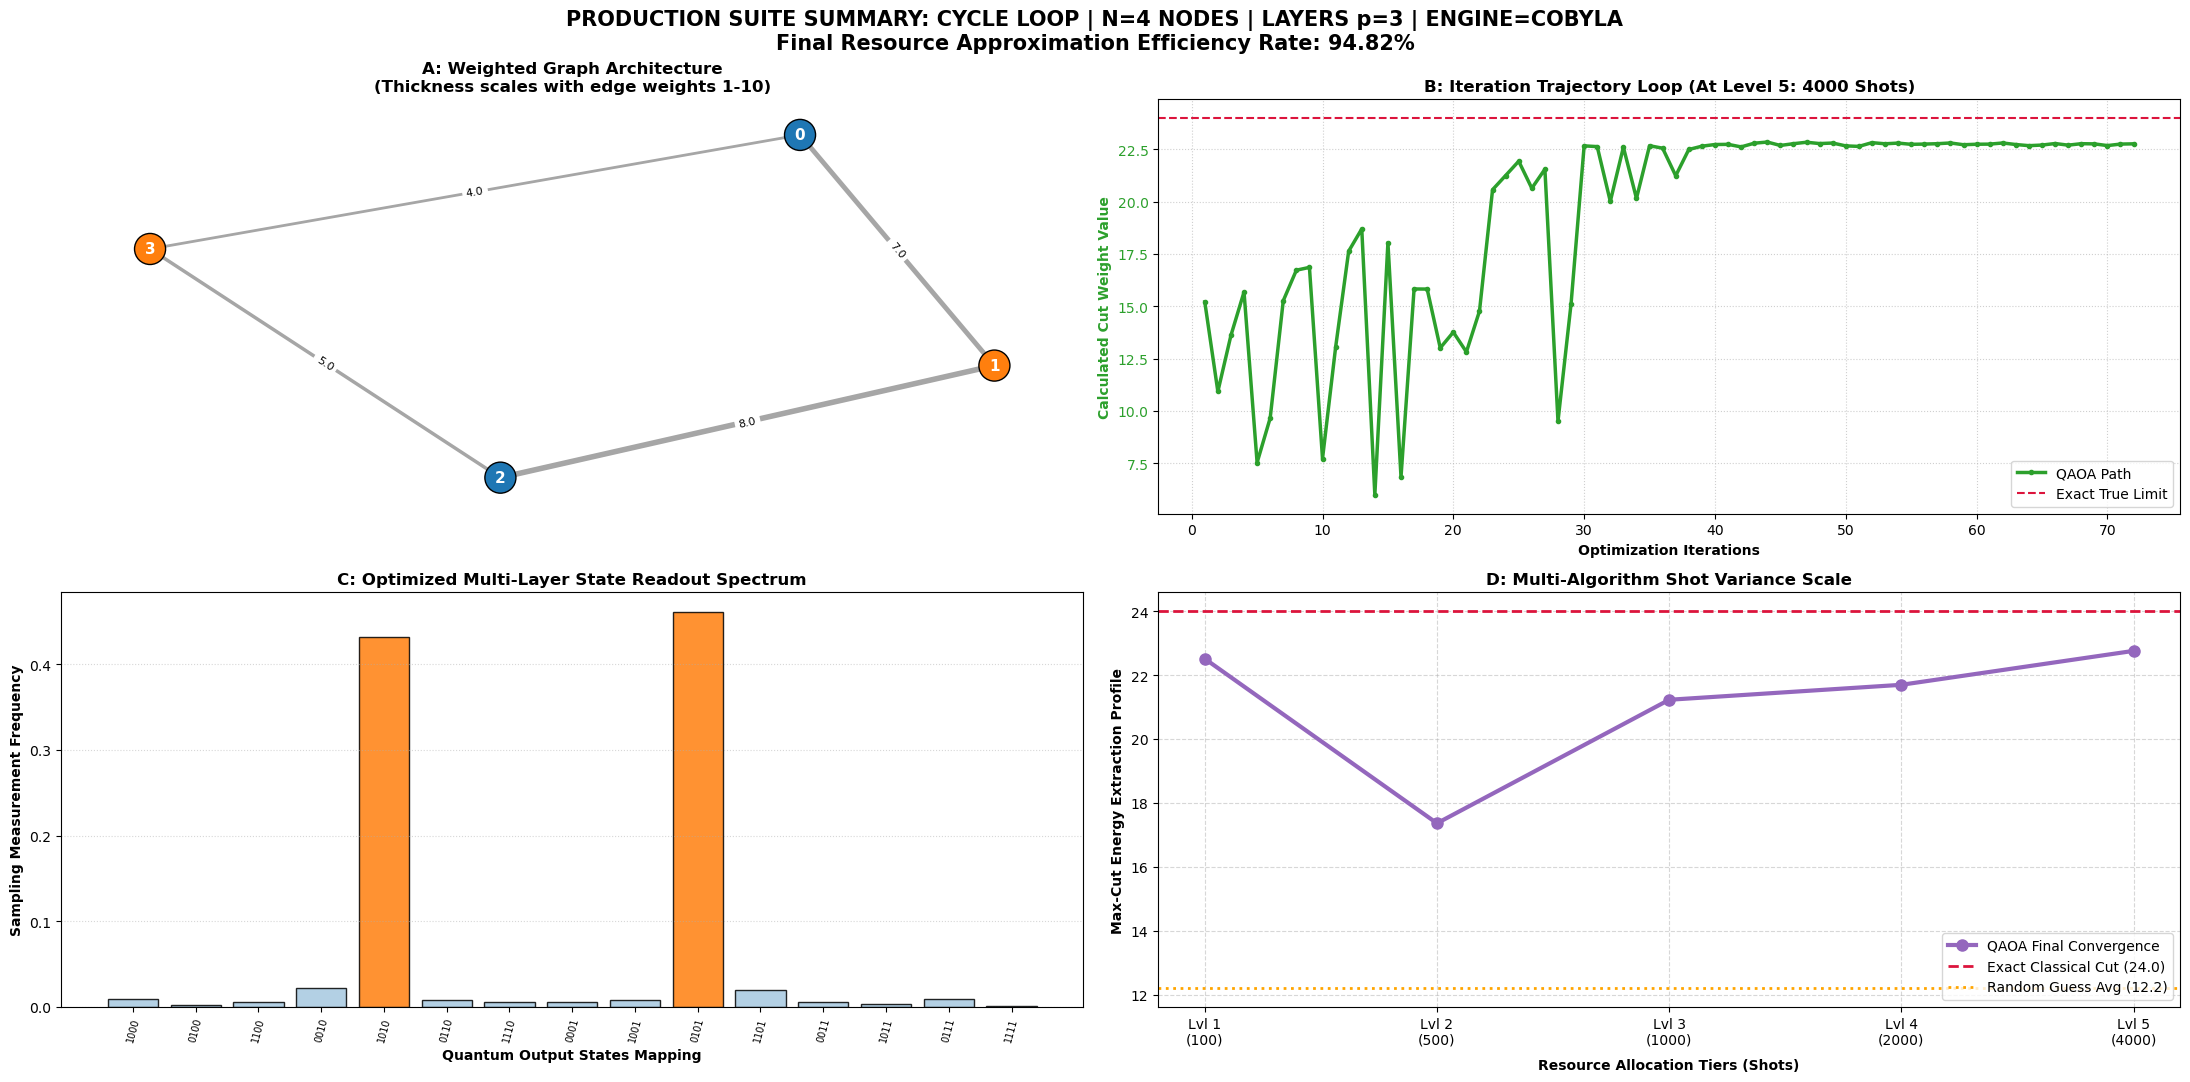

In [63]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator

print("=================================================================")
print("   THE ULTIMATE QAOA PERFORMANCE ENGINE & VISUAL SUITE           ")
print("=================================================================\n")

# 1. Advanced Graph Selection Profile (Geometric & Algorithmic Graphs)
print("Select Graph Topology Type:")
print("1. Cycle Graph (Connected Loop Ring)")
print("2. Random Disordered Graph (Erdos-Renyi)")
print("3. Random Geometric Graph (Spatial Proximity Connection)")
print("4. Barabasi-Albert Algorithmic Graph (Scale-Free Network)")
graph_choice = input("Enter choice (1, 2, 3, or 4): ").strip()

num_nodes = int(input("Enter number of nodes/spins (2 to 10): ").strip())
if num_nodes < 2 or num_nodes > 10:
    print("Warning: Resetting node scale to stable default (N=6)")
    num_nodes = 6

# Initialize Topology
G = nx.Graph()
if graph_choice == "1":
    print(f"-> Generating Cycle Graph...")
    G = nx.cycle_graph(num_nodes)
elif graph_choice == "2":
    print(f"-> Generating Random Disordered Graph...")
    G = nx.fast_gnp_random_graph(num_nodes, p=0.5, seed=42)
elif graph_choice == "3":
    radius_val = float(input("Enter geometric connection radius (0.1 to 1.0, e.g., 0.5): ").strip())
    print(f"-> Generating Geometric Graph...")
    G = nx.random_geometric_graph(num_nodes, radius=radius_val, seed=42)
elif graph_choice == "4":
    m_edges = int(input(f"Enter number of edges to attach from a new node (1 to {num_nodes-1}): ").strip())
    print(f"-> Generating Algorithmic Scale-Free Graph...")
    G = nx.barabasi_albert_graph(num_nodes, m=m_edges, seed=42)
else:
    G = nx.cycle_graph(num_nodes)

# Assign RANDOM EDGE WEIGHTS from 1 to 10
np.random.seed(42)
for u, v in G.edges():
    G[u][v]['weight'] = float(np.random.randint(1, 11))

# 2. ALGORITHM 1: Exact Classical Brute-Force Baseline & Best Bitstrings
best_cost_exact = 0
best_bitstrings = []
for i in range(2**num_nodes):
    bitstr = format(i, f'0{num_nodes}b')
    current_cut_weight = 0
    for u, v, d in G.edges(data=True):
        if bitstr[u] != bitstr[v]:
            current_cut_weight += d['weight']
    if current_cut_weight > best_cost_exact:
        best_cost_exact = current_cut_weight
        best_bitstrings = [bitstr]
    elif current_cut_weight == best_cost_exact:
        best_bitstrings.append(bitstr)

# 3. ALGORITHM 2: Pure Classical Random Sampling Baseline
np.random.seed(42)
random_sample_runs = 500
random_cut_energies = []
for _ in range(random_sample_runs):
    random_bitstr = "".join(np.random.choice(['0', '1'], size=num_nodes))
    current_cut_weight = 0
    for u, v, d in G.edges(data=True):
        if random_bitstr[u] != random_bitstr[v]:
            current_cut_weight += d['weight']
    random_cut_energies.append(current_cut_weight)
average_random_cut = np.mean(random_cut_energies)

# 4. Map the Max-Cut problem to an Ising Hamiltonian Cost Function
constant_offset = 0.5 * sum(d['weight'] for u, v, d in G.edges(data=True))

# Circuit Configuration Parameters
p_depth = int(input("\nEnter QAOA circuit depth Layer p (1 to 5): ").strip())
if p_depth < 1 or p_depth > 5: p_depth = 1

max_iters = int(input("Enter max classical optimizer iterations (100 to 4000): ").strip())

print("\nSelect Classical Core Optimizer Method:")
print("1. COBYLA\n2. Nelder-Mead\n3. SLSQP")
opt_choice = input("Enter choice (1, 2, or 3): ").strip()
optimizer_method = "COBYLA" if opt_choice == "1" else ("Nelder-Mead" if opt_choice == "2" else "SLSQP")

def generate_qaoa_circuit(params, depth, nodes, graph):
    gammas = params[:depth]
    betas = params[depth:]
    qc = QuantumCircuit(nodes)
    qc.h(range(nodes))
    for layer in range(depth):
        for u, v, d in graph.edges(data=True):
            w = d['weight']
            qc.cx(u, v)
            qc.rz(2 * gammas[layer] * (-0.5 * w), v)
            qc.cx(u, v)
        qc.rx(2 * betas[layer], range(nodes))
    qc.measure_all()
    return qc

simulator = AerSimulator()

# Trackers for the specific visualization of the largest shot run loop
iteration_history = []
energy_history = []

# Core QAOA Objective function dynamically altering target shot count
def cost_objective(params, current_shots, track_metrics=False):
    circuit = generate_qaoa_circuit(params, depth=p_depth, nodes=num_nodes, graph=G)
    result = simulator.run(circuit, shots=current_shots).result()
    counts = result.get_counts()
    
    total_hamiltonian_energy = 0
    for bitstr, count in counts.items():
        bitstr = bitstr[::-1]
        string_energy = 0
        for u, v, d in G.edges(data=True):
            w = d['weight']
            spin_u = 1 if bitstr[u] == '0' else -1
            spin_v = 1 if bitstr[v] == '0' else -1
            string_energy += -0.5 * w * spin_u * spin_v
        total_hamiltonian_energy += string_energy * (count / current_shots)
        
    current_max_cut_val = constant_offset + total_hamiltonian_energy
    
    if track_metrics:
        current_iter = len(iteration_history) + 1
        iteration_history.append(current_iter)
        energy_history.append(current_max_cut_val)
        if current_iter % 5 == 0 or current_iter == 1:
            print(f"  [Optimizer Step {current_iter:03d}] Evaluated Cut Weight: {current_max_cut_val:.4f}")
            
    return -current_max_cut_val

# 5. Run Benchmark across Shot Tiers (Levels 1 to 5)
shot_options = [100, 500, 1000, 2000, 4000]
qaoa_results_per_shot = []
saved_optimized_params = None

print("\n-> Activating Shot Variance & Multi-Algorithm Optimization Loops...")
for idx, shots in enumerate(shot_options):
    print(f"\n⚡ Running Benchmark Level {idx+1} with {shots} Shots...")
    initial_parameters = [0.1] * (2 * p_depth)
    
    # Track iteration path details explicitly during the highest shot volume run (Level 5)
    is_highest_shot = (shots == 4000)
    
    res = minimize(
        cost_objective, 
        initial_parameters, 
        args=(shots, is_highest_shot), 
        method=optimizer_method, 
        options={'maxiter': max_iters}
    )
    
    final_qaoa_cut_val = -res.fun
    qaoa_results_per_shot.append(final_qaoa_cut_val)
    
    if is_highest_shot:
        saved_optimized_params = res.x

# Final calculated parameter stats extraction
final_gammas = saved_optimized_params[:p_depth]
final_betas = saved_optimized_params[p_depth:]
approximation_ratio = qaoa_results_per_shot[-1] / best_cost_exact if best_cost_exact > 0 else 1.0

# 6. Output Summary Logs
print("\n" + "="*65)
print("                 FINAL PERFORMANCE METRICS SUMMARY               ")
print("="*65)
print(f"Graph Topology Profile : {['Cycle','Random','Geometric','Barabasi-Albert'][int(graph_choice)-1]}")
print(f"Target System Scale    : {num_nodes} Qubits / Nodes")
print(f"Classical Engine Used  : {optimizer_method}")
print(f"\nFinal Optimized Angles (From Level 5 Peak Run):")
for l in range(p_depth):
    print(f"  Layer {l+1} -> Optimal Gamma (γ): {final_gammas[l]:.4f} | Optimal Beta (β): {final_betas[l]:.4f}")
print(f"\nExact Classical True Max Cut Weight : {best_cost_exact:.4f}")
print(f"Classical Random Guessing Avg Cut   : {average_random_cut:.4f}")
print(f"Peak QAOA Performance (4000 Shots)  : {qaoa_results_per_shot[-1]:.4f}")
print(f"FINAL APPROXIMATION RATIO (α)       : {approximation_ratio:.4f} ({(approximation_ratio*100):.2f}%)")
print("=================================================================\n")

# 7. Generate Complete Four-Panel Professional Portfolio Dashboard
print("-> Compiling comprehensive four-panel analytical dashboard plots...")
fig = plt.figure(figsize=(22, 11))

# --- PANEL 1: Weighted Topology Pattern Graph ---
ax1 = fig.add_subplot(2, 2, 1)
optimal_cut_string = best_bitstrings[0]
node_colors = ['#ff7f0e' if optimal_cut_string[node] == '1' else '#1f77b4' for node in G.nodes()]
weights = [G[u][v]['weight'] for u, v in G.edges()]
normalized_thickness = [w / 2.0 for w in weights]
pos = nx.spring_layout(G, seed=42) if graph_choice != "3" else nx.get_node_attributes(G, 'pos')

nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=500, node_color=node_colors, edgecolors='black')
nx.draw_networkx_edges(G, pos, ax=ax1, width=normalized_thickness, alpha=0.7, edge_color='gray')
nx.draw_networkx_labels(G, pos, ax=ax1, font_size=11, font_color='white', font_weight='bold')
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax1, font_size=8)
ax1.set_title("A: Weighted Graph Architecture\n(Thickness scales with edge weights 1-10)", fontweight='bold')
ax1.axis('off')

# --- PANEL 2: Optimization Convergence Trajectory (For Peak Run) ---
ax2 = fig.add_subplot(2, 2, 2)
ax2.set_xlabel('Optimization Iterations', fontweight='bold')
ax2.set_ylabel('Calculated Cut Weight Value', color='#2ca02c', fontweight='bold')
ax2.plot(iteration_history, energy_history, color='#2ca02c', linewidth=2.5, marker='.', label='QAOA Path')
ax2.axhline(y=best_cost_exact, color='crimson', linestyle='--', linewidth=1.5, label='Exact True Limit')
ax2.tick_params(axis='y', labelcolor='#2ca02c')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='lower right')
ax2.set_title("B: Iteration Trajectory Loop (At Level 5: 4000 Shots)", fontweight='bold')

# --- PANEL 3: Final Quantum State Configuration Probabilities ---
ax3 = fig.add_subplot(2, 2, 3)
peak_circuit = generate_qaoa_circuit(saved_optimized_params, depth=p_depth, nodes=num_nodes, graph=G)
final_counts = simulator.run(peak_circuit, shots=4000).result().get_counts()
sorted_keys = sorted(final_counts.keys())
sorted_probabilities = [final_counts[k] / 4000 for k in sorted_keys]
cleaned_keys = [k[::-1] for k in sorted_keys]
bar_colors = ['#ff7f0e' if k in best_bitstrings else '#a6c8e0' for k in cleaned_keys]

ax3.bar(cleaned_keys, sorted_probabilities, color=bar_colors, edgecolor='black', alpha=0.85)
ax3.set_xlabel('Quantum Output States Mapping', fontweight='bold')
ax3.set_ylabel('Sampling Measurement Frequency', fontweight='bold')
ax3.set_title("C: Optimized Multi-Layer State Readout Spectrum", fontweight='bold')
ax3.tick_params(axis='x', rotation=75, labelsize=7)
ax3.grid(axis='y', linestyle=':', alpha=0.5)

# --- PANEL 4: Comparative Shot Variance Benchmark Scale ---
ax4 = fig.add_subplot(2, 2, 4)
shot_labels = ["Lvl 1\n(100)","Lvl 2\n(500)","Lvl 3\n(1000)","Lvl 4\n(2000)","Lvl 5\n(4000)"]
ax4.plot(shot_labels, qaoa_results_per_shot, marker='o', color='#9467bd', linewidth=3, markersize=8, label='QAOA Final Convergence')
ax4.axhline(y=best_cost_exact, color='crimson', linestyle='--', linewidth=2, label=f'Exact Classical Cut ({best_cost_exact:.1f})')
ax4.axhline(y=average_random_cut, color='orange', linestyle=':', linewidth=2, label=f'Random Guess Avg ({average_random_cut:.1f})')
ax4.set_xlabel('Resource Allocation Tiers (Shots)', fontweight='bold', labelpad=8)
ax4.set_ylabel('Max-Cut Energy Extraction Profile', fontweight='bold')
ax4.grid(True, linestyle='--', alpha=0.5)
ax4.legend(loc='lower right')
ax4.set_title("D: Multi-Algorithm Shot Variance Scale", fontweight='bold')

# Rendering Layout
graph_names = ['Cycle Loop', 'Random Network', 'Spatial Geometric', 'Barabasi-Albert Network']
plt.suptitle(f"PRODUCTION SUITE SUMMARY: {graph_names[int(graph_choice)-1].upper()} | N={num_nodes} NODES | LAYERS p={p_depth} | ENGINE={optimizer_method}\nFinal Resource Approximation Efficiency Rate: {approximation_ratio*100:.2f}%", fontweight='bold', fontsize=15)
fig.tight_layout()

output_filename = "qaoa_master_portfolio_dashboard.png"
plt.savefig(output_filename, dpi=300)
print(f"✔ Portfolio Master Dashboard graphic exported safely to: '{output_filename}'")
plt.show()